In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# # # 나눔 폰트 설치
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,266 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and dire

In [ ]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
# import pingouin as pg
# import scikit_posthocs as sp

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 태초의 원본 csv 파일 불러오기

In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/customers.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/geolocation.csv')
order_items = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_items.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_payments.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_reviews.csv')
orders = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/orders.csv')
products = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/olist_products_dataset_se.csv') # 번역작업과 대분류 작업을 엑셀로 작업 후 저장된 파일
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/sellers.csv')
category_name = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/product_category_name_translation.csv')

======================================================================
## seller 전처리 시작
======================================================================

완성 되는 파일의 경로
 - '/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv'
 - '/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv'

불러 올 때(read 할때)
 - sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')
 - geolocation = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv')


In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


1. seller[seller_city] 전처리

In [ ]:
print('전처리 전 city unique 수: ', len(sellers['seller_city'].unique()))
print('전처리 전 city 컬럼의 튜플 수: ', sellers['seller_city'].count())

전처리 전 city unique 수:  611
전처리 전 city 컬럼의 튜플 수:  3095


In [ ]:
import re
import unicodedata

def clean_brazilian_city_names(df, col='seller_city'):
    """
    브라질 도시명 정제 및 표준화 함수.
    DataFrame의 특정 컬럼(col)을 클린한 후, 수정된 DataFrame을 반환한다.
    """

    # 1️⃣ 기본 정제 함수
    def clean_city_name(name):
        if not isinstance(name, str):
            return name
        name = name.lower().strip()
        name = ''.join(
            c for c in unicodedata.normalize('NFD', name)
            if unicodedata.category(c) != 'Mn'
        )
        # 특수문자 제거
        name = re.sub(r'[^a-z\s]', ' ', name)
        name = re.sub(r'\s+', ' ', name).strip()
        return name

    # 2️⃣ 명확한 수동 매핑
    manual_replace = {
        "garulhos": "guarulhos",
        "floranopolis": "florianopolis",
        "sando andre": "santo andre",
        "cascavael": "cascavel",
        "belo horizont": "belo horizonte",
        "sao paluo": "sao paulo",
        "sao pauo": "sao paulo",
        "sao bernardo do capo": "sao bernardo do campo",
        "sbc": "sao bernardo do campo",
        "sbc sp": "sao bernardo do campo",
        "auriflama sp": "auriflama",
        "sp": "sao paulo",
        "sp sp": "sao paulo",
        "ribeirao pretp": "ribeirao preto",
        "robeirao preto": "ribeirao preto",
        "rio de janeiro rio de janeiro": "rio de janeiro",
        "rio de janeiro rio de janeiro brasil": "rio de janeiro",
        "sao jose dos pinhas": "sao jose dos pinhais",
        "sao  jose dos pinhais": "sao jose dos pinhais",
        "paincandu": "paicandu",
        "mogi das cruses": "mogi das cruzes",
        "sao  paulo": "sao paulo",
        "balenario camboriu": "balneario camboriu",
        "ao bernardo do campo": "sao bernardo do campo",
        "tabao da serra": "taboao da serra",
        "sao miguel d oeste": "sao miguel do oeste",
        "riberao preto": "ribeirao preto",
        "juzeiro do norte": "juazeiro do norte",
        "sao paulop": "sao paulo",
        "s jose do rio preto": "sao jose do rio preto",
        "scao jose do rio pardo": "sao jose do rio pardo",
        "barbacena minas gerais": "barbacena",
        "cariacica es": "cariacica",
        "novo hamburgo rio grande do sul": "novo hamburgo",
        "lages sc": "lages",
        "pinhais pr": "pinhais",
        "andira pr": "andira",
        "poa": "porto alegre",
        "parai": "parai",
        "juzeiro do norte": "juazeiro do norte",
        "tabao da serra": "taboao da serra",
        "sao jose do rio pret": "sao jose do rio preto",
        "portoferreira": "porto ferreira",
        "santa barbara d oeste": "santa barbara d’oeste",
        "foz do iguacu": "foz do iguaçu",
        "arraial d ajuda": "arraial d’ajuda",
        "armacao dos buzios": "armacao dos buzios",  # 혹은 armação dos búzios
        "ji parana": "ji-parana",
        "": None
    }

    # 3️⃣ 컬럼 정제
    df = df.copy()
    df[col] = df[col].apply(clean_city_name).replace(manual_replace)

    # 4️⃣ 불필요한 주, 지역명 제거
    df[col] = (
        df[col]
        .str.replace(r'\s+(sp|df|rj|mg|es|rs|brasil|rio grande do sul|sao paulo)$', '', regex=True)
        .str.replace(r'\s+porto seguro$', '', regex=True)
    )

    # 5️⃣ 무의미한 값 제거
    drop_values = [
        'centro', 'vendas creditparts com br', 'minas gerais',
        'bahia', 'santa catarina', 'parana', 'tocantins'
    ]
    df = df[~df[col].isin(drop_values)]

    # 6️⃣ 중복 공백, 양쪽 공백 정리 (마지막 클린업)
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True).str.strip()

    return df

In [ ]:
sellers = clean_brazilian_city_names(sellers, col='seller_city')
sellers = sellers.dropna()
print('전처리 후 city unique 수: ', len(sellers['seller_city'].unique()))
print('전처리 후 city 컬럼의 튜플 수: ', sellers['seller_city'].count())

전처리 후 city unique 수:  551
전처리 후 city 컬럼의 튜플 수:  3087


2. sellers['seller_state']에서 이상치 발견: zipcode 2로 시작하는 데이터만 조회해 봤을때 zipcode는 이상 없는데 state는 불일치 많음

In [ ]:
# 문제 제기: 원래 zipcode가 2로 시작하면 state가 RJ거나 ES여야 함. 하지만 그렇지 않은 데이터 발견됨
sellers[(sellers['seller_zip_code_prefix']//10000 == 2) & ~((sellers['seller_state']=='RJ')|(sellers['seller_state']=='ES'))][['seller_zip_code_prefix',	'seller_city',	'seller_state']].reset_index(drop=True)

,seller_zip_code_prefix,seller_city,seller_state
0,21210,rio de janeiro,RN
1,22783,rio de janeiro,SP
2,27277,volta redonda,SP
3,29101,vila velha,SP
4,21320,rio de janeiro,SP
5,28810,rio bonito,SP


2-1. state 날린 sellers_preprocessed 테이블 만듦

In [ ]:
sellers_preprocessed = sellers[['seller_id',	'seller_zip_code_prefix',	'seller_city']]
sellers_preprocessed

,seller_id,seller_zip_code_prefix,seller_city
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista
...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas


2-2. zipcode 기반 새로운 state 컬럼 생성

In [ ]:
def get_state_from_zip(zip_prefix):
    # 문자열로 변환 후 5자리로 맞추기 (앞에 0 채우기)
    zip_str = str(zip_prefix).zfill(5)
    prefix = int(zip_str[:2])  # 앞 두 자리 추출

    if 1 <= prefix <= 19:
        return 'SP'
    elif 20 <= prefix <= 28:
        return 'RJ'
    elif prefix == 29:
        return 'ES'
    elif 30 <= prefix <= 39:
        return 'MG'
    elif 40 <= prefix <= 48:
        return 'BA'
    elif prefix == 49:
        return 'SE'
    elif 50 <= prefix <= 56:
        return 'PE'
    elif prefix == 57:
        return 'AL'
    elif 58 <= prefix <= 59:
        return 'PB' if prefix == 58 else 'RN'
    elif 60 <= prefix <= 63:
        return 'CE'
    elif 64 <= prefix <= 65:
        return 'PI'
    elif 66 <= prefix <= 68:
        return 'PA'
    elif prefix == 69:
        return 'AM'
    elif 70 <= prefix <= 73:
        return 'DF' if prefix == 70 else 'GO'
    elif 74 <= prefix <= 76:
        return 'GO'
    elif prefix == 77:
        return 'TO'
    elif 78 <= prefix <= 79:
        return 'MT' if prefix == 78 else 'MS'
    elif 80 <= prefix <= 87:
        return 'PR'
    elif 88 <= prefix <= 89:
        return 'SC'
    elif 90 <= prefix <= 99:
        return 'RS'
    else:
        return None

In [ ]:
sellers_preprocessed['seller_state'] = sellers_preprocessed['seller_zip_code_prefix'].apply(get_state_from_zip)
print(sellers_preprocessed)

                             seller_id  seller_zip_code_prefix  \
0     3442f8959a84dea7ee197c632cb2df15                   13023   
1     d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2     ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3     c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4     51a04a8a6bdcb23deccc82b0b80742cf                   12914   
...                                ...                     ...   
3090  98dddbc4601dd4443ca174359b237166                   87111   
3091  f8201cab383e484733266d1906e2fdfa                   88137   
3092  74871d19219c7d518d0090283e03c137                    4650   
3093  e603cf3fec55f8697c9059638d6c8eb5                   96080   
3094  9e25199f6ef7e7c347120ff175652c3b                   12051   

            seller_city seller_state  
0              campinas           SP  
1            mogi guacu           SP  
2        rio de janeiro           RJ  
3             sao paulo           SP  
4     bragan

===================================================

## seller 전처리 끝        

===================================================




===================================================

## geolocation 전처리 시작       

===================================================




In [ ]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
geolocation.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


state 정보 오류 발견

In [ ]:
# state는 상파울루인데 위도경도는 벗어난 데이터 발견, 일단 보류
geolocation[(geolocation['geolocation_state']=='SP')& ~((geolocation['geolocation_lat']>=-25.5)&(geolocation['geolocation_lat']<=-19.5))]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
250816,11200,-8.275689,-35.965615,caruara,SP
302630,13355,-12.993852,-38.480882,cardeal,SP
304242,13375,-5.754127,-39.627933,mombuca,SP
332933,14185,-14.414915,-42.874718,candia,SP
333157,14185,-14.411892,-42.871632,candia,SP
339199,14760,-12.619315,-38.679578,ibitiuva,SP
340553,14760,-12.619561,-38.679745,ibitiuva,SP
345301,14915,-1.888416,-55.121428,curupa,SP
353597,15545,-26.294413,-48.820672,boa vista dos andradas,SP
357208,15855,-27.612420,-48.594287,sao joao de itaguacu,SP


1-1. state랑 city 컬럼 날린 geolocation_preprocessed 테이블 만듦

In [ ]:
geolocation_preprocessed = geolocation[['geolocation_zip_code_prefix',	'geolocation_lat',	'geolocation_lng']]

1-2. zipcode 기반으로 state 분류해여 state 컬럼 재생성 (sellers에서 사용한 분류 함수(get_state_from_zip) 재사용)

In [ ]:
geolocation_preprocessed['geolocation_state'] = geolocation_preprocessed['geolocation_zip_code_prefix'].apply(get_state_from_zip)
print(geolocation_preprocessed)

         geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                               1037       -23.545621       -46.639292   
1                               1046       -23.546081       -46.644820   
2                               1046       -23.546129       -46.642951   
3                               1041       -23.544392       -46.639499   
4                               1035       -23.541578       -46.641607   
...                              ...              ...              ...   
1000158                        99950       -28.068639       -52.010705   
1000159                        99900       -27.877125       -52.224882   
1000160                        99950       -28.071855       -52.014716   
1000161                        99980       -28.388932       -51.846871   
1000162                        99950       -28.070104       -52.018658   

        geolocation_state  
0                      SP  
1                      SP  
2                      SP  

===================================================

## geolocation 전처리 끝        

===================================================




===================================================

## orders 전처리 시작        

===================================================




In [ ]:
orders_clean = orders.dropna()
orders_clean = orders_clean[orders_clean['order_status'] == 'delivered']
orders_clean.shape
print(f"결측치 제거 전 : {orders.shape}")
print(f"결측치 제거 후 : {orders_clean.shape}")

결측치 제거 전 : (99441, 8)
결측치 제거 후 : (96455, 8)


In [ ]:
print("컬럼 타입 변환 전")
print('='*80)
orders_clean.info()

컬럼 타입 변환 전
<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96455 non-null  object
 1   customer_id                    96455 non-null  object
 2   order_status                   96455 non-null  object
 3   order_purchase_timestamp       96455 non-null  object
 4   order_approved_at              96455 non-null  object
 5   order_delivered_carrier_date   96455 non-null  object
 6   order_delivered_customer_date  96455 non-null  object
 7   order_estimated_delivery_date  96455 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [ ]:
# 날짜 데이터가 object로 설정된 것 datetime으로 변환
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
orders_clean['order_approved_at'] = pd.to_datetime(orders_clean['order_approved_at'])
orders_clean['order_delivered_carrier_date'] = pd.to_datetime(orders_clean['order_delivered_carrier_date'])
orders_clean['order_delivered_customer_date'] = pd.to_datetime(orders_clean['order_delivered_customer_date'])
orders_clean['order_estimated_delivery_date'] = pd.to_datetime(orders_clean['order_estimated_delivery_date'])

In [ ]:
print("컬럼 타입 변환 후")
print('='*80)
orders_clean.info()

컬럼 타입 변환 후
<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  object        
 1   customer_id                    96455 non-null  object        
 2   order_status                   96455 non-null  object        
 3   order_purchase_timestamp       96455 non-null  datetime64[ns]
 4   order_approved_at              96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96455 non-null  datetime64[ns]
 6   order_delivered_customer_date  96455 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96455 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


===================================================

## orders 전처리 끝

===================================================




===================================================

## order_items 전처리 시작

===================================================




In [ ]:
print("데이터 타입 변환 전")
print("="*80)
order_items.info()

데이터 타입 변환 전
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [ ]:
print("데이터 타입 변환 후")
print("="*80)
order_items.info()

데이터 타입 변환 후
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
# '배송 제한 날짜'가 2018년 이후의 데이터가 있어서 확인 결과 4건.
# orders와 조인하여 확인해보니 order_id가 존재하지 않는 것이 2건.
# 다른 테이블도 이런 부분이 있을 것 같지만 조인 과정에서 자연스레 제외될 듯.

order_items = order_items[order_items['shipping_limit_date'].dt.year < 2019]
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


===================================================

## order_items 전처리 끝

===================================================




===================================================

## products 전처리 시작

===================================================




In [ ]:
products.isna().sum()

,0
product_id,1
product_category_name,1
product_category_name_kr,1
product_big_category_name,1
product_big_category_name_kr,1
product_name_lenght,1
product_description_lenght,1
product_photos_qty,1
product_weight_g,1
product_length_cm,1


In [ ]:
products_clean = products.dropna()
print(f"결측치 제거 전 : {products.shape}")
print(f"결측치 제거 후 : {products_clean.shape}")
products_clean.isna().sum()

결측치 제거 전 : (32341, 12)
결측치 제거 후 : (32340, 12)


,0
product_id,0
product_category_name,0
product_category_name_kr,0
product_big_category_name,0
product_big_category_name_kr,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0


In [ ]:
# dropna 후에 category_name을 영어와 한국어로 번역해놓은 상태
print("데이터 타입 변환 전")
print('='*80)
products_clean.info()

데이터 타입 변환 전
<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32339
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    32340 non-null  object 
 1   product_category_name         32340 non-null  object 
 2   product_category_name_kr      32340 non-null  object 
 3   product_big_category_name     32340 non-null  object 
 4   product_big_category_name_kr  32340 non-null  object 
 5   product_name_lenght           32340 non-null  float64
 6   product_description_lenght    32340 non-null  float64
 7   product_photos_qty            32340 non-null  float64
 8   product_weight_g              32340 non-null  float64
 9   product_length_cm             32340 non-null  float64
 10  product_height_cm             32340 non-null  float64
 11  product_width_cm              32340 non-null  float64
dtypes: float64(7), object(5)
memory usage: 3.2+ MB


In [ ]:
# 컬럼명 틀린거 존재 rename
products_clean = products_clean.rename(columns={
    'product_description_lenght' : 'product_description_length',
    'product_name_lenght' : 'product_name_length'
})


In [ ]:
# 실수형 컬럼인 중에 실제로 실수형인지 확인
col_1 = (products_clean['product_name_length'] % 1 != 0).any()
col_2 = (products_clean['product_description_length'] % 1 != 0).any()
col_3 = (products_clean['product_photos_qty'] % 1 != 0).any()
col_4 = (products_clean['product_weight_g'] % 1 != 0).any()
col_5 = (products_clean['product_length_cm'] % 1 != 0).any()
col_6 = (products_clean['product_height_cm'] % 1 != 0).any()
col_7 = (products_clean['product_width_cm'] % 1 != 0).any()

print(f"product_name_length : {col_1}")
print(f"product_description_length : {col_2}")
print(f"product_photos_qty : {col_3}")
print(f"product_weight_g : {col_4}")
print(f"product_length_cm : {col_5}")
print(f"product_height_cm : {col_6}")
print(f"product_width_cm : {col_7}")
print("소수점 이하가 0이 아닌 컬럼을 확인했고, False는 정수형 변환 가능")

product_name_length : False
product_description_length : False
product_photos_qty : False
product_weight_g : False
product_length_cm : False
product_height_cm : False
product_width_cm : False
소수점 이하가 0이 아닌 컬럼을 확인했고, False는 정수형 변환 가능


In [ ]:
# 실수형 데이터 정수형으로 변환
products_clean['product_name_length'] = products_clean['product_name_length'].astype(int)
products_clean['product_description_length'] = products_clean['product_description_length'].astype(int)
products_clean['product_photos_qty'] = products_clean['product_photos_qty'].astype(int)
products_clean['product_weight_g'] = products_clean['product_weight_g'].astype(int)
products_clean['product_length_cm'] = products_clean['product_length_cm'].astype(int)
products_clean['product_height_cm'] = products_clean['product_height_cm'].astype(int)
products_clean['product_width_cm'] = products_clean['product_width_cm'].astype(int)

print("데이터 타입 변환 후")
print('='*80)
products_clean.info()

데이터 타입 변환 후
<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32339
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   product_id                    32340 non-null  object
 1   product_category_name         32340 non-null  object
 2   product_category_name_kr      32340 non-null  object
 3   product_big_category_name     32340 non-null  object
 4   product_big_category_name_kr  32340 non-null  object
 5   product_name_length           32340 non-null  int64 
 6   product_description_length    32340 non-null  int64 
 7   product_photos_qty            32340 non-null  int64 
 8   product_weight_g              32340 non-null  int64 
 9   product_length_cm             32340 non-null  int64 
 10  product_height_cm             32340 non-null  int64 
 11  product_width_cm              32340 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 3.2+ MB


In [ ]:
products_clean.head()

,product_id,product_category_name,product_category_name_kr,product_big_category_name,product_big_category_name_kr,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,"침구, 테이블, 욕실 용품",home_interior,홈인테리어,53,528,1,0,30,25,30
1,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,"침구, 테이블, 욕실 용품",home_interior,홈인테리어,53,528,1,0,30,25,30
2,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,"침구, 테이블, 욕실 용품",home_interior,홈인테리어,48,528,1,0,30,25,30
3,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,"침구, 테이블, 욕실 용품",home_interior,홈인테리어,51,529,1,0,30,25,30
4,7ddb76f2c7237acc852358b95e7946a8,papelaria,문구류,toys_hobbies,완구/취미,49,1048,2,2,11,11,52


===================================================

## products 전처리 끝

===================================================




===================================================

## payments 전처리 시작

===================================================




In [ ]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
# 결측치 없음
order_payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
# 결제수단별 검토
order_payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
# not defined 삭제
payments_clean = order_payments[order_payments['payment_type'] != 'not_defined']
payments_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103883 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103883 non-null  object 
 1   payment_sequential    103883 non-null  int64  
 2   payment_type          103883 non-null  object 
 3   payment_installments  103883 non-null  int64  
 4   payment_value         103883 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ MB


In [ ]:
payments_clean['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card'], dtype=object)

In [ ]:
print('데이터 정제 전')
print('='*80)
print(order_payments.shape)
print(order_payments.info())
print('='*80)
print('데이터 정제 후')
print('='*80)
print(payments_clean.shape)
print(payments_clean.info())

데이터 정제 전
(103886, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None
데이터 정제 후
(103883, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 103883 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103883 non-null  object 
 1   payment_sequential    103883 non-null  int64  
 2   payment_type          103883 non-null  object 
 3   payment_installments  103883 non-null  int64  


===================================================

## payments 전처리 끝

===================================================




# 전처리 파일 생성

이 때 index=False를 해주어야 다시 불러올 때 Unnamed:0 같은 쓸데없는 index 열이 생기지 않습니다.

In [ ]:
# sellers_clean.csv 파일 생성
# sellers_preprocessed.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv', index=False)

# geolocation_clean.csv 파일 생성
# geolocation_preprocessed.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv', index=False)

# orders_clean.csv 파일 생성
# orders_clean.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/orders_clean.csv', index=False)

# order_items.csv 파일 생성
# order_items.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/items_clean.csv', index=False)

# products_clean.csv 파일 생성
# products_clean.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/products_clean.csv', index=False)

# payments_clean.csv 파일 생성
# payments_clean.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/payments_clean.csv', index=False)

In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/customers.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv')
items = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/items_clean.csv')
payments = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/payments_clean.csv')
products = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/products_clean.csv')
reviews = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_reviews.csv')
orders = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/orders_clean.csv')
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')

In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3087 entries, 0 to 3086
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3087 non-null   object 
 1   seller_zip_code_prefix  3087 non-null   int64  
 2   seller_city             3087 non-null   object 
 3   seller_state            3087 non-null   object 
 4   main_category           3087 non-null   object 
 5   monthly_avg_orders      3087 non-null   float64
 6   review_score            2958 non-null   float64
 7   delay_rate              2963 non-null   float64
 8   order_cnt               3087 non-null   int64  
 9   total_sale              3087 non-null   float64
 10  product_cnt             3087 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 265.4+ KB


===================================================

## 파생변수 생성

===================================================




seller의 main_category 생성

items와 products 필요한 column만 join, seller와 category별로 주문 건수와 주문액 확인

In [ ]:
item_prod = pd.merge(items, products[['product_id', 'product_big_category_name', 'product_big_category_name_kr']], on='product_id')
#product에서 제거한 물품이 있어서 1600행 정도가 사라진 듯.

In [ ]:
item_prod

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_big_category_name,product_big_category_name_kr
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,toys_hobbies,완구/취미
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_supplies,반려동물용품
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,home_interior,홈인테리어
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,beauty,뷰티
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,home_interior,홈인테리어
...,...,...,...,...,...,...,...,...,...
111037,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,home_interior,홈인테리어
111038,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,appliances_digital_devices,가전/디지털
111039,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,sports_leisure,스포츠레저
111040,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,appliances_digital_devices,가전/디지털


In [ ]:
seller_cat = item_prod.groupby(['seller_id', 'product_big_category_name_kr']).size().reset_index(name='count')
seller_cat

,seller_id,product_big_category_name_kr,count
0,0015a82c2db000af6aaaf3ae2ecb0532,가전/디지털,3
1,001cca7ae9ae17fb1caed9dfb1094831,기타,27
2,001cca7ae9ae17fb1caed9dfb1094831,홈인테리어,212
3,001e6ad469a905060d959994f1b41e4f,스포츠레저,1
4,002100f778ceb8431b7a1020ff7ab48f,홈인테리어,55
...,...,...,...
5115,ffff564a4f9085cd26170f4732393726,기타,1
5116,ffff564a4f9085cd26170f4732393726,서비스/플랫폼,1
5117,ffff564a4f9085cd26170f4732393726,음식,2
5118,ffff564a4f9085cd26170f4732393726,자동차용품,10


In [ ]:
# 주문 수 기준 주 카테고리 찾기
cat_orders = seller_cat.loc[seller_cat.groupby('seller_id')['count'].idxmax()]
cat_orders

,seller_id,product_big_category_name_kr,count
0,0015a82c2db000af6aaaf3ae2ecb0532,가전/디지털,3
2,001cca7ae9ae17fb1caed9dfb1094831,홈인테리어,212
3,001e6ad469a905060d959994f1b41e4f,스포츠레저,1
4,002100f778ceb8431b7a1020ff7ab48f,홈인테리어,55
5,004c9cd9d87a3c30c522c48c4fc07416,홈인테리어,158
...,...,...,...
5110,ffcfefa19b08742c5d315f2791395ee5,도서/음반/DVD,1
5111,ffdd9f82b9a447f6f8d4b91554cc7dd3,홈인테리어,20
5112,ffeee66ac5d5a62fe688b9d26f83f534,가전/디지털,14
5113,fffd5413c0700ac820c7069d66d98c89,홈인테리어,61


EDA 확인 결과 주 카테고리는 주문 건수 기준이든 총 판매액 기준이든 분포가 거의 동일함을 확인.

주문 건수 기준으로 셀러의 주 카테고리를 사용하기로 결정.

In [ ]:
cat_orders = cat_orders[['seller_id', 'product_big_category_name_kr']]
cat_orders.columns = ['seller_id', 'main_category']
sellers = pd.merge(sellers, cat_orders, how='left', on='seller_id')
sellers['main_category'].isna().sum()


np.int64(60)

In [ ]:
sellers['main_category'] = sellers['main_category'].fillna('없음')
sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state,main_category
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,출산/유아동
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,스포츠레저
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,가전/디지털
...,...,...,...,...,...
3082,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR,홈인테리어
3083,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC,완구/취미
3084,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP,스포츠레저
3085,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS,없음


셀러의 월별 주문건수 평균
* 주문의 order_approved_at 시점의 연-월 가지고 오기
* 'seller_id', '연-월' 별로 groupby하고 order_id를 .count()
* 한 걸 seller_id 별로 groupby해서 mean()

In [ ]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['year_month'] = orders['order_approved_at'].dt.strftime('%Y-%m')

In [ ]:
seller_order_mean = pd.merge(item_prod, orders, on='order_id')

In [ ]:
seller_month_order_mean = seller_order_mean.groupby(['seller_id', 'year_month'])['order_id'].count().reset_index(name='count')

In [ ]:
agg_df_B = seller_month_order_mean.groupby('seller_id')['count'].mean()
agg_df_B = agg_df_B.reset_index(name='mean') # 방법 B: 수익이 있는 달 한정 평균 수익

In [ ]:
# year_month를 min, max 두 가지를 구해서 max-min을 하여 사업 개시 기간(달)을 구하고, 그 기간으로 count.sum()을 나눈다.

# seller_month_order_mean.groupby('seller_id').agg({'year_month':['min', 'max'], 'count':'sum'})
agg_df_A = seller_month_order_mean.groupby('seller_id').agg(
    min_month=('year_month', 'min'),
    max_month=('year_month', 'max'),
    total_orders=('count', 'sum')
)

In [ ]:
# 문자열이라면 Period로 변환 (monthly)
agg_df_A['min_month'] = agg_df_A['min_month'].apply(lambda x: pd.Period(x, freq='M'))
agg_df_A['max_month'] = agg_df_A['max_month'].apply(lambda x: pd.Period(x, freq='M'))

# 개월 수 계산 (포함해서 +1)
agg_df_A['active_months'] = (agg_df_A['max_month'] - agg_df_A['min_month']).apply(lambda x: x.n) + 1

agg_df_A['monthly_avg_orders'] = agg_df_A['total_orders'] / agg_df_A['active_months']
agg_df_A = agg_df_A.reset_index() # 방법 A: 사업 개시기간 중 평균 수익

EDA 결과 방법 A와 방법 B가 거의 동일한 분포를 가지고 있다는 결론이 나옴.

따라서 둘 중 어느 쪽을 쓰든 크게 달라지지 않으므로 방법 A 사용

In [ ]:
sellers = pd.merge(sellers, agg_df_A[['seller_id', 'monthly_avg_orders']], how='left', on='seller_id')

In [ ]:
sellers['monthly_avg_orders'].isna().sum()

np.int64(180)

In [ ]:
sellers['monthly_avg_orders'] = sellers['monthly_avg_orders'].fillna(0)

In [ ]:
# sellers.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv', index=False)

셀러의 별점 평균

In [ ]:
# seller들의 review 보기 위해서 4개 테이블을 merge
seller_reviews = pd.merge(sellers, pd.merge(order_items, pd.merge(orders, order_reviews, on='order_id'), on='order_id'), on='seller_id')
seller_reviews.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,main_category,monthly_avg_orders,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56,9d6837f9700a3441e7183bff3bc4eef0,delivered,2017-08-21 20:35:44,2017-08-21 20:50:19,2017-08-29 20:33:29,2017-08-30 16:07:13,2017-09-01,88980a9c50a6909fa1fe35ddab8fa1e2,5,NaN,NaN,2017-08-31 00:00:00,2017-08-31 21:37:39
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,6d953888a914b67350d5bc4d48f2acab,1,f4621f8ad6f54a2e3c408884068be46d,2017-05-11 16:25:11,101.70,15.92,a973c4e3ad82777add3fa188f91dacea,delivered,2017-05-05 16:12:29,2017-05-05 16:25:11,2017-05-12 05:43:55,2017-06-02 16:57:44,2017-05-30,b9b791819c5c1a5c6a4ffc7881f97fb5,1,NaN,"O pedido foi realizado no dia 5/5/2017, e até ...",2017-06-01 00:00:00,2017-06-01 12:57:10
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,bc8a5de6abf5b14f98a6135a7fb46731,2,325a06bcce0da45b7f4ecf2797dd40e4,2017-09-05 12:50:19,10.80,2.42,1554ffe702931a062b4383b109accf63,delivered,2017-08-30 11:47:52,2017-08-30 12:50:19,2017-08-30 19:22:18,2017-09-01 16:51:26,2017-09-20,cc77a6d63753c1d7b88b7c64630b97b9,3,NaN,coprei tres ítens faltou entregar um,2017-09-02 00:00:00,2017-09-03 17:31:14
3,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션,2.50,035201c3c82a97f8a25dd6bd5244b2d5,1,1c36a5285f7f3b1ed2637d7c528ce5ff,2017-11-22 04:30:29,89.99,45.09,9facbfd2dd51a45404d58154b12ed2dd,delivered,2017-11-10 16:54:13,2017-11-14 04:31:07,2017-11-14 20:06:59,2017-11-21 23:26:35,2017-12-04,27a894ac7d70600fd49d2ac3b910e65d,5,NaN,A cor é muito diferente da foto.\r\nÉ uma ótim...,2017-11-22 00:00:00,2017-11-23 02:14:56
4,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션,2.50,0504447548229e075dea8441b37b1e2a,1,8852eb03b04ec3268a66e9b696e25f6f,2017-10-06 02:14:42,199.90,21.89,4e2c1f15de98416a90c2ee06b55ccc9b,delivered,2017-09-28 19:31:57,2017-09-30 02:14:42,2017-10-02 19:33:19,2017-10-06 17:03:59,2017-11-03,265e6d99461ed7db35a7f48a00df7e6c,5,NaN,excelente aquisição,2017-10-07 00:00:00,2017-10-09 10:41:34


In [ ]:
# seller id 별 별점의 평균 계산
seller_score_mean = seller_reviews[['seller_id', 'review_score']].groupby('seller_id').mean()
seller_score_mean.sort_values(by='review_score')

,review_score
seller_id,
010da0602d7774602cd1b3f5fb7b709e,1.0
586a871d4f1221763fddb6ceefdeb95e,1.0
d1a5cc844736958c11b8efab9a2b4c87,1.0
f114dca2828bf718548db175ebe2cfcd,1.0
96f7c797de9ca20efbe14545bed63eec,1.0
...,...
028872bfa080090a9d0abd4f1af168f8,5.0
00d8b143d12632bad99c0ad66ad52825,5.0
00ab3eff1b5192e5f1a63bcecfee11c8,5.0


sellers에 평균 review score 파생변수 추가

In [ ]:
sellers.shape

(3087, 6)

In [ ]:
sellers_review = pd.merge(sellers, seller_score_mean, on='seller_id', how='left')

In [ ]:
sellers_review.shape

(3087, 7)

파생변수 추가한 sellers 테이블 sellers_clean으로 저장

In [ ]:
# sellers_review.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv', index=False)

In [ ]:
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')

sellers에 delay_rate 파생변수 추가

In [ ]:
df = pd.merge(orders, items, on = 'order_id', how = 'inner')

In [ ]:
df['is_late'] = (df['order_delivered_carrier_date'] > df['shipping_limit_date']).astype(int)

In [ ]:
df_group = df.groupby(['seller_id', 'order_id']).agg(total_orders=('product_id', 'count'),
                                                     delay_count=('is_late', 'sum')).reset_index()
df_group = df_group.groupby('seller_id')[['total_orders', 'delay_count']].sum().reset_index()

In [ ]:
df_group['delay_rate'] = (df_group['delay_count'] / df_group['total_orders'] * 100).round(2)

In [ ]:
df_temp = pd.merge(sellers, df_group[['seller_id', 'delay_rate']], on='seller_id', how='left')
df_temp

sellers에 total_sale, order_cnt, product_cnt 파생변수 추가

In [ ]:
items_grouped = items[['product_id', 'seller_id', 'price']].groupby('seller_id').agg(
    order_cnt=('product_id', 'size'),
    total_sale=('price', 'sum'),
    product_cnt=('product_id', 'nunique')
).reset_index()

df_temp2 = pd.merge(df_temp, items_grouped, on='seller_id')
df_temp2['monthly_avg_orders'] = df_temp2['monthly_avg_orders'].round(2)

In [ ]:
# df_temp2.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv', index=False)

=======================================
# EDA 시작
=======================================

In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/customers.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv')
items = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/items_clean.csv')
payments = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/payments_clean.csv')
products = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/products_clean.csv')
reviews = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_reviews.csv')
orders = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/orders_clean.csv')
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')

# 1차 eda

주문 결제 금액(payment_value) 분포

<Figure size 1200x500 with 0 Axes>

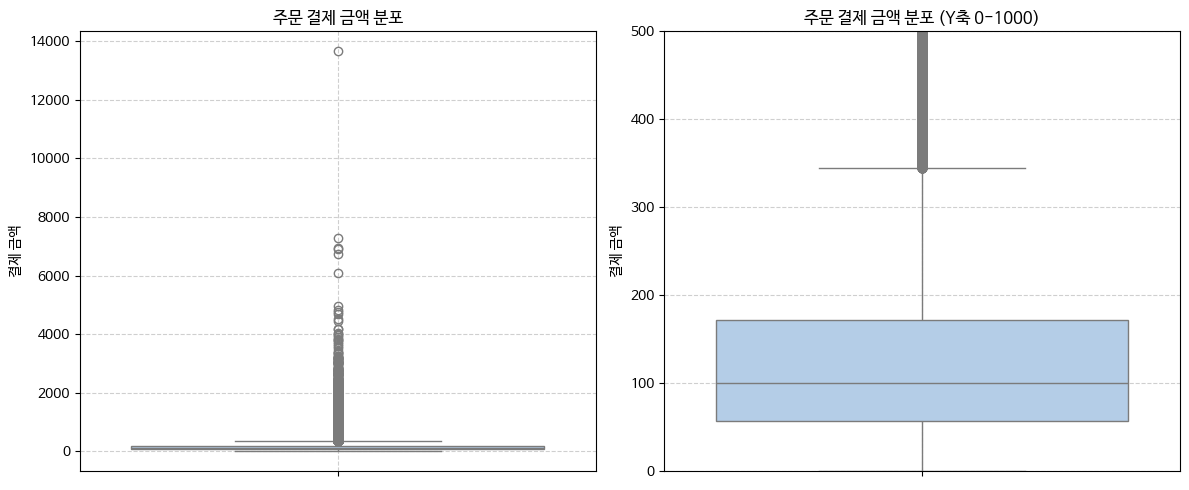

In [ ]:
plt.figure(figsize=(12, 5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 첫 번째 박스플롯 (원래 y축 범위)
sns.boxplot(y=payments['payment_value'], ax=axes[0], color='#abcdef')
axes[0].set_title('주문 결제 금액 분포')
axes[0].set_ylabel('결제 금액')
axes[0].grid(linestyle='--', alpha=0.6)

# 두 번째 박스플롯 (y축 범위 0-500)
sns.boxplot(y=payments['payment_value'], ax=axes[1], color='#abcdef')
axes[1].set_ylim(0, 500)
axes[1].set_title('주문 결제 금액 분포 (Y축 0-1000)')
axes[1].set_ylabel('결제 금액')
axes[1].grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

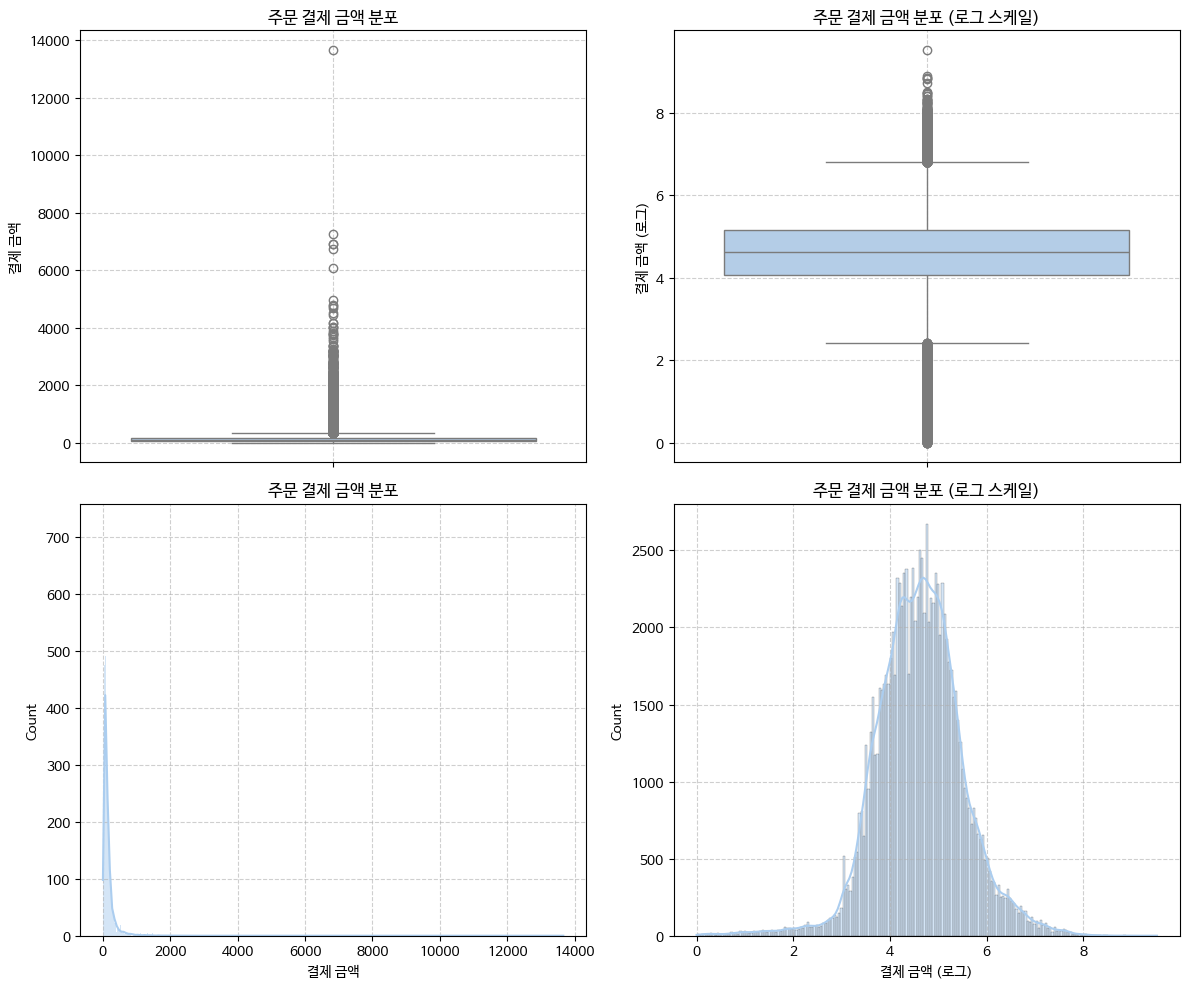

In [ ]:
plt.figure(figsize=(12, 10))
# 1. Figure와 Axes를 생성 (2행 2열)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 서브플롯 1
sns.boxplot(y=payments['payment_value'], ax=axes[0, 0], color='#abcdef')
axes[0, 0].set_title('주문 결제 금액 분포')
axes[0, 0].set_ylabel('결제 금액')
axes[0, 0].grid(linestyle='--', alpha=0.6)

# 서브플롯 2
# 박스플롯을 제대로 볼 수 없어서 자연로그화
a = np.log1p(payments['payment_value'])
sns.boxplot(y=a, ax=axes[0, 1], color='#abcdef')
axes[0, 1].set_title('주문 결제 금액 분포 (로그 스케일)')
axes[0, 1].set_ylabel('결제 금액 (로그)')
axes[0, 1].grid(linestyle='--', alpha=0.6)

# 서브플롯 3
sns.histplot(payments['payment_value'], bins=20000, kde=True, ax=axes[1, 0], color='#abcdef')
axes[1, 0].set_title('주문 결제 금액 분포')
axes[1, 0].set_xlabel('결제 금액')
plt.ylabel("")
axes[1, 0].grid(linestyle='--', alpha=0.6)

# 서브플롯 4
sns.histplot(a, kde=True, ax=axes[1, 1], color='#abcdef')
axes[1, 1].set_title('주문 결제 금액 분포 (로그 스케일)')
axes[1, 1].set_xlabel('결제 금액 (로그)')
axes[1, 1].grid(linestyle='--', alpha=0.6)

# 레이아웃 조절 및 출력
plt.tight_layout()
plt.show()

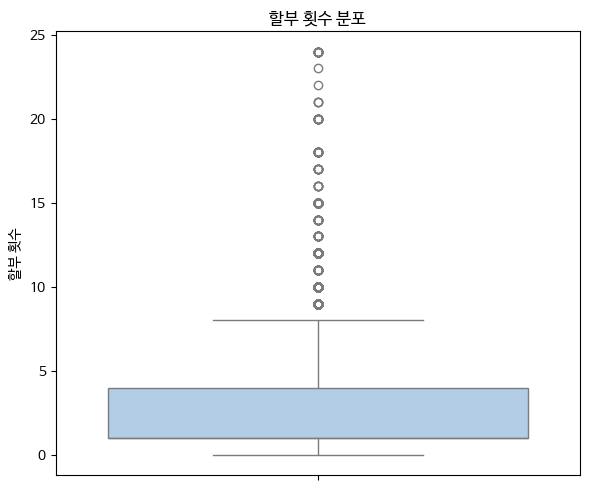

In [ ]:
# 할부 횟수
plt.figure(figsize=(6, 5))
sns.boxplot(y=payments['payment_installments'], color='#abcdef')
plt.title('할부 횟수 분포')
plt.ylabel('할부 횟수') # y축 이름 변경
plt.tight_layout()
plt.show()

카테고리별 상품 분포

/tmp/ipython-input-2045288276.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=big_category_cnt.index, x=big_category_cnt.values, palette=category_colors)


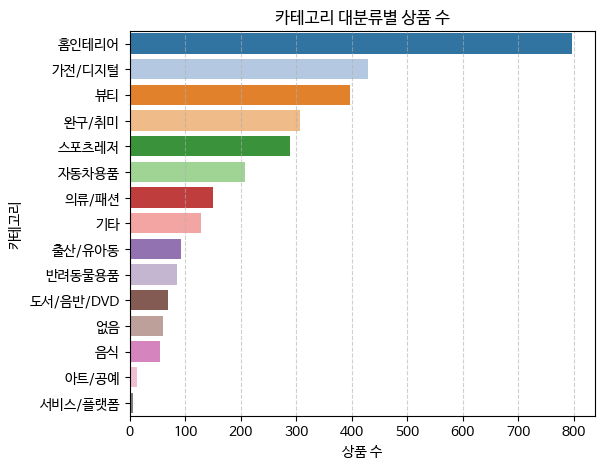

<Figure size 1300x800 with 0 Axes>

In [ ]:
# 카테고리별 상품수 대분류
big_category_cnt = sellers['main_category'].value_counts()

# 'tab20' 팔레트 색상 가져오기
tab20_colors = sns.color_palette('tab20', len(big_category_cnt))

# 카테고리 순서대로 'tab20' 색상 매핑
category_colors = dict(zip(big_category_cnt.index, tab20_colors))


plt.figure(figsize=(6, 5))
# 가로 막대 그래프로 변경
sns.barplot(y=big_category_cnt.index, x=big_category_cnt.values, palette=category_colors)
plt.title("카테고리 대분류별 상품 수")
plt.xlabel("상품 수") # x축 레이블 변경
plt.ylabel("카테고리") # y축 레이블 변경
plt.grid(axis='x', linestyle='--', alpha=0.6) # 그리드 축 변경
plt.figure(figsize=(13, 8))
plt.tight_layout()
plt.show()

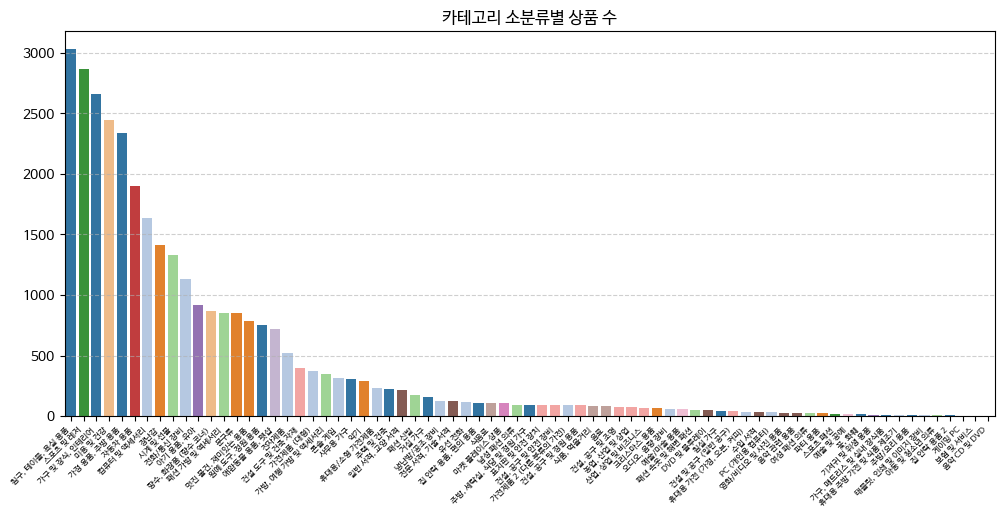

<Figure size 1300x800 with 0 Axes>

In [ ]:
# 카테고리별 상품수 소분류
small_category_cnt = products['product_category_name_kr'].value_counts()

# products 데이터프레임에 이미 대분류 정보가 있으므로 이를 활용
# 소분류별 대분류 매핑 생성
small_to_big_category = products.set_index('product_category_name_kr')['product_big_category_name_kr'].to_dict()

# 소분류별 색상 매핑 생성
small_category_colors = {small_cat: category_colors.get(small_to_big_category.get(small_cat), '#d9d9d9') # 대분류 색상 없으면 회색
                         for small_cat in small_category_cnt.index}


plt.figure(figsize=(12, 5))
# 커스텀 팔레트를 사용하여 색상 지정
sns.barplot(x=small_category_cnt.index, y=small_category_cnt.values, palette=small_category_colors)
plt.xticks(rotation=45, ha='right', fontsize=6) # 글씨 크기 조정
plt.title("카테고리 소분류별 상품 수")
plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.figure(figsize=(13, 8))
plt.tight_layout()
plt.show()

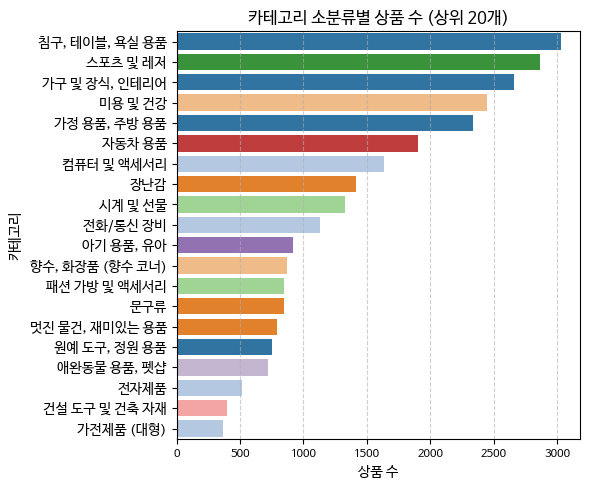

In [ ]:
# 카테고리별 상품수 소분류 상위 20개
small_category_cnt_top20 = products['product_category_name_kr'].value_counts().nlargest(20)

# products 데이터프레임에 이미 대분류 정보가 있으므로 이를 활용
# 소분류별 대분류 매핑 생성 (상위 20개에 대해서만)
small_to_big_category_top20 = products[products['product_category_name_kr'].isin(small_category_cnt_top20.index)].set_index('product_category_name_kr')['product_big_category_name_kr'].to_dict()

# 소분류별 색상 매핑 생성
small_category_colors_top20 = {small_cat: category_colors.get(small_to_big_category_top20.get(small_cat), '#d9d9d9')
                         for small_cat in small_category_cnt_top20.index}

plt.figure(figsize=(6, 5))

# 가로 막대 그래프로 변경
sns.barplot(y=small_category_cnt_top20.index, x=small_category_cnt_top20.values, palette=small_category_colors_top20)
plt.xticks(fontsize=8)
plt.title("카테고리 소분류별 상품 수 (상위 20개)")
plt.xlabel("상품 수")
plt.ylabel("카테고리")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

추가 EDA 위한 테이블 병합, 변수 설정

In [ ]:
df1 = pd.merge(orders, reviews, on = 'order_id', how = 'inner')
df2 = pd.merge(df1, payments, on = 'order_id', how = 'inner')
df3 = pd.merge(df2, items, on = 'order_id', how = 'inner')
df4 = pd.merge(df3, products, on = 'product_id', how = 'inner')
df_all = pd.merge(sellers, df4, on = 'seller_id', how = 'inner')

In [ ]:
df_all['is_late'] = (df_all['order_delivered_carrier_date'] > df_all['shipping_limit_date']).astype(int)

In [ ]:
df = df_all.copy()

In [ ]:
df_group = df.groupby(['seller_id', 'order_id']).agg(total_orders=('seller_id', 'count'), delay_count=('is_late', 'sum'), review_score = ('review_score_x', 'mean')).reset_index()
df_group = df_group.groupby(['seller_id']).agg({'total_orders' : 'sum', 'delay_count' : 'sum', 'review_score' : 'mean'}).reset_index()
df_group['review_score'] = df_group['review_score'].round(2)
df_group['delay_rate'] = (df_group['delay_count'] / df_group['total_orders'] * 100).round(1)

판매자 배송 지연률 분포

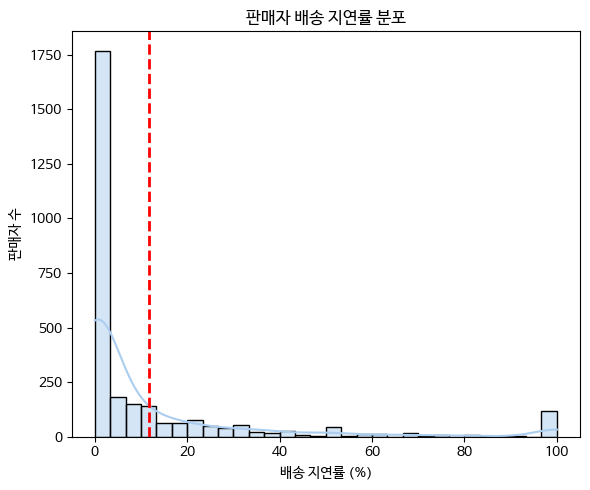

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df_group['delay_rate'], bins=30, kde=True, color = '#abcdef')
avg_delay = df_group['delay_rate'].mean()
plt.axvline(avg_delay, color='red', linestyle='--', linewidth=2, label=f'평균 판매량 ({avg_delay:.1f})')
plt.title('판매자 배송 지연률 분포')
plt.xlabel('배송 지연률 (%)')
plt.ylabel('판매자 수')
plt.tight_layout()
plt.show()

판매자 주문 건 수 분포 (원본/로그변환)

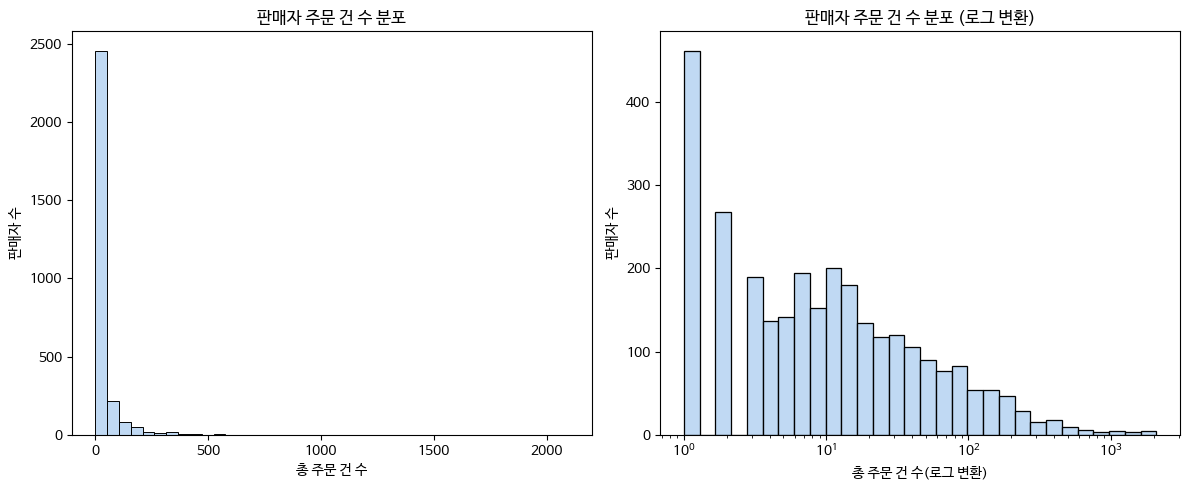

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 원본 데이터 히스토그램
sns.histplot(df_group['total_orders'], bins=40, color = '#abcdef', ax=axes[0])
axes[0].set_title('판매자 주문 건 수 분포')
axes[0].set_xlabel('총 주문 건 수')
axes[0].set_ylabel('판매자 수')

# 로그 변환 데이터 히스토그램
sns.histplot(df_group['total_orders'], bins=30, log_scale=True, color = '#abcdef', ax=axes[1])
axes[1].set_title('판매자 주문 건 수 분포 (로그 변환)')
axes[1].set_xlabel('총 주문 건 수(로그 변환)')
axes[1].set_ylabel('판매자 수')


plt.tight_layout()
plt.show()

판매자 평점 분포

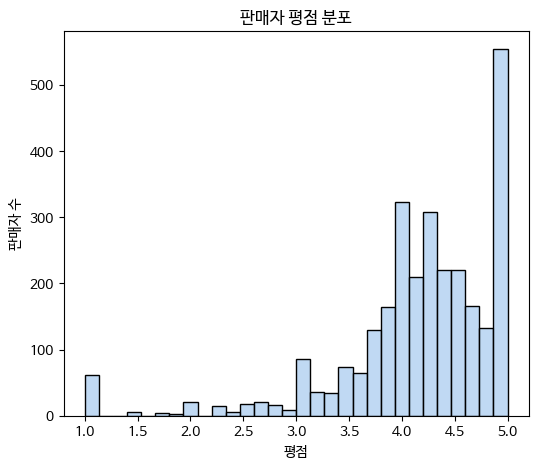

<Figure size 1300x800 with 0 Axes>

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df_group['review_score'], bins=30, color='#abcdef')
plt.title('판매자 평점 분포')
plt.xlabel('평점')
plt.ylabel('판매자 수')
plt.figure(figsize=(13, 8))
plt.tight_layout()
plt.show()

추가 EDA 위한 데이터 병합

In [ ]:
seller_item = pd.merge(sellers, items, on='seller_id')

주 별 판매자 수 분포

/tmp/ipython-input-205883863.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=seller_item, x='seller_state', palette=state_color_map, order=unique_states) # order를 지정하여 value_counts 순서대로 표시


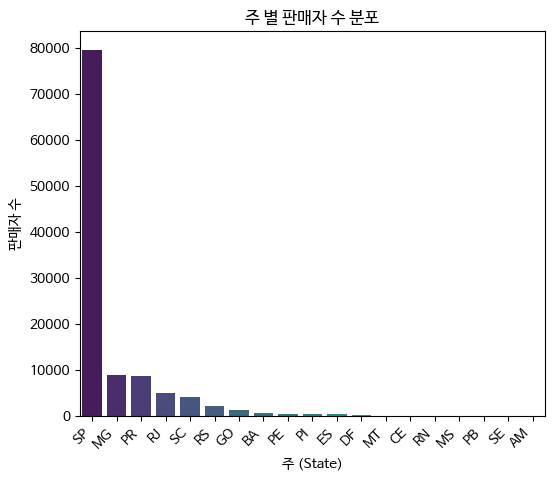

<Figure size 1300x800 with 0 Axes>

In [ ]:
# 주별 셀러 수 계산
state_counts = seller_item['seller_state'].value_counts()

# 고유한 주(State) 목록 가져오기
unique_states = state_counts.index.tolist()

# 'viridis' 팔레트 색상 가져오기
state_palette = sns.color_palette('viridis', len(unique_states))

# 주와 색상을 매핑하는 딕셔너리 생성
state_color_map = dict(zip(unique_states, state_palette))

# 시각화
plt.figure(figsize=(6, 5))
sns.countplot(data=seller_item, x='seller_state', palette=state_color_map, order=unique_states) # order를 지정하여 value_counts 순서대로 표시
plt.title('주 별 판매자 수 분포')
plt.xlabel('주 (State)')
plt.ylabel('판매자 수')
plt.xticks(rotation=45, ha='right')
plt.figure(figsize=(13, 8))
plt.tight_layout()
plt.show()

상파울루 주 내의 도시별 판매자 수 분포

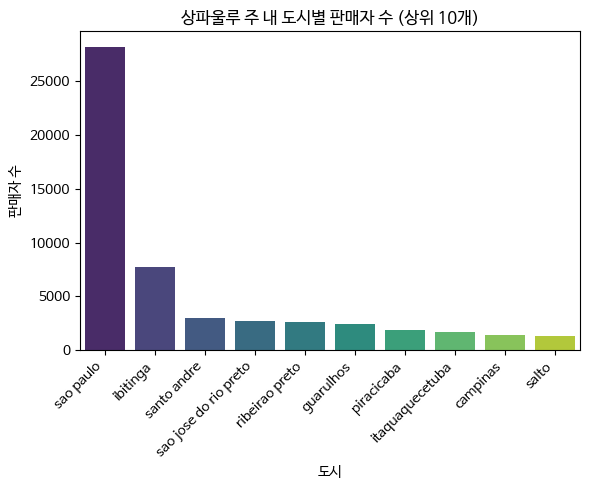

In [ ]:
# 상파울루 주 셀러 데이터 필터링
sp_sellers = seller_item[seller_item['seller_state'] == 'SP']

# 상파울루 주 내 도시별 셀러 수 계산 및 상위 10개 선택
city_counts_sp_top10 = sp_sellers['seller_city'].value_counts().nlargest(10)

# 시각화
plt.figure(figsize=(6, 5))
sns.barplot(x=city_counts_sp_top10.index, y=city_counts_sp_top10.values, palette='viridis')
plt.title('상파울루 주 내 도시별 판매자 수 (상위 10개)')
plt.xlabel('도시')
plt.ylabel('판매자 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

추가 EDA을 위한 변수 정의, 테이블 병합

In [ ]:
products_s = products[['product_id', 'product_big_category_name', 'product_big_category_name_kr']]

In [ ]:
item_prod = pd.merge(items, products_s, on='product_id')
seller_cat = item_prod.groupby(['seller_id', 'product_big_category_name_kr']).agg({'order_id':'size', 'price':'sum'})

In [ ]:
cat_orders = seller_cat.loc[
    seller_cat.groupby('seller_id')['order_id'].idxmax()
]
cat_sales = seller_cat.loc[
    seller_cat.groupby('seller_id')['price'].idxmax()
]
cat_orders = cat_orders.reset_index()
cat_sales = cat_sales.reset_index()

주문수 기준 / 총 판매액 기준 카테고리 분포

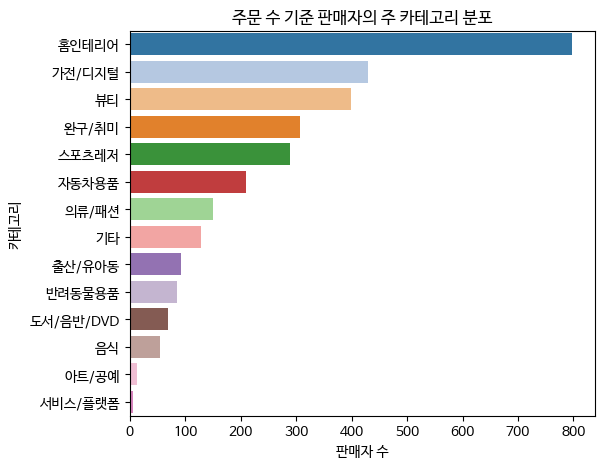

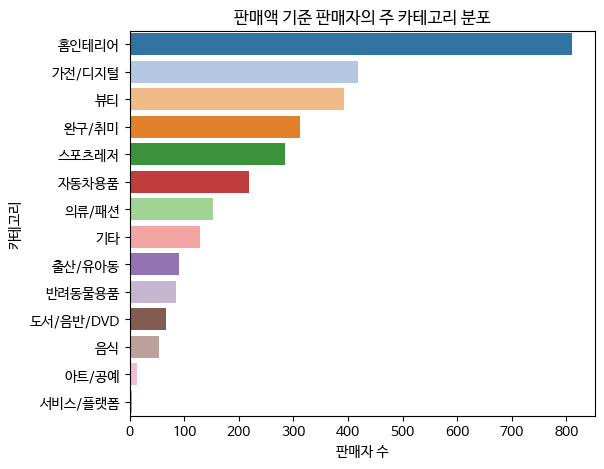

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(y=cat_orders['product_big_category_name_kr'], order=cat_orders['product_big_category_name_kr'].value_counts().index, palette=category_colors)
plt.title('주문 수 기준 판매자의 주 카테고리 분포')
plt.xlabel('판매자 수')
plt.ylabel('카테고리')
plt.show()

plt.figure(figsize=(6,5))
sns.countplot(y=cat_sales['product_big_category_name_kr'], order=cat_sales['product_big_category_name_kr'].value_counts().index, palette=category_colors)
plt.title('판매액 기준 판매자의 주 카테고리 분포')
plt.xlabel('판매자 수')
plt.ylabel('카테고리')
plt.show()

판매자 주 카테고리별 분포 비교 (주문수 vs 판매액 기준)



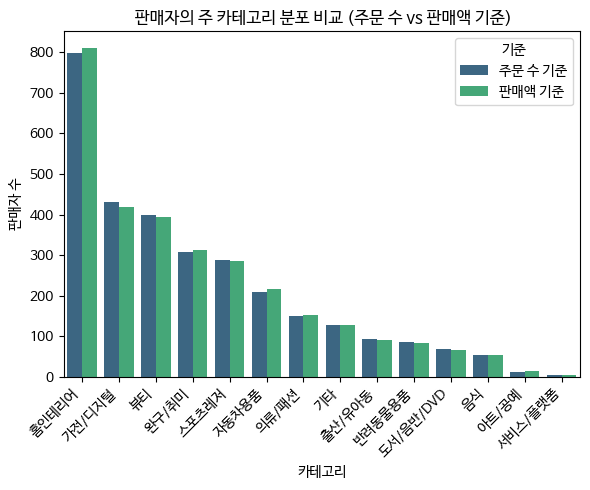

In [ ]:
# 1. 각 기준에서 카테고리별 seller 수 세기
order_counts = cat_orders['product_big_category_name_kr'].value_counts().reset_index()
order_counts.columns = ['category', 'seller_count']
order_counts['기준'] = '주문 수 기준'

sales_counts = cat_sales['product_big_category_name_kr'].value_counts().reset_index()
sales_counts.columns = ['category', 'seller_count']
sales_counts['기준'] = '판매액 기준'

# 2. 두 DataFrame을 하나로 합치기
df_plot = pd.concat([order_counts, sales_counts], ignore_index=True)

# 3. 시각화
plt.figure(figsize=(6, 5))
sns.barplot(
    data=df_plot,
    x='category',
    y='seller_count',
    hue='기준',
    palette='viridis'
)
plt.title(' 판매자의 주 카테고리 분포 비교 (주문 수 vs 판매액 기준)')
plt.xlabel('카테고리')
plt.ylabel('판매자 수')
plt.xticks(rotation=45, ha='right')
plt.legend(title='기준')
plt.tight_layout()
plt.show()

대분류 카테코리별 총 판매액

In [ ]:
import matplotlib.ticker as mticker

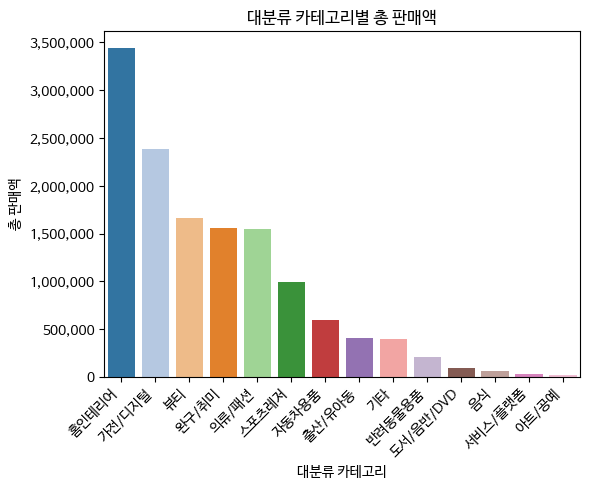

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(data=item_prod.groupby('product_big_category_name_kr')['price'].sum().reset_index(name='total_price').sort_values('total_price', ascending=False),
            x='product_big_category_name_kr', y='total_price',
            palette=category_colors)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.title('대분류 카테고리별 총 판매액')
plt.xlabel('대분류 카테고리')
plt.ylabel('총 판매액')
plt.tight_layout()

대분류 카테고리별 평균 판매액

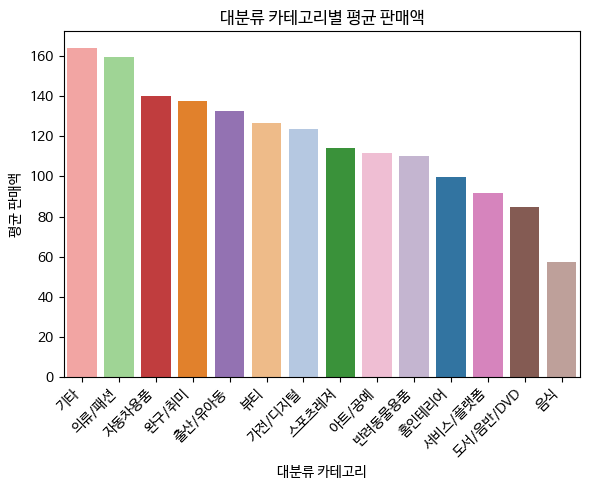

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(data=item_prod.groupby('product_big_category_name_kr')['price'].mean().reset_index(name='mean_price').sort_values('mean_price', ascending=False),
            x='product_big_category_name_kr', y='mean_price',
            palette=category_colors)
plt.xticks(rotation=45, ha='right')
plt.title('대분류 카테고리별 평균 판매액')
plt.xlabel('대분류 카테고리')
plt.ylabel('평균 판매액')
plt.tight_layout()
plt.show()

셀러 상위 6개 주의 카테고리별 판매자 수

In [ ]:
state_prod = pd.merge(cat_orders[['seller_id', 'product_big_category_name_kr']], sellers[['seller_id', 'seller_state']], on='seller_id')

In [ ]:
seller_counts = state_prod.groupby(['seller_state', 'product_big_category_name_kr'])['seller_id'].nunique().reset_index(name='seller_count')

In [ ]:
top_6 = ['SP', 'PR', 'MG', 'SC', 'RJ', 'RS']

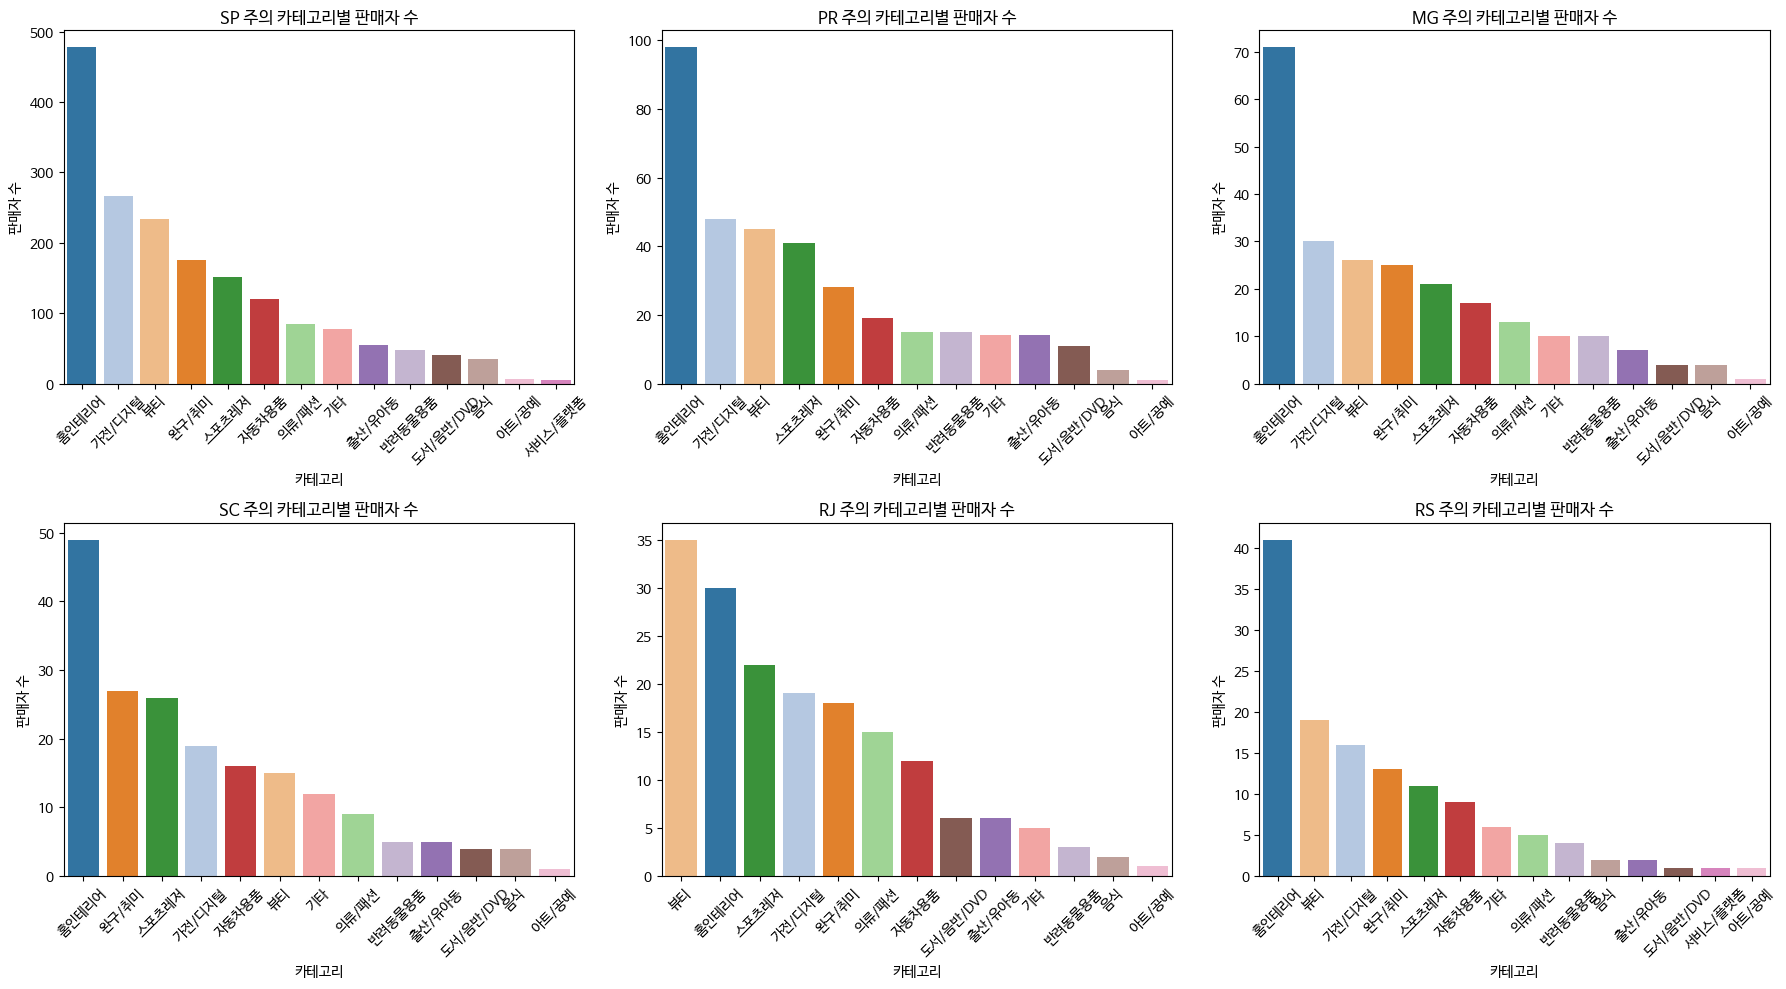

In [ ]:
# 셀러 수 상위 6개 주만
fig, ax = plt.subplots(2, 3, figsize=(18,10))
ax = ax.flatten()

for i, state in enumerate(top_6):
  sp = seller_counts[seller_counts['seller_state'] == state].sort_values('seller_count', ascending=False)

  sns.barplot(data=sp, x='product_big_category_name_kr', y='seller_count', palette=category_colors, ax=ax[i])
  ax[i].set_title(f'{state} 주의 카테고리별 판매자 수')
  ax[i].set_xlabel('카테고리')
  ax[i].set_ylabel('판매자 수')
  ax[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

월평균 주문 건수 분포



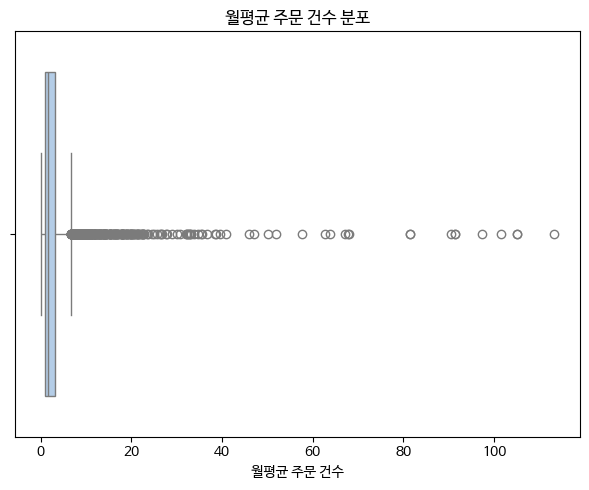

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(sellers, x='monthly_avg_orders', color='#abcdef')
plt.xlabel('월평균 주문 건수')
plt.title('월평균 주문 건수 분포')
plt.tight_layout()
plt.show()

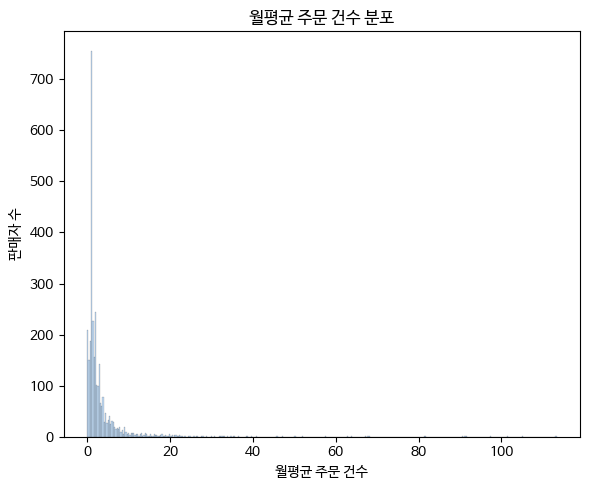

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(sellers, x='monthly_avg_orders', color='#abcdef')
plt.xlabel('월평균 주문 건수')
plt.ylabel('판매자 수')
plt.title('월평균 주문 건수 분포')
plt.tight_layout()
plt.show()

## 군집분석 시작

In [ ]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

In [ ]:
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3087 entries, 0 to 3086
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3087 non-null   object 
 1   seller_zip_code_prefix  3087 non-null   int64  
 2   seller_city             3087 non-null   object 
 3   seller_state            3087 non-null   object 
 4   main_category           3087 non-null   object 
 5   monthly_avg_orders      3087 non-null   float64
 6   review_score            2958 non-null   float64
 7   delay_rate              2963 non-null   float64
 8   order_cnt               3087 non-null   int64  
 9   total_sale              3087 non-null   float64
 10  product_cnt             3087 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 265.4+ KB


필요한 컬럼
* 'monthly_avg_orders', 'review_score', 'delay_rate', 'total_sale', 'order_cnt', 'product_cnt'

In [ ]:
df = sellers[['monthly_avg_orders', 'review_score', 'delay_rate', 'total_sale', 'order_cnt', 'product_cnt']]

<Axes: >

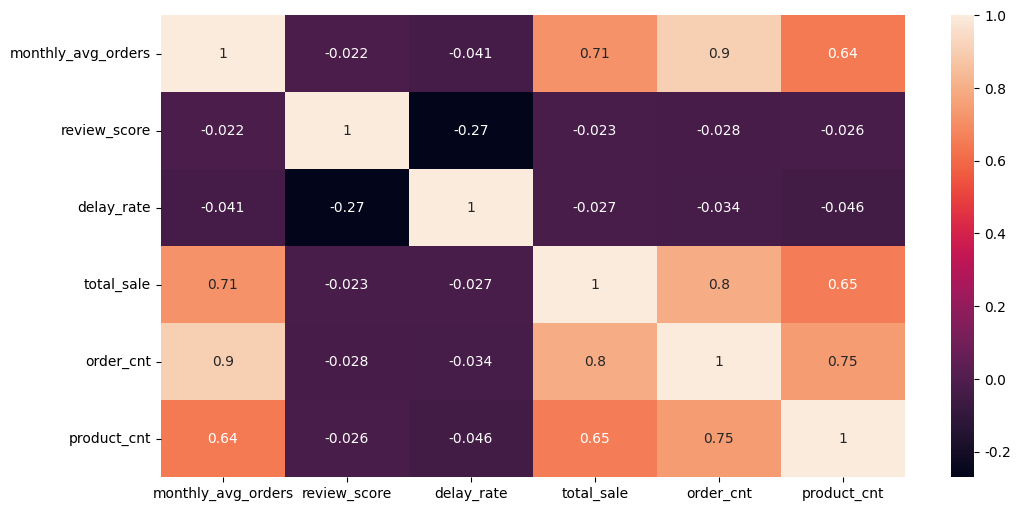

In [ ]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)

In [ ]:
df.isna().sum()

,0
monthly_avg_orders,0
review_score,129
delay_rate,124
total_sale,0
order_cnt,0
product_cnt,0


<Axes: ylabel='review_score'>

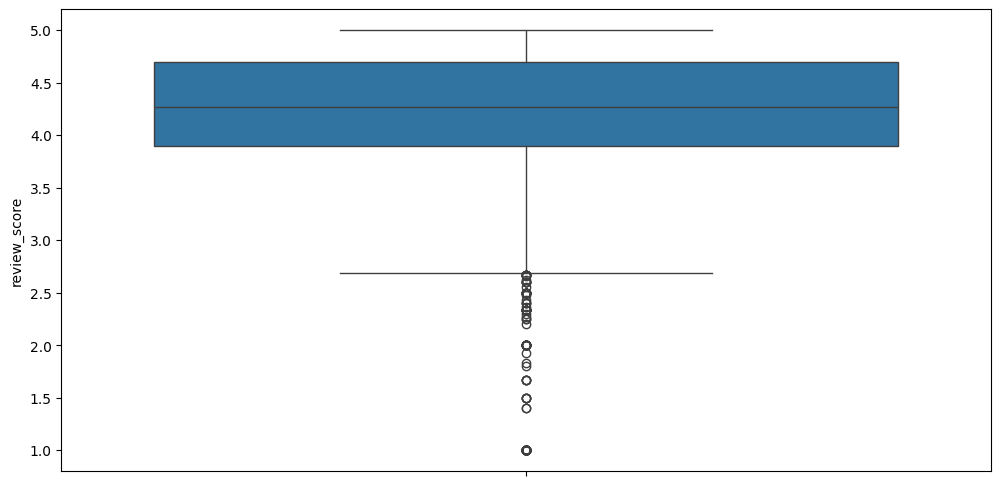

In [ ]:
sns.boxplot(df['review_score'])

<Axes: ylabel='delay_rate'>

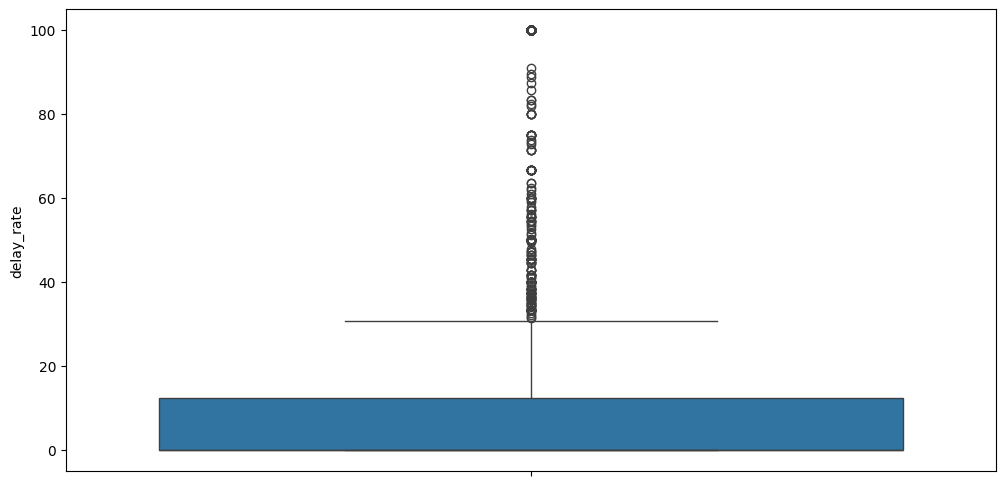

In [ ]:
sns.boxplot(df['delay_rate'])

In [ ]:
df['review_score'] = df['review_score'].fillna(df['review_score'].median())
df['delay_rate'] = df['delay_rate'].fillna(df['delay_rate'].median())
df.isna().sum()

,0
monthly_avg_orders,0
review_score,0
delay_rate,0
total_sale,0
order_cnt,0
product_cnt,0


PCA 변환 후 차원 수: 4
설명된 분산 비율: 0.94


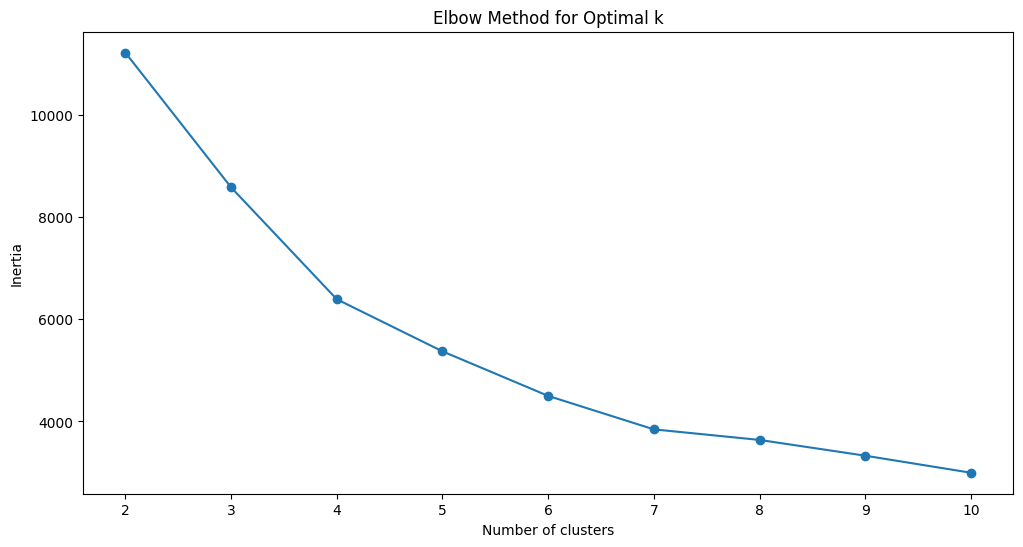

In [ ]:
# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA로 차원 축소 (설명분산 누적 90% 기준)
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA 변환 후 차원 수: {X_pca.shape[1]}")
print(f"설명된 분산 비율: {pca.explained_variance_ratio_.sum():.2f}")

# Elbow method로 적정 클러스터 수 확인
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

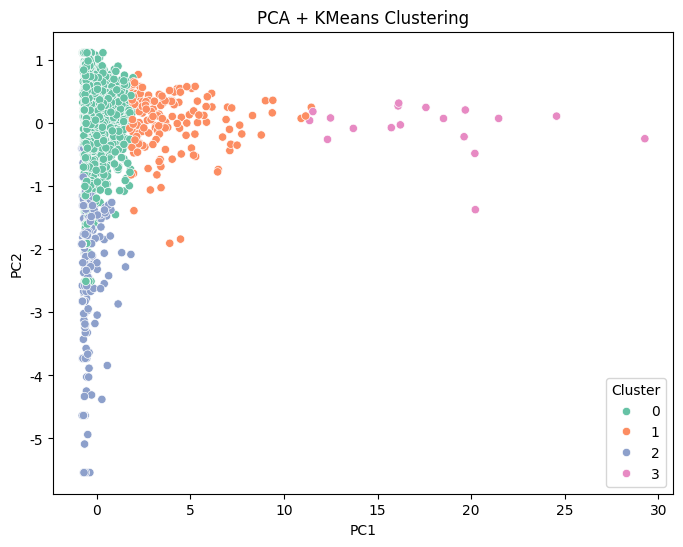

In [ ]:
# K-means 적용
optimal_k = 4  # 예시로 3개 군집 사용
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# 시각화 (2차원 PCA 시점)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2')
plt.title('PCA + KMeans Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

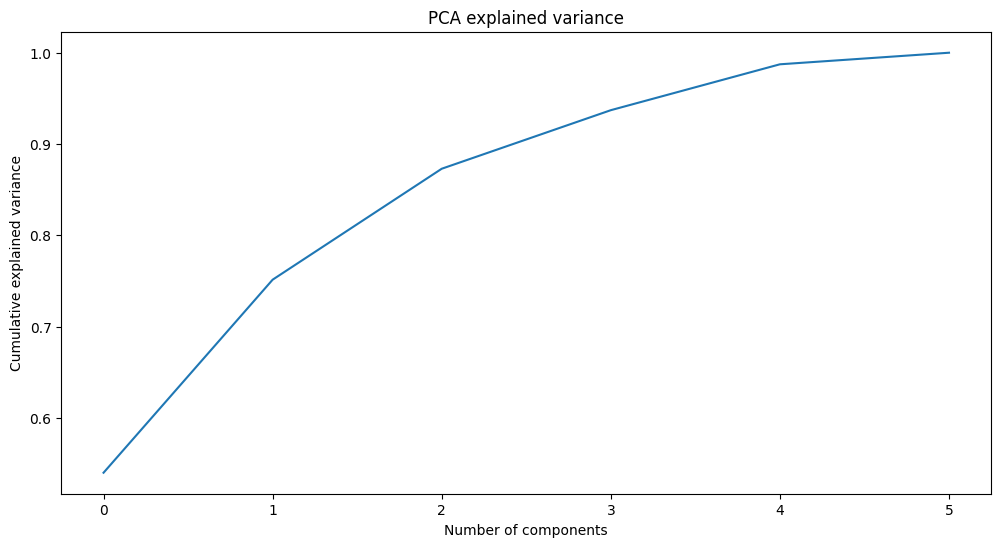

In [ ]:
pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.show()

In [ ]:
df['cluster_kmeans'] = clusters

[K-MEANS (k=4)] Silhouette=0.567, DBI=0.779, CHI=1764.2


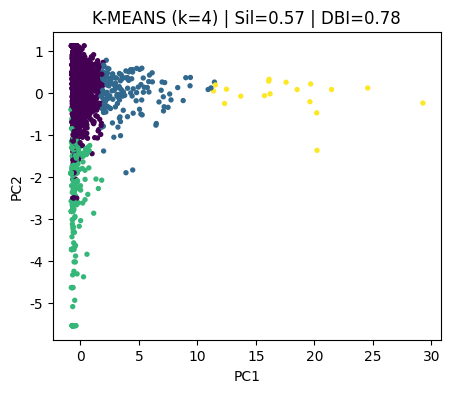

In [ ]:
def evaluate_clustering(X, labels, name):
    """내부 지표 평가 함수"""
    mask = labels != -1
    if len(set(labels[mask])) <= 1:
        print(f"{name}: too few clusters for metrics.")
        return
    sil = silhouette_score(X[mask], labels[mask])
    dbi = davies_bouldin_score(X[mask], labels[mask])
    chi = calinski_harabasz_score(X[mask], labels[mask])
    print(f"[{name}] Silhouette={sil:.3f}, DBI={dbi:.3f}, CHI={chi:.1f}")

    # 2D 시각화
    Z = PCA(n_components=2, random_state=42).fit_transform(X)
    plt.figure(figsize=(5,4))
    plt.scatter(Z[:,0], Z[:,1], c=labels, s=8)
    plt.title(f"{name} | Sil={sil:.2f} | DBI={dbi:.2f}")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.show()

evaluate_clustering(X_pca, clusters, f"K-MEANS (k=4)")

In [ ]:
df.head()

,monthly_avg_orders,review_score,delay_rate,total_sale,order_cnt,product_cnt,cluster_kmeans
0,0.75,3.00,66.67,218.70,3,3,2
1,2.50,4.65,5.00,11703.07,41,30,0
2,1.00,5.00,0.00,158.00,1,1,0
3,1.00,5.00,0.00,79.99,1,1,0
4,1.00,1.00,100.00,167.99,1,1,2


In [ ]:
eps_values = np.linspace(0.05, 1.0, 20)
min_samples_values = range(10, 60, 5)

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X_pca, labels)
            results.append((eps, ms, n_clusters, score))

import pandas as pd
df_score = pd.DataFrame(results, columns=['eps','min_samples','n_clusters','silhouette'])
print(df_score.sort_values(by='silhouette', ascending=False).head())

      eps  min_samples  n_clusters  silhouette
147  0.85           15           2    0.649099
138  0.80           15           2    0.646529
129  0.75           15           2    0.644927
166  1.00           25           2    0.644626
162  0.95           25           2    0.644492


[DBSCAN (eps=0.85, min_samples=15)] Silhouette=0.677, DBI=0.241, CHI=434.2


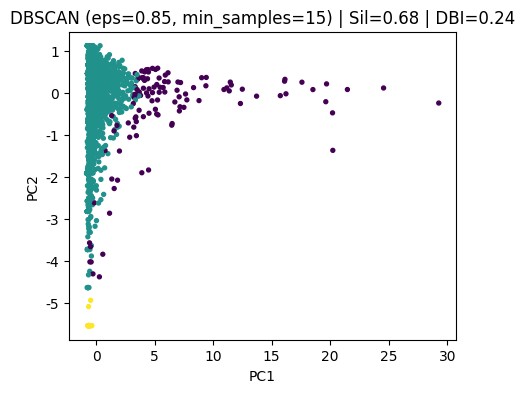


Cluster distribution:
{np.int64(-1): np.int64(114), np.int64(0): np.int64(2942), np.int64(1): np.int64(31)}


In [ ]:
# 선택한 DBSCAN 매개변수
chosen_eps = 0.85
chosen_min_samples = 15

# DBSCAN 모델 생성 및 학습
dbscan = DBSCAN(eps=chosen_eps, min_samples=chosen_min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)

# 군집 레이블을 데이터프레임에 추가
df['cluster_dbscan'] = dbscan_labels # df에 직접 추가

# DBSCAN 결과 평가 및 시각화
# evaluate_clustering 함수는 X (스케일링된 데이터)와 레이블을 인자로 받습니다.
evaluate_clustering(X_pca, dbscan_labels, f"DBSCAN (eps={chosen_eps}, min_samples={chosen_min_samples})")

# 군집별 데이터 포인트 수 확인 (노이즈 포함)
print("\nCluster distribution:")
unique_labels, counts = np.unique(dbscan_labels, return_counts=True)
print(dict(zip(unique_labels, counts)))

In [ ]:
df['cluster_kmeans'].value_counts() # <-클러스터 개수가 고정된다는 점에서 비즈니스적으로도 k-means가 알맞다고 여겨짐

,count
cluster_kmeans,
0,2615
2,301
1,153
3,18


In [ ]:
df['cluster_dbscan'].value_counts()

,count
cluster_dbscan,
0,2942
-1,114
1,31


In [ ]:
sellers['cluster']=df['cluster_kmeans']
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,main_category,monthly_avg_orders,review_score,delay_rate,order_cnt,total_sale,product_cnt,cluster
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,3.00,66.67,3,218.70,3,2
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션,2.50,4.65,5.00,41,11703.07,30,0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,출산/유아동,1.00,5.00,0.00,1,158.00,1,0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,스포츠레저,1.00,5.00,0.00,1,79.99,1,0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,가전/디지털,1.00,1.00,100.00,1,167.99,1,2


In [ ]:
sellers['cluster'] = sellers['cluster'].map({
    0 : 'group_0',
    1 : 'group_1',
    2 : 'group_2',
    3 : 'group_3'
})
sellers['cluster'].unique()

array(['group_2', 'group_0', 'group_1', 'group_3'], dtype=object)

In [ ]:
sellers['cluster'].value_counts()

,count
cluster,
group_0,2615
group_2,301
group_1,153
group_3,18


# sellers_cluster.csv 파일 생성

In [ ]:
# sellers.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_cluster.csv', index=False)

# 모델 저장

In [ ]:
# import joblib
# # 모델 저장
# joblib.dump(kmeans, '/content/drive/MyDrive/꾸러기_수비대/kmeans_model.pkl')
# # # 모델 불러오기
# # kmeans_loaded = joblib.load('kmeans_model.pkl')

# # # 예측 사용
# # labels = kmeans_loaded.predict(X_new)

# 군집 분석 EDA

세그먼트별 리뷰 별점의 평균, 평균 월별 주문수

In [ ]:
# sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_cluster.csv')

In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,main_category,monthly_avg_orders,review_score,delay_rate,order_cnt,total_sale,product_cnt,cluster
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,3.00,66.67,3,218.70,3,group_2
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션,2.50,4.65,5.00,41,11703.07,30,group_0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,출산/유아동,1.00,5.00,0.00,1,158.00,1,group_0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,스포츠레저,1.00,5.00,0.00,1,79.99,1,group_0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,가전/디지털,1.00,1.00,100.00,1,167.99,1,group_2


In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3087 entries, 0 to 3086
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3087 non-null   object 
 1   seller_zip_code_prefix  3087 non-null   int64  
 2   seller_city             3087 non-null   object 
 3   seller_state            3087 non-null   object 
 4   main_category           3087 non-null   object 
 5   monthly_avg_orders      3087 non-null   float64
 6   review_score            2958 non-null   float64
 7   delay_rate              2963 non-null   float64
 8   order_cnt               3087 non-null   int64  
 9   total_sale              3087 non-null   float64
 10  product_cnt             3087 non-null   int64  
 11  cluster                 3087 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 289.5+ KB


sellers 컬럼별 describe

In [ ]:
sellers.groupby("cluster")['monthly_avg_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
group_0,2615.0,2.421679,2.637954,0.00,1.0000,1.50,3.0000,25.00
group_1,153.0,17.880458,11.369054,1.00,10.2100,15.22,21.2000,68.00
group_2,301.0,1.800631,2.045460,0.00,1.0000,1.00,2.0000,17.00
group_3,18.0,74.417222,27.975217,28.95,58.9075,81.52,95.9325,113.29


In [ ]:
sellers.groupby("cluster")['review_score'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
group_0,2490.0,4.233942,0.714873,1.000000,4.000000,4.333333,4.750000,5.000000
group_1,153.0,4.080939,0.283965,2.805128,3.930233,4.097403,4.264501,4.808824
group_2,297.0,3.487309,1.226504,1.000000,2.971154,3.666667,4.500000,5.000000
group_3,18.0,4.029796,0.222524,3.354197,3.959494,4.048689,4.144270,4.373913


세그먼트를 sellers의 월별 평균 주문수/리뷰 점수별로 boxplot 해보기

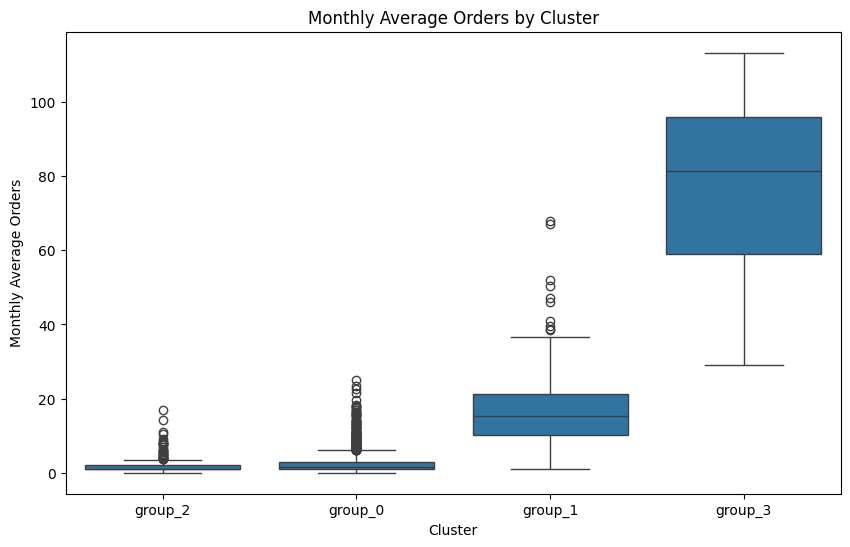

In [ ]:
# 세그먼트 별 월별 평균 주문수 boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=sellers, x='cluster', y='monthly_avg_orders', color='#abcdef')
plt.title('Monthly Average Orders by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monthly Average Orders')
plt.show()

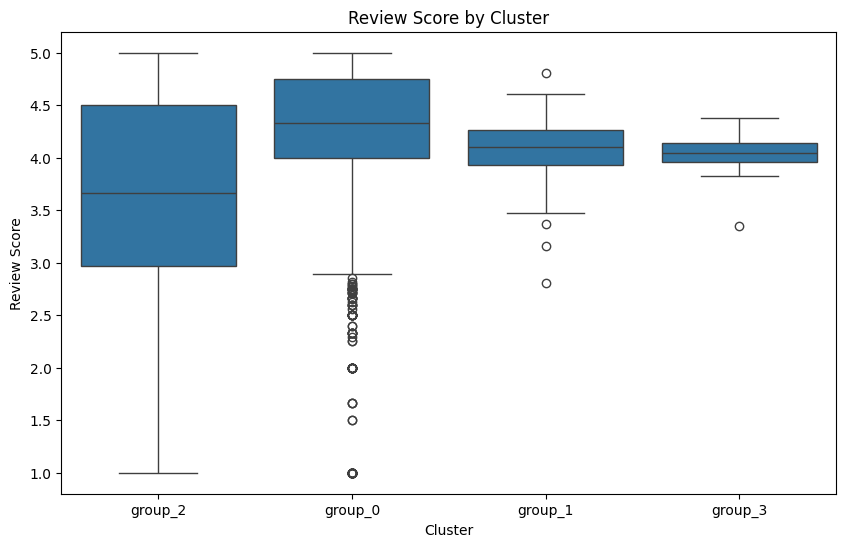

In [ ]:
# 세그먼트 별 평균 리뷰 점수 boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=sellers, x='cluster', y='review_score', color='#abcdef')
plt.title('Review Score by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Review Score')
plt.show()

세그먼트별 sellers의 월별 평균 주문수/리뷰 점수 히스토그램



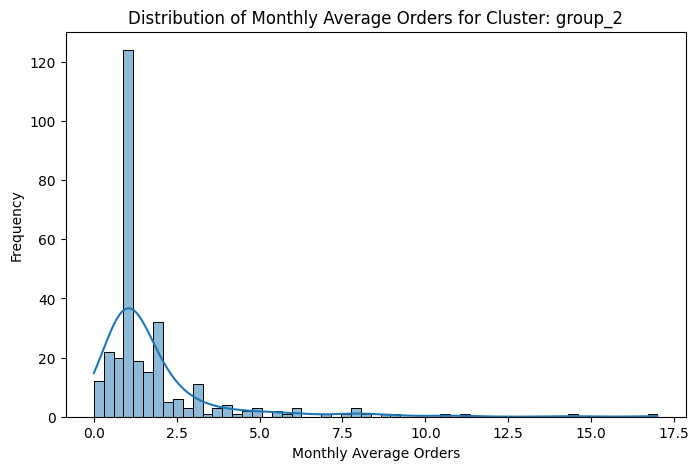

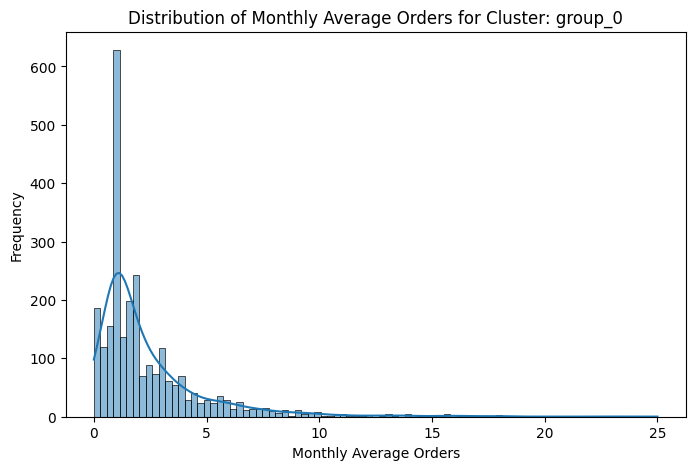

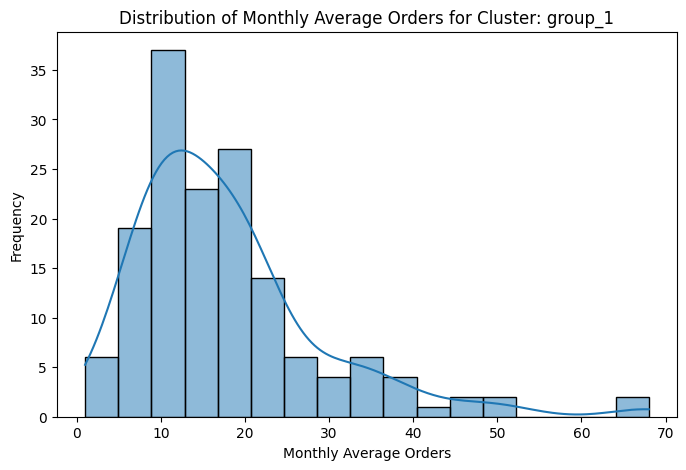

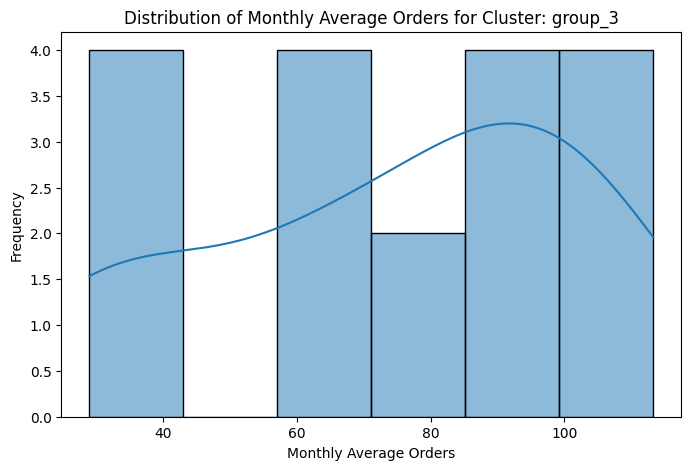

In [ ]:
#세그먼트 별 월별 평균 주문수 히스토그램
clusters = sellers['cluster'].unique()

for cluster in clusters:
    plt.figure(figsize=(6, 5))
    sns.histplot(data=sellers[sellers['cluster'] == cluster], x='monthly_avg_orders', kde=True, color='#abcdef')
    plt.title(f'Distribution of Monthly Average Orders for Cluster: {cluster}')
    plt.xlabel('Monthly Average Orders')
    plt.ylabel('Frequency')
    plt.show()

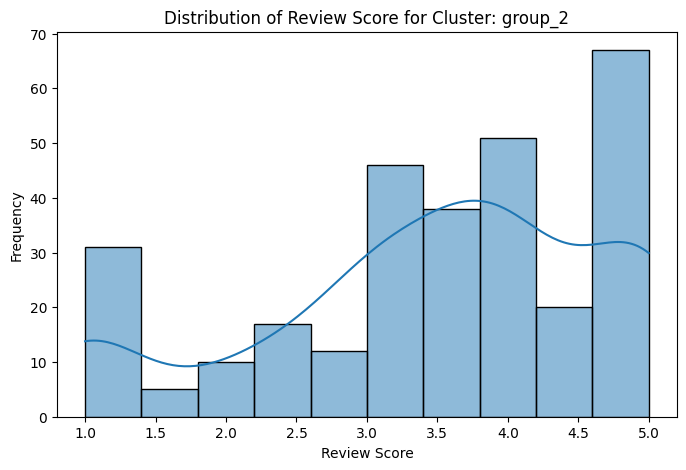

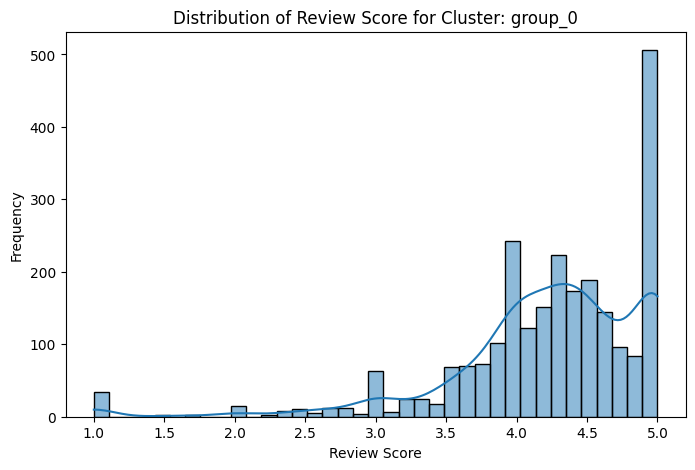

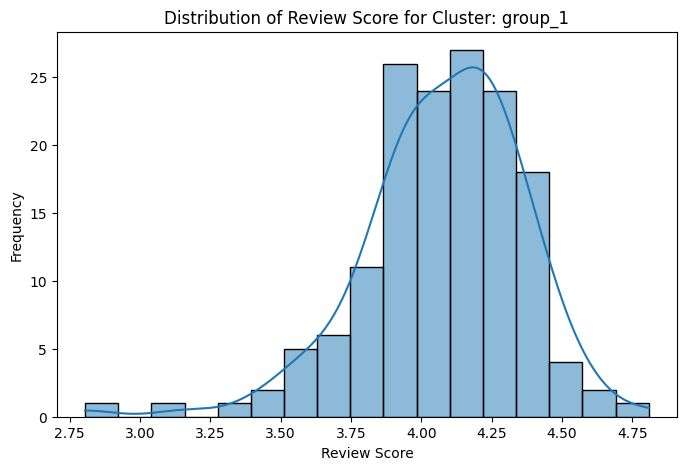

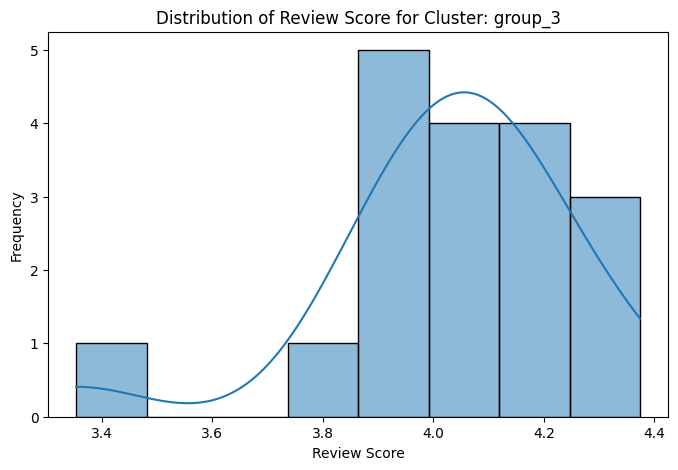

In [ ]:
# 세그먼트 별 리뷰 수 히스토그램
clusters = sellers['cluster'].unique()

for cluster in clusters:
    plt.figure(figsize=(6, 5))
    sns.histplot(data=sellers[sellers['cluster'] == cluster], x='review_score', kde=True, color='#abcdef')
    plt.title(f'Distribution of Review Score for Cluster: {cluster}')
    plt.xlabel('Review Score')
    plt.ylabel('Frequency')
    plt.show()

추가 분석: 별점 평균과 월별 평균 주문수의 관계

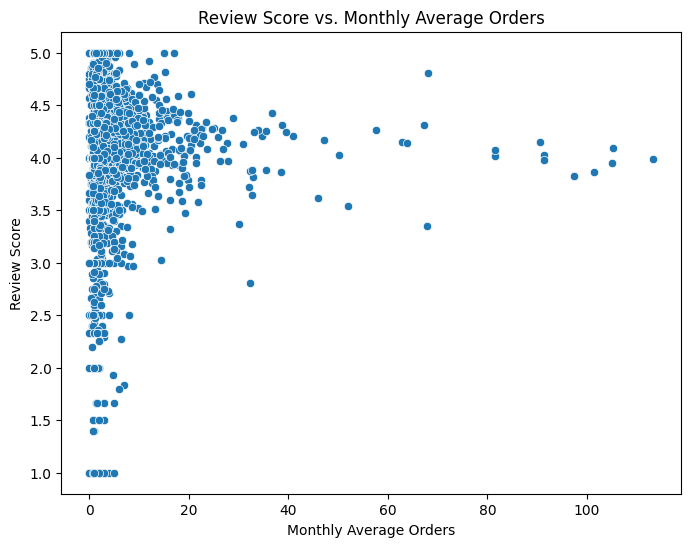

In [ ]:
# Create a scatter plot to visualize the relationship
plt.figure(figsize=(6, 5))
sns.scatterplot(data=sellers, x='monthly_avg_orders', y='review_score', color='#abcdef')
plt.title('Review Score vs. Monthly Average Orders')
plt.xlabel('Monthly Average Orders')
plt.ylabel('Review Score')
plt.show()

세그먼트 별 payments 총 판매 금액 혹은 총 주문 건수

In [ ]:
df_temp = items.groupby('order_id')['seller_id'].count()
df_temp[df_temp>=2]
# 같은 order에 seller가 2명 이상 있는 경우가 9802개 존재함.
# 따라서 order 별로 한 seller에 할당할 수 없음.
# items의 price 항목을 사용하여 분석 진행.

,seller_id
order_id,
0008288aa423d2a3f00fcb17cd7d8719,2
00143d0f86d6fbd9f9b38ab440ac16f5,3
001ab0a7578dd66cd4b0a71f5b6e1e41,3
001d8f0e34a38c37f7dba2a37d4eba8b,2
002c9def9c9b951b1bec6d50753c9891,2
...,...
ffd84ab39cd5e873d8dba24342e65c01,2
ffe4b41e99d39f0b837a239110260530,2
ffecd5a79a0084f6a592288c67e3c298,3


In [ ]:
df_0 = sellers[sellers['cluster']=='group_0']
df_1 = sellers[sellers['cluster']=='group_1']
df_2 = sellers[sellers['cluster']=='group_2']
df_3 = sellers[sellers['cluster']=='group_3']

In [ ]:
df_0.describe()

,order_count,total_sale
count,2970.000000,2970.000000
mean,26.620539,3424.989700
std,52.839122,8226.572046
min,1.000000,3.500000
25%,2.000000,219.900000
50%,8.000000,827.210000
75%,24.000000,3145.440000
max,542.000000,176431.870000


In [ ]:
df_1.describe()

,order_count,total_sale
count,71.000000,71.000000
mean,2.352113,763.657042
std,3.071057,2930.238180
min,1.000000,6.900000
25%,1.000000,64.735000
50%,1.000000,138.600000
75%,2.000000,297.800000
max,20.000000,24075.000000


In [ ]:
df_2.describe()

,order_count,total_sale
count,46.000000,46.000000
mean,725.173913,72964.693913
std,547.099191,62895.843833
min,25.000000,3955.000000
25%,339.250000,27308.602500
50%,559.000000,45090.320000
75%,1114.750000,111956.530000
max,2033.000000,229472.630000


In [ ]:
df_3.describe()

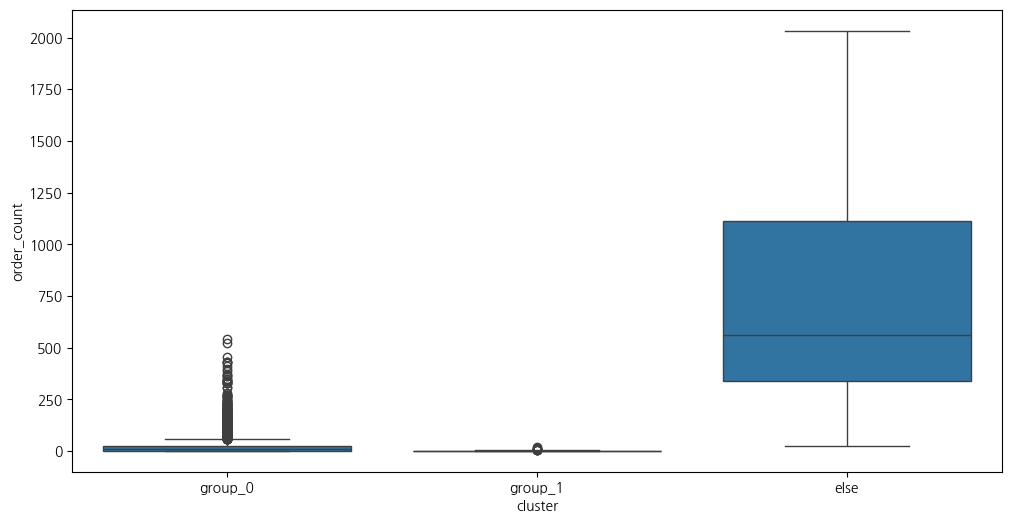

In [ ]:
# 군집별 총 주문 건수 시각화
plt.figure(figsize=(6, 5))
sns.boxplot(x='cluster', y='order_cnt', data=sellers, color='#abcdef')
plt.title('군집별 총 주문 건수 분포')
plt.xlabel('군집')
plt.ylabel('총 주문 건수')
plt.show()

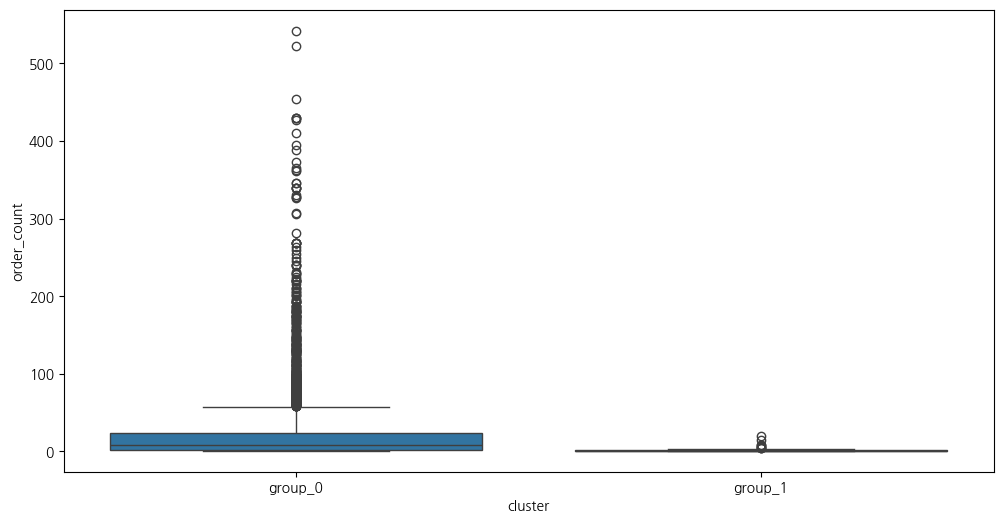

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='cluster', y='order_cnt', data=sellers[sellers['cluster'].isin(['group_0', 'group_2'])], color='#abcdef') # y축 컬럼 이름을 'order_cnt'로 수정
plt.title('군집별 총 주문 건수 분포 (Group 0 vs Group 2)') # 제목 추가
plt.xlabel('군집') # x축 레이블 추가
plt.ylabel('총 주문 건수') # y축 레이블 추가
plt.show()

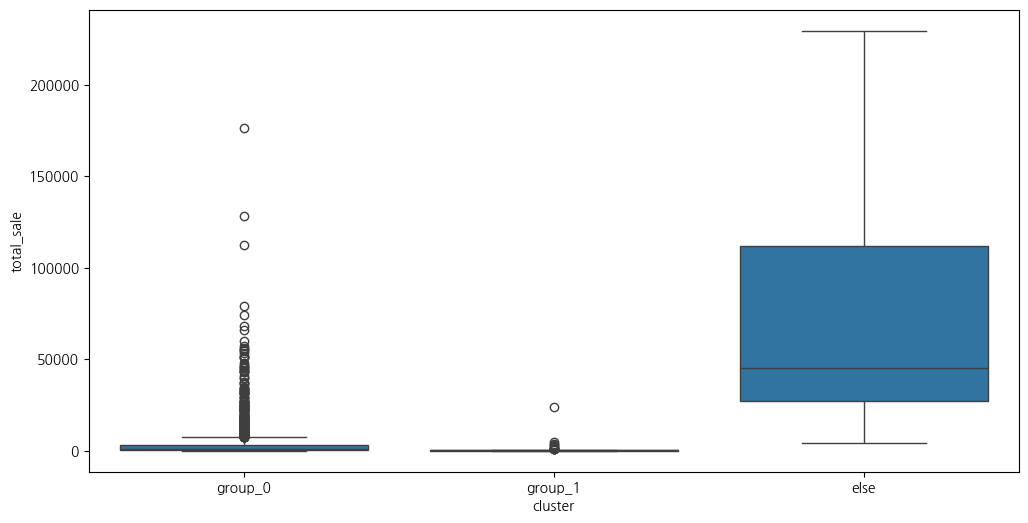

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='cluster', y='total_sale', data=sellers, color='#abcdef') # 데이터프레임을 sellers로 변경
plt.title('군집별 총 판매 금액 분포') # 제목 추가
plt.xlabel('군집') # x축 레이블 추가
plt.ylabel('총 판매 금액') # y축 레이블 추가
plt.show()

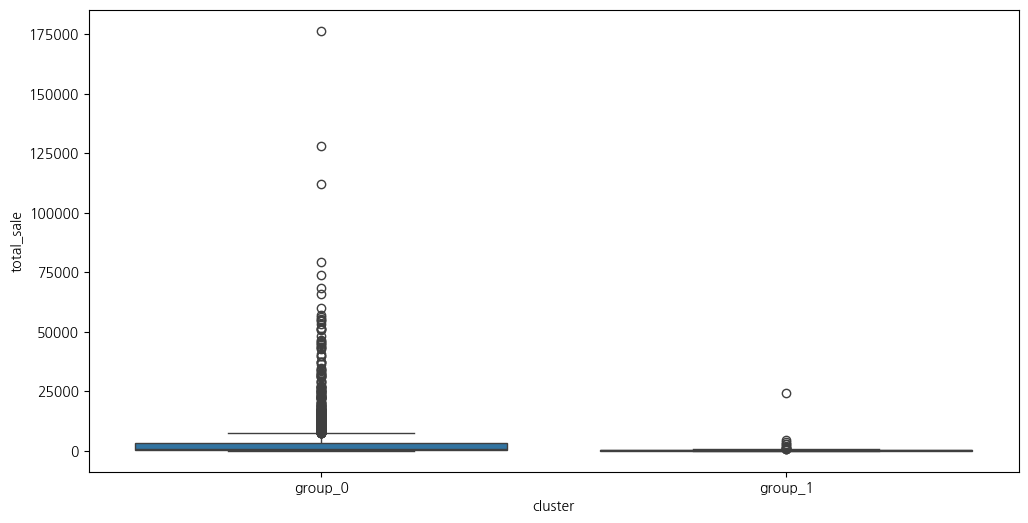

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='cluster', y='total_sale', data=sellers[sellers['cluster'].isin(['group_0', 'group_2'])], color='#abcdef') # data를 sellers로 수정
plt.show()

세그먼트 별 한 판매자가 판매하는 제품의 가짓수 boxplot, describe

In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,main_category,monthly_avg_orders,review_score,cluster
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,스포츠레저,0.75,3.00,group_0
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,의류/패션,2.50,4.65,group_0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,출산/유아동,1.00,5.00,group_0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,스포츠레저,1.00,5.00,group_0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,가전/디지털,1.00,1.00,group_1


<Axes: xlabel='cluster', ylabel='product_cnt'>

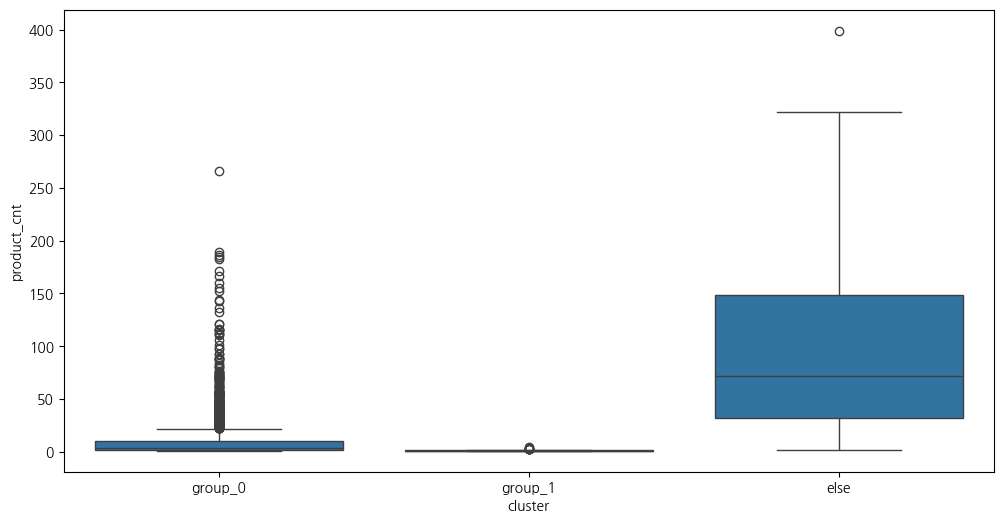

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(sellers, x='cluster', y='product_cnt', color='#abcdef')

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(sellers[sellers['cluster'].isin(['group_2','group_0'])], x='cluster', y='product_cnt', color='#abcdef')

세그먼트별 주 판매 카테고리



In [ ]:
sellers['cluster'].value_counts()

,count
cluster,
group_0,2970
group_1,71
else,46


In [ ]:
# 그룹화된 클러스터별로 다시 변수 설정
df_g0 = sellers[sellers['cluster'] == 'group_0']
df_g1 = sellers[sellers['cluster'] == 'group_1']
df_g2 = sellers[sellers['cluster'] == 'group_2']
df_g3 = sellers[sellers['cluster'] == 'group_3']

print(f"셀러별 group_0 : {df_g0.shape}")
print(f"셀러별 group_1 : {df_g1.shape}")
print(f"셀러별 group_2 : {df_g2.shape}")
print(f"셀러별 group_3 : {df_g3.shape}")

셀러별 group_0 : (2970, 8)
셀러별 group_1 : (71, 8)
셀러별 group_2 : (46, 8)


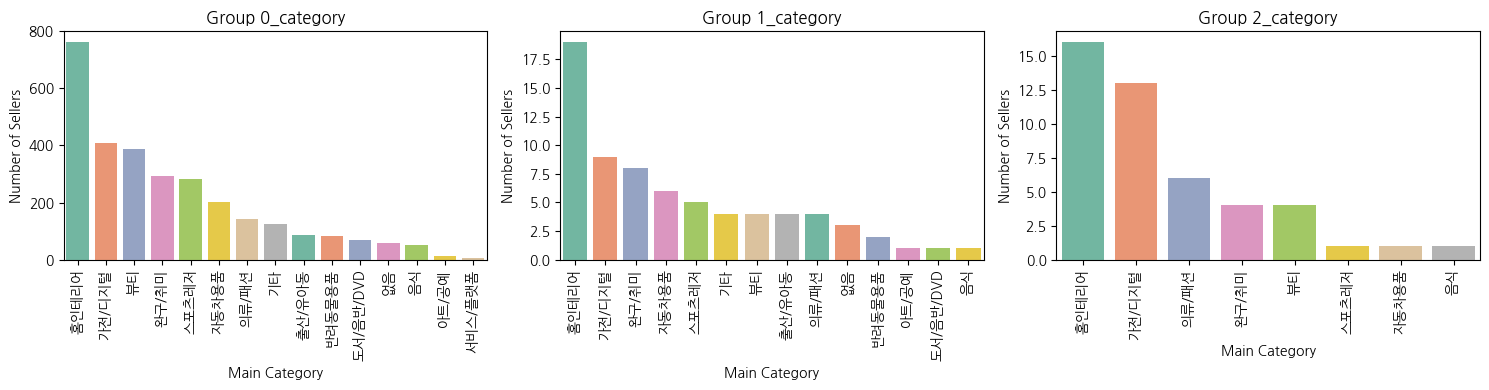

In [ ]:
# 카테고리별 sellers 분포
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.countplot(data=df_g0, x='main_category', ax=axs[0, 0], order=df_g0['main_category'].value_counts().index, palette=category_colors)
axs[0, 0].set_title('Group 0_category')
axs[0, 0].set_xlabel('Main Category')
axs[0, 0].set_ylabel('Number of Sellers')
axs[0, 0].set_xticklabels(axs[0, 0].get_xticklabels(), rotation=90)

sns.countplot(data=df_g1, x='main_category', ax=axs[0, 1], order=df_g1['main_category'].value_counts().index, palette=category_colors)
axs[0, 1].set_title('Group 1_category')
axs[0, 1].set_xlabel('Main Category')
axs[0, 1].set_ylabel('Number of Sellers')
axs[0, 1].set_xticklabels(axs[0, 1].get_xticklabels(), rotation=90)

sns.countplot(data=df_g2, x='main_category', ax=axs[1, 0], order=df_g0['main_category'].value_counts().index, palette=category_colors)
axs[1, 0].set_title('Group 2_category')
axs[1, 0].set_xlabel('Main Category')
axs[1, 0].set_ylabel('Number of Sellers')
axs[1, 0].set_xticklabels(axs[1, 0].get_xticklabels(), rotation=90)

sns.countplot(data=df_g3, x='main_category', ax=axs[1, 1], order=df_g1['main_category'].value_counts().index, palette=category_colors)
axs[1, 1].set_title('Group 3_category')
axs[1, 1].set_xlabel('Main Category')
axs[1, 1].set_ylabel('Number of Sellers')
axs[1, 1].set_xticklabels(axs[1, 1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
print(f"group 0 : {df_g0['main_category'].unique()}")
print(f"group 1 : {df_g1['main_category'].unique()}")
print(f"group 2 : {df_g2['main_category'].unique()}")
print(f"group 3 : {df_g3['main_category'].unique()}")

group 0 : ['스포츠레저' '의류/패션' '출산/유아동' '음식' '가전/디지털' '완구/취미' '뷰티' '홈인테리어' '자동차용품' '없음'
 '도서/음반/DVD' '반려동물용품' '기타' '서비스/플랫폼' '아트/공예']
group 1 : ['가전/디지털' '홈인테리어' '기타' '완구/취미' '자동차용품' '뷰티' '출산/유아동' '스포츠레저' '의류/패션'
 '반려동물용품' '없음' '아트/공예' '도서/음반/DVD' '음식']
group 2 : ['의류/패션' '가전/디지털' '홈인테리어' '완구/취미' '스포츠레저' '뷰티' '자동차용품' '음식']


In [ ]:
# group 0 비율 계산 및 출력
print('='*80)
print('group 0')
print('='*80)
main_category_counts_g0 = df_g0['main_category'].value_counts()
main_category_percentages_g0 = main_category_counts_g0 / len(df_g0) * 100
main_category_percentages_g0 = round(main_category_percentages_g0, 2)
print(main_category_percentages_g0)

print("group 0 주 판매 카테고리")
# Get top categories and handle cases with less than 3 categories
top_g0_categories = main_category_counts_g0.index.tolist()
for i in range(min(3, len(top_g0_categories))):
    category = top_g0_categories[i]
    count = main_category_counts_g0.iloc[i]
    percentage = main_category_percentages_g0.iloc[i]
    print(f"    top {i+1} : {category} ({count}개, {percentage}%)")
print('='*80)

# group 1 비율 계산 및 출력
print()
print('='*80)
print('group 1')
print('='*80)
main_category_counts_g1 = df_g1['main_category'].value_counts()
main_category_percentages_g1 = main_category_counts_g1 / len(df_g1) * 100
main_category_percentages_g1 = round(main_category_percentages_g1, 2)
print(main_category_percentages_g1)

print("group 1 주 판매 카테고리")
# Get top categories and handle cases with less than 3 categories
top_g1_categories = main_category_counts_g1.index.tolist()
for i in range(min(3, len(top_g1_categories))):
    category = top_g1_categories[i]
    count = main_category_counts_g1.iloc[i]
    percentage = main_category_percentages_g1.iloc[i]
    print(f"    top {i+1} : {category} ({count}개, {percentage}%)")
print('='*80)

# group 2 비율 계산 및 출력
print()
print('='*80)
print('group 2')
print('='*80)
main_category_counts_g2 = df_g2['main_category'].value_counts()
main_category_percentages_g2 = main_category_counts_g2 / len(df_g2) * 100
main_category_percentages_g2 = round(main_category_percentages_g2, 2)
print(main_category_percentages_g2)

print("group 2 주 판매 카테고리")
# Get top categories and handle cases with less than 3 categories
top_g2_categories = main_category_counts_g2.index.tolist()
for i in range(min(3, len(top_g2_categories))):
    category = top_g2_categories[i]
    count = main_category_counts_g2.iloc[i]
    percentage = main_category_percentages_g2.iloc[i]
    print(f"    top {i+1} : {category} ({count}개, {percentage}%)")
print('='*80)

# group 2 비율 계산 및 출력
print()
print('='*80)
print('group 3')
print('='*80)
main_category_counts_g3 = df_g3['main_category'].value_counts()
main_category_percentages_g3 = main_category_counts_g3 / len(df_g3) * 100
main_category_percentages_g3 = round(main_category_percentages_g3, 2)
print(main_category_percentages_g3)

print("group 3 주 판매 카테고리")
# Get top categories and handle cases with less than 3 categories
top_g3_categories = main_category_counts_g3.index.tolist()
for i in range(min(3, len(top_g3_categories))):
    category = top_g3_categories[i]
    count = main_category_counts_g3.iloc[i]
    percentage = main_category_percentages_g3.iloc[i]
    print(f"    top {i+1} : {category} ({count}개, {percentage}%)")
print('='*80)

세그먼트별 위치 countplot

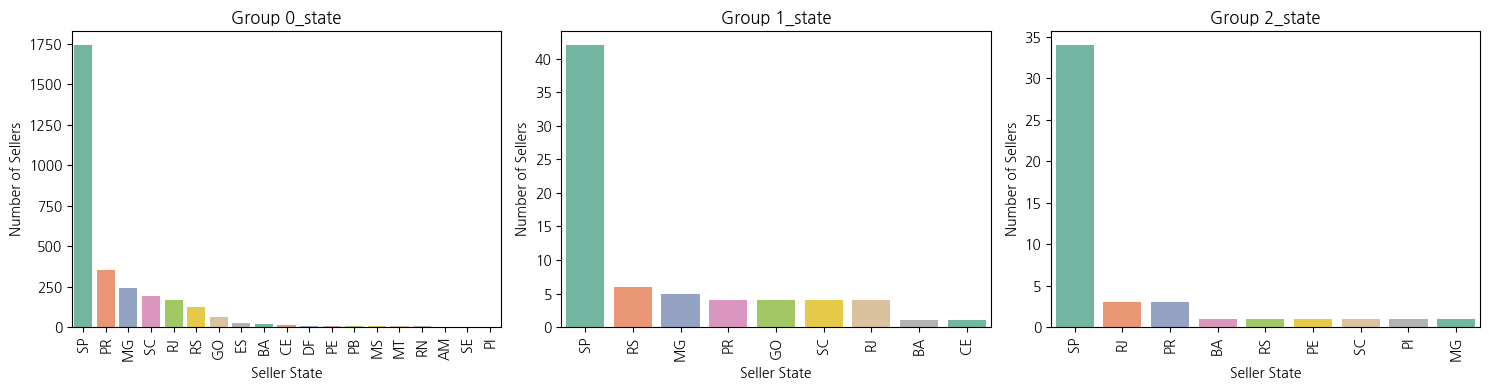

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df_g0, x='seller_state', ax=axs[0,0], order=df_g0['seller_state'].value_counts().index, palette=state_color_map)
axs[0, 0].set_title('Group 0_state')
axs[0, 0].set_xlabel('Seller State')
axs[0, 0].set_ylabel('Number of Sellers')
axs[0, 0].tick_params(axis='x', rotation=90) # Rotate x-axis labels

sns.countplot(data=df_g1, x='seller_state', ax=axs[0,1], order=df_g1['seller_state'].value_counts().index, palette=state_color_map)
axs[0, 1].set_title('Group 1_state')
axs[0, 1].set_xlabel('Seller State')
axs[0, 1].set_ylabel('Number of Sellers')
axs[0, 1].tick_params(axis='x', rotation=90) # Rotate x-axis labels


sns.countplot(data=df_g2, x='seller_state', ax=axs[1,0], order=df_g2['seller_state'].value_counts().index, palette=state_color_map)
axs[1, 0].set_title('Group 2_state')
axs[1, 0].set_xlabel('Seller State')
axs[1, 0].set_ylabel('Number of Sellers')
axs[1, 0].tick_params(axis='x', rotation=90) # Rotate x-axis labels

sns.countplot(data=df_g3, x='seller_state', ax=axs[1,1], order=df_g3['seller_state'].value_counts().index, palette=state_color_map)
axs[1, 1].set_title('Group 3_state')
axs[1, 1].set_xlabel('Seller State')
axs[1, 1].set_ylabel('Number of Sellers')
axs[1, 1].tick_params(axis='x', rotation=90) # Rotate x-axis labels


plt.tight_layout()
plt.show()

In [ ]:
# 데이터 병합
df_merged = pd.merge(sellers, items, on='seller_id', how='inner')
df_merged = pd.merge(df_merged, orders, on='order_id', how='inner')
df_merged = pd.merge(df_merged, payments, on='order_id', how='inner')
df_merged = pd.merge(df_merged, products, on='product_id', how='inner')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113331 entries, 0 to 113330
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   seller_id                      113331 non-null  object 
 1   seller_zip_code_prefix         113331 non-null  int64  
 2   seller_city                    113331 non-null  object 
 3   seller_state                   113331 non-null  object 
 4   main_category                  113331 non-null  object 
 5   monthly_avg_orders             113331 non-null  float64
 6   review_score                   113326 non-null  float64
 7   cluster                        113331 non-null  object 
 8   order_id                       113331 non-null  object 
 9   order_item_id                  113331 non-null  int64  
 10  product_id                     113331 non-null  object 
 11  shipping_limit_date            113331 non-null  object 
 12  price                         

## 세그먼트 지역별, 카테고리별 집계

In [ ]:
sales_summary = df_merged.groupby(['cluster', 'seller_state', 'main_category']).agg(
    total_sales_value=('payment_value', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()
display(sales_summary.head())

,cluster,seller_state,main_category,total_sales_value,order_count
0,else,BA,가전/디지털,279843.42,348
1,else,MG,홈인테리어,150330.84,702
2,else,PE,가전/디지털,85516.09,337
3,else,PI,뷰티,51602.28,389
4,else,PR,가전/디지털,114210.25,958


In [ ]:
sales_by_value = sales_summary.sort_values(by='total_sales_value', ascending=False)
print("Top 10 판매 금액 기준")
display(sales_by_value.head(10))

Top 10 판매 금액 기준


,cluster,seller_state,main_category,total_sales_value,order_count
17,else,SP,홈인테리어,2459867.17,11587
156,group_0,SP,홈인테리어,2375436.11,11580
143,group_0,SP,가전/디지털,1438049.22,7760
147,group_0,SP,뷰티,957837.33,5051
15,else,SP,의류/패션,811659.37,4257
151,group_0,SP,완구/취미,801014.32,4555
149,group_0,SP,스포츠레저,729732.36,4115
153,group_0,SP,의류/패션,653068.63,2322
154,group_0,SP,자동차용품,424888.15,2530
13,else,SP,완구/취미,424011.10,2729


In [ ]:
sales_by_order_count = sales_summary.sort_values(by='order_count', ascending=False)
print("Top 10 판매 건수 기준")
display(sales_by_order_count.head(10))

Top 10 판매 건수 기준


,cluster,seller_state,main_category,total_sales_value,order_count
17,else,SP,홈인테리어,2459867.17,11587
156,group_0,SP,홈인테리어,2375436.11,11580
143,group_0,SP,가전/디지털,1438049.22,7760
147,group_0,SP,뷰티,957837.33,5051
151,group_0,SP,완구/취미,801014.32,4555
15,else,SP,의류/패션,811659.37,4257
149,group_0,SP,스포츠레저,729732.36,4115
10,else,SP,가전/디지털,207088.27,3275
13,else,SP,완구/취미,424011.10,2729
154,group_0,SP,자동차용품,424888.15,2530


In [ ]:
sales_by_order_count['seller_state'].unique()

array(['SP', 'MG', 'PR', 'SC', 'RJ', 'RS', 'PI', 'BA', 'GO', 'PE', 'ES',
       'DF', 'MT', 'CE', 'MS', 'RN', 'PB', 'SE', 'AM'], dtype=object)


상파울루에 셀러들이 몰려있는 것을 확인할 수 있었다.

거래량이 무조건 거래금액이 높다는 것을 의미하지는 않지만 많은 상관관계가 있음.

클러스터별 판매 카테고리 상세 분석

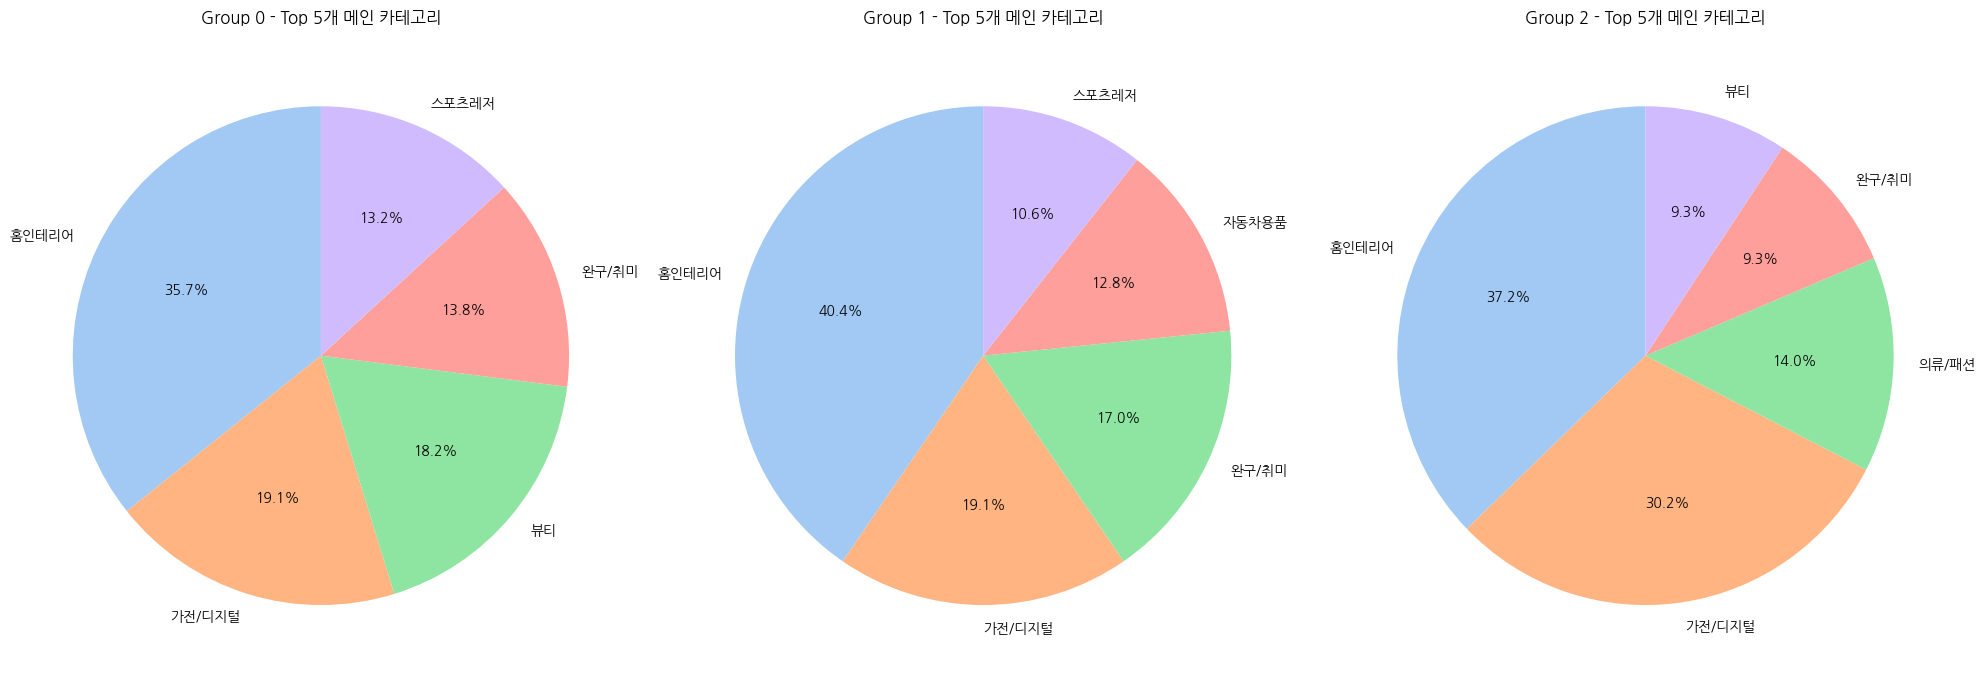

In [ ]:
# 각 그룹 주요 카테고리 비율
main_category_percentages = {}
for i, df in enumerate([df_g0, df_g1, df_g2, df_g3]):
    main_category_percentages[i] = df['main_category'].value_counts(normalize=True) * 100

top_n = 5
top_categories = {i: main_category_percentages[i].head(top_n) for i in range(4)}

# 파이차트
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for i, ax in enumerate(axs.flatten()):
    # 색상 추출, 없는 카테고리는 회색('#d3d3d3')로 처리
    colors = [category_colors.get(cat, '#d3d3d3') for cat in top_categories[i].index]

    ax.pie(
        top_categories[i],
        labels=top_categories[i].index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    ax.set_title(f'Group {i} - Top {top_n} Main Categories')
    ax.axis('equal')  # 원형 유지

plt.tight_layout()
plt.show()

모든 그룹에서 홈인테리어가 1위를 차지함

## 세그먼트 별 배송지연율

In [ ]:
df1 = pd.merge(orders, items, on = 'order_id', how = 'inner')
df1['is_late'] = (df1['order_delivered_carrier_date'] > df1['shipping_limit_date']).astype(int)
df = pd.merge(sellers, df1, on = 'seller_id', how = 'inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110115 entries, 0 to 110114
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   seller_id                      110115 non-null  object 
 1   seller_zip_code_prefix         110115 non-null  int64  
 2   seller_city                    110115 non-null  object 
 3   seller_state                   110115 non-null  object 
 4   main_category                  110115 non-null  object 
 5   monthly_avg_orders             110115 non-null  float64
 6   review_score                   110110 non-null  float64
 7   cluster                        110115 non-null  object 
 8   order_id                       110115 non-null  object 
 9   customer_id                    110115 non-null  object 
 10  order_status                   110115 non-null  object 
 11  order_purchase_timestamp       110115 non-null  object 
 12  order_approved_at             

### 군집별 배송지연율 EDA

In [ ]:
df_seg = df.groupby(['cluster', 'order_id']).agg(total_orders=('cluster', 'count'), delay_count=('is_late', 'sum')).reset_index()

df_seg = df_seg.groupby(['cluster']).agg({'total_orders' : 'sum', 'delay_count' : 'sum'}).reset_index()

In [ ]:
df_seg

,cluster,total_orders,delay_count
0,else,32874,2875
1,group_0,77109,7309
2,group_1,132,69


In [ ]:
df_seg['delay_rate'] = (df_seg['delay_count'] / df_seg['total_orders'] * 100).round(1)
df_seg

,cluster,total_orders,delay_count,delay_rate
0,else,32874,2875,8.7
1,group_0,77109,7309,9.5
2,group_1,132,69,52.3


In [ ]:
# 배송지연율
# 집단 간에 배송지연율의 차이가 있는가? (카이제곱 독립성 검정)

plt.figure(figsize=(6, 5))
sns.barplot(data=df_seg, x='cluster', y='delay_rate', color='#abcdef')
plt.title('Cluster Delay Rates(%)')
plt.ylabel('delay_rate(%)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

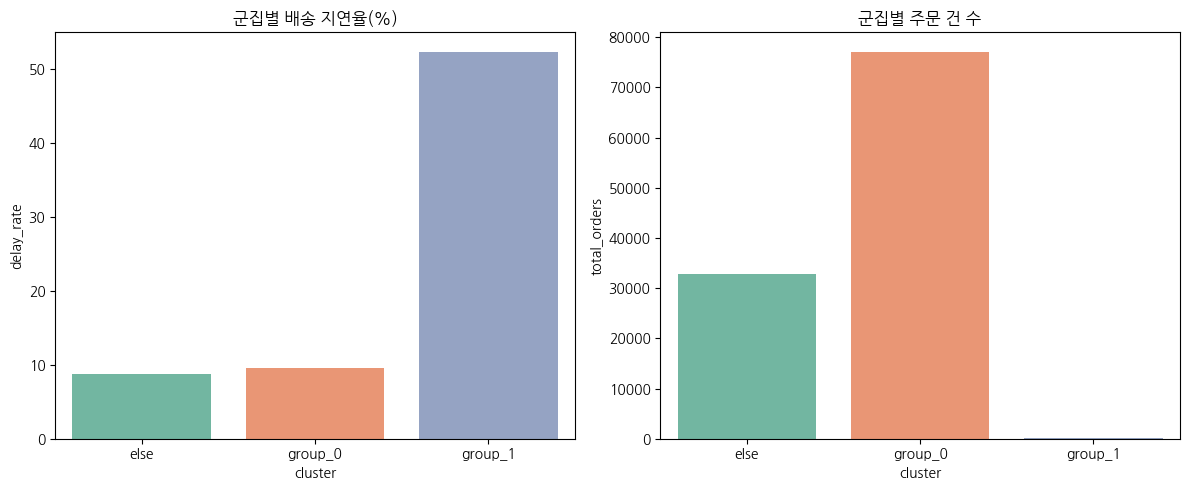

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: 배송지연율
sns.barplot(data=df_seg, x='cluster', y='delay_rate', hue='cluster', color='#abcdef', ax=axes[0])
axes[0].set_title('군집별 배송 지연율(%)')

# 오른쪽: 전체 주문량
sns.barplot(data=df_seg, x='cluster', y='total_orders',  hue='cluster', color='#abcdef', ax=axes[1])
axes[1].set_title('군집별 주문 건 수')

plt.tight_layout()
plt.show()

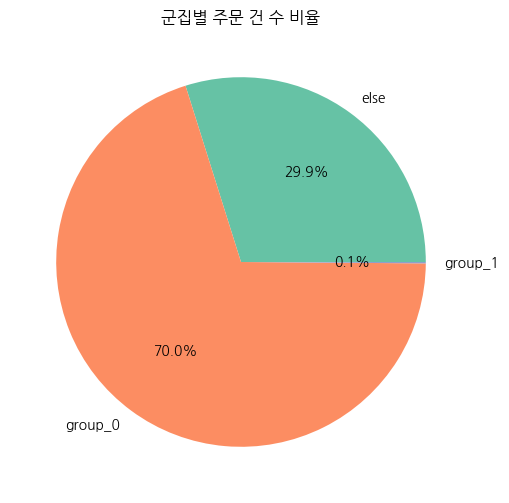

In [ ]:
colors_list = ['#abcdef', '#5dade2', '#5499c7', '#2e86c1', '#2874a6']

plt.figure(figsize=(6, 5))
plt.pie(df_seg['total_orders'], labels=df_seg['cluster'], autopct='%1.1f%%', colors=colors_list)
plt.title('군집별 주문 건 수 비율')
plt.show()

# 통계분석

In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/customers.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/geolocation_clean.csv')
items = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/items_clean.csv')
payments = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/payments_clean.csv')
products = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/products_clean.csv')
reviews = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_reviews.csv')
orders = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/orders_clean.csv')
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_cluster.csv')

---------------------------------------------
# 통계분석
## 평균 리뷰 평점 t-test

### 정규성 판단 도우미 함수

In [ ]:
def check_normality_simple(data, name="데이터"):
    """
    데이터의 정규성을 검정하는 함수

    Parameters
    ----------
    data : array-like
        정규성을 검정할 데이터 (NaN은 자동 제거)
    name : str, default="데이터"
        출력 시 표시될 데이터 이름

    Returns
    -------
    bool
        정규분포 가정 충족 여부
        - True: 정규분포 가정 가능 (모수 검정)
        - False: 정규분포 가정 위반 (비모수 검정)

    검정 기준
    ---------
    - n < 30: Shapiro-Wilk 검정 (p > 0.05)
    - 30 ≤ n < 100: 왜도/첨도 우선, 필요시 Shapiro-Wilk
    - n ≥ 100: 왜도 기준 (|왜도| < 2, 중심극한정리)
    """
    # NaN 체크
    if pd.isna(data).any():
        print(f"⚠️ 경고: {name}에 NaN 값이 {pd.isna(data).sum()}개 포함됨")
        data = data.dropna()
        print(f"   → NaN 제거 후 n={len(data)}")

    n = len(data)

    print(f"\n[{name} 정규성 검정] n={n}")
    print("-"*40)

    # 왜도와 첨도
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)
    print(f"왜도(Skewness): {skew:.3f}")
    print(f"첨도(Kurtosis): {kurt:.3f}")

    # 표본 크기에 따른 판단
    if n < 30:
        stat, p = shapiro(data)
        print(f"Shapiro-Wilk p-value: {p:.4f}")
        is_normal = p > 0.05
        reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    elif n < 100:
        if abs(skew) < 1 and abs(kurt) < 2:
            is_normal = True
            reason = "|왜도|<1, |첨도|<2"
        else:
            stat, p = shapiro(data)
            print(f"추가 Shapiro-Wilk p-value: {p:.4f}")
            is_normal = p > 0.05
            reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    else:
        is_normal = abs(skew) < 2
        reason = f"|왜도|{'<' if is_normal else '≥'}2 (중심극한정리)"

    print(f"결과: {'✅ 정규분포 가정 충족' if is_normal else '❌ 정규분포 가정 위반'} ({reason})")
    return is_normal

검정 시행 함수

In [ ]:
def hypothesis_test(class0_data, class1_data, is_normal_0, is_normal_1, equal_var=True, alpha=0.05):
    """
    두 그룹 간 평균 차이에 대한 가설검정을 수행하는 함수.
    (정규성에 따라 t-검정 또는 Mann-Whitney U 검정을 자동 선택)

    Parameters
    ----------
    class0_data : array-like
        그룹 0 데이터 (예: class0_alcohol)
    class1_data : array-like
        그룹 1 데이터 (예: class1_alcohol)
    is_normal_0 : bool
        그룹 0의 정규성 충족 여부
    is_normal_1 : bool
        그룹 1의 정규성 충족 여부
    equal_var : bool, optional
        두 그룹의 분산이 같은지 여부 (default=True)
    alpha : float, optional
        유의수준 (default=0.05)

    Returns
    -------
    result : dict
        {
            'test_name': str,
            'statistic': float,
            'p_value': float,
            'effect_size': float or None,
            'effect_interpretation': str or None,
            'conclusion': str
        }
    """

    print("\n[가설검정]")
    print("-" * 40)

    if is_normal_0 and is_normal_1:
        print("H₀: μ₀ = μ₁ (두 클래스의 평균이 같다)")
        print("H₁: μ₀ ≠ μ₁ (두 클래스의 평균이 다르다)")
    else:
        print("H₀: 두 클래스의 분포가 같다 (중앙값 차이가 없다)")
        print("H₁: 두 클래스의 분포가 다르다 (중앙값 차이가 있다)")

    print(f"유의수준: α = {alpha}\n")


    # --- 검정 수행 ---
    if is_normal_0 and is_normal_1:
        # 모수 검정
        test_name = "Student's t-test" if equal_var else "Welch's t-test"
        t_stat, p_value = ttest_ind(class0_data, class1_data, equal_var=equal_var)
        print(f"{test_name} 결과:")
        print(f"t = {t_stat:.4f}, p = {p_value:.4f}")

        # Cohen's d 계산
        pooled_std = np.sqrt((class0_data.var() + class1_data.var()) / 2)
        cohens_d = (class0_data.mean() - class1_data.mean()) / pooled_std
        abs_d = abs(cohens_d)

        if abs_d < 0.2:
            effect = "매우 작은 효과"
        elif abs_d < 0.5:
            effect = "작은 효과"
        elif abs_d < 0.8:
            effect = "중간 효과"
        else:
            effect = "큰 효과"

        print(f"Cohen's d = {cohens_d:.3f} ({effect})")

        test_stat = t_stat
        effect_size = cohens_d
        effect_interpretation = effect

    else:
        # 비모수 검정
        test_name = "Mann-Whitney U test"
        u_stat, p_value = mannwhitneyu(class0_data, class1_data, alternative='two-sided')
        print(f"{test_name} 결과:")
        print(f"U = {u_stat:.4f}, p = {p_value:.4f}")

        test_stat = u_stat
        effect_size = None
        effect_interpretation = None

    # --- 결론 ---
    print("\n[결론]")
    if p_value < alpha:
        conclusion = f"✅ p-value({p_value:.4f}) < {alpha} → 귀무가설 기각\n   두 클래스에 유의한 차이가 있음"
    else:
        conclusion = f"❌ p-value({p_value:.4f}) ≥ {alpha} → 귀무가설 채택\n   두 클래스에 유의한 차이가 없음"

    print(conclusion)

    # 결과 반환
    return {
        'test_name': test_name,
        'statistic': test_stat,
        'p_value': p_value,
        'effect_size': effect_size,
        'effect_interpretation': effect_interpretation,
        'conclusion': conclusion
    }

## 총 판매 금액 혹은 총 주문 건수 시각화 및 로그 변환

In [ ]:
items_grouped = items[['product_id', 'seller_id', 'price']].groupby('seller_id').agg(
    order_count=('product_id', 'size'),
    total_sale=('price', 'sum')
).reset_index()

df = pd.merge(items_grouped, sellers[['seller_id', 'cluster']], on='seller_id', how='inner')
df.head()

In [ ]:
df_0 = df[df['cluster']=='group_0']
df_1 = df[df['cluster']=='group_1']
df_2 = df[df['cluster']=='group_2']
df_3 = df[df['cluster']=='group_3']

총 판매 금액 시각화

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df_0['total_sale'], df_2['total_sale']],
                      labels=['그룹_0', '그룹_2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('총 판매 금액 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df_0['total_sale'], bins=10, alpha=0.6, label='그룹_0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df_2['total_sale'], bins=10, alpha=0.6, label='그룹_2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('총 판매 금액')
axes[0, 1].set_title('총 판매 금액 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df_0['total_sale'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹_0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df_2['total_sale'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹_2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

판매 건수 시각화

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df_0['order_count'], df_2['order_count']],
                      labels=['그룹_0', '그룹_2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('총 판매 건수 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df_0['order_count'], bins=10, alpha=0.6, label='그룹_0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df_2['order_count'], bins=10, alpha=0.6, label='그룹_2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('총 판매 건수')
axes[0, 1].set_title('총 판매 건수 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df_0['order_count'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹_0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df_2['order_count'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹_2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

로그 변환 시행

In [ ]:
df['order_count_log'] = np.log1p(df['order_count'])
df['total_sale_log'] = np.log1p(df['total_sale'])

In [ ]:
df_0 = df[df['cluster']=='group_0']
df_2 = df[df['cluster']=='group_2']

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df_0['total_sale_log'], df_2['total_sale_log']],
                      labels=['그룹_0', '그룹_2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('총 판매 금액 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df_0['total_sale_log'], bins=10, alpha=0.6, label='그룹_0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df_2['total_sale_log'], bins=10, alpha=0.6, label='그룹_2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('총 판매 금액')
axes[0, 1].set_title('총 판매 금액 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df_0['total_sale_log'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹_0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df_2['total_sale_log'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹_2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df_0['order_count_log'], df_2['order_count_log']],
                      labels=['그룹_0', '그룹_2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('총 판매 건수 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df_0['order_count_log'], bins=10, alpha=0.6, label='그룹_0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df_2['order_count_log'], bins=10, alpha=0.6, label='그룹_2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('총 판매 건수')
axes[0, 1].set_title('총 판매 건수 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df_0['order_count_log'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹_0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df_2['order_count_log'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹_2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 총 판매 금액 및 주문 건수 정규성/등분산성 검정



In [ ]:
is_normal_0_sale = check_normality_simple(df_0['total_sale_log'], "그룹 0 셀러 총 판매금액")
is_normal_2_sale = check_normality_simple(df_2['total_sale_log'], "그룹 2 총 판매금액")

is_normal_0_order = check_normality_simple(df_0['order_count_log'], "그룹 0 총 주문건수")
is_normal_2_order = check_normality_simple(df_2['order_count_log'], "그룹 2 총 주문건수")

In [ ]:
# Step 2: 등분산성 검정, total_sale
print("\n[총 판매금액 등분산성 검정]")
print("-"*40)
stat, p_levene = levene(df_0['total_sale_log'], df_2['total_sale_log'])
print(f"Levene's test p-value: {p_levene:.4f}")
equal_var = p_levene > 0.05
print(f"결과: {'✅ 등분산 가정 충족' if equal_var else '❌ 이분산 → Welch t-test 사용'}")

print("\n[총 주문건수 등분산성 검정]")
print("-"*40)
stat, p_levene = levene(df_0['total_sale_log'], df_2['total_sale_log'])
print(f"Levene's test p-value: {p_levene:.4f}")
equal_var = p_levene > 0.05
print(f"결과: {'✅ 등분산 가정 충족' if equal_var else '❌ 이분산 → Welch t-test 사용'}")

## 총 판매 금액 및 주문 건수 통계 분석

둘 다 유의한 차이가 있다는 결론이 나왔다.

In [ ]:
total_sale_result = hypothesis_test(df_0['total_sale_log'], df_2['total_sale_log'], is_normal_0_sale, is_normal_2_sale, equal_var=True)
order_count_result = hypothesis_test(df_0['order_count_log'], df_2['order_count_log'], is_normal_0_order, is_normal_2_order, equal_var=True)

# 한 셀러가 파는 제품의 가짓수

In [ ]:
seller_product = items.groupby('seller_id')['product_id'].nunique().reset_index(name='product_cnt')
seller_prod_clst = pd.merge(sellers[['seller_id', 'cluster']], seller_product, on='seller_id')
seller_prod_clst.head()

In [ ]:
df2_0 = seller_prod_clst[seller_prod_clst['cluster']=='group_0']
df2_2 = seller_prod_clst[seller_prod_clst['cluster']=='group_2']

제품 가짓수 시각화

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df2_0['product_cnt'], df2_2['product_cnt']],
                      labels=['그룹0', '그룹2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('제품 수 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df2_0['product_cnt'], bins=10, alpha=0.6, label='그룹0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df2_2['product_cnt'], bins=10, alpha=0.6, label='그룹2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('제품 수')
axes[0, 1].set_title('제품 수 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df2_0['product_cnt'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df2_2['product_cnt'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

역시 로그 변환 시행.

In [ ]:
seller_prod_clst['product_cnt_log'] = np.log1p(seller_prod_clst['product_cnt'])
df2_0 = seller_prod_clst[seller_prod_clst['cluster']=='group_0']
df2_2 = seller_prod_clst[seller_prod_clst['cluster']=='group_2']

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# boxplot
bp = axes[0, 0].boxplot([df2_0['product_cnt_log'], df2_2['product_cnt_log']],
                      labels=['그룹0', '그룹2'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('셀러 세그먼트')
axes[0, 0].set_title('제품 수 분포')
axes[0, 0].grid(True, alpha=0.3)

# histogram
axes[0, 1].hist(df2_0['product_cnt_log'], bins=10, alpha=0.6, label='그룹0',
             color='blue', density=True, edgecolor='black')
axes[0, 1].hist(df2_2['product_cnt_log'], bins=10, alpha=0.6, label='그룹2',
             color='red', density=True, edgecolor='black')
axes[0, 1].set_xlabel('셀러 세그먼트')
axes[0, 1].set_ylabel('제품 수')
axes[0, 1].set_title('제품 수 분포 비교')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# QQplot
stats.probplot(df2_0['product_cnt_log'], dist="norm", plot=axes[1,0])
axes[1, 0].set_title('Q-Q Plot (그룹0)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(df2_2['product_cnt_log'], dist="norm", plot=axes[1,1])
axes[1, 1].set_title('Q-Q Plot (그룹2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
is_normal_0_prod = check_normality_simple(df2_0['product_cnt_log'], "그룹 0 제품 수")
is_normal_2_prod = check_normality_simple(df2_2['product_cnt_log'], "그룹 2 제품 수")

In [ ]:
prod_cnt_result = hypothesis_test(df2_0['product_cnt_log'], df2_2['product_cnt_log'], is_normal_0_prod, is_normal_2_prod)

ANOVA: 리뷰 별점의 평균

In [ ]:
def check_normality(data, group_labels, alpha=0.05):
    """
    각 그룹의 정규성 검정 수행

    ANOVA의 가정사항 중 정규성을 검증합니다.
    각 그룹별로 Shapiro-Wilk 검정을 수행하여 정규분포 여부를 판단합니다.

    Parameters
    ----------
    data : list of arrays
        각 그룹의 데이터를 담은 리스트
    group_labels : list
        각 그룹의 이름
    alpha : float
        유의수준 (기본값: 0.05)

    Returns
    -------
    bool
        모든 그룹이 정규성을 만족하는지 여부
        - True: 모든 그룹이 정규분포
        - False: 일부 그룹이 정규분포 아님
    """
    print("\n[정규성 검정 - Shapiro-Wilk Test]")
    print("-"*50)

    results = []
    for label, group_data in zip(group_labels, data):
        stat, p_value = shapiro(group_data)
        is_normal = "정규분포 ✓" if p_value > alpha else "정규분포 X"
        results.append({
            '그룹': label,
            'W-통계량': round(stat, 4),
            'p-value': round(p_value, 4),
            '판정': is_normal
        })

    result_df = pd.DataFrame(results)
    display(result_df)

    all_normal = all(r['p-value'] > alpha for r in results)
    if all_normal:
        print("\n✅ 모든 그룹이 정규성 가정을 만족합니다.")
    else:
        print("\n⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.")
        print("   → 비모수 검정(Kruskal-Wallis) 고려")

    return all_normal


def check_homogeneity(data, group_labels, alpha=0.05):
    """
    등분산성 검정 수행

    ANOVA의 가정사항 중 등분산성을 검증합니다.
    Levene's test를 사용하여 그룹 간 분산의 동일성을 검정합니다.

    Parameters
    ----------
    data : list of arrays
        각 그룹의 데이터를 담은 리스트
    alpha : float
        유의수준 (기본값: 0.05)

    Returns
    -------
    bool
        등분산성 만족 여부
        - True: 등분산성 만족
        - False: 등분산성 위반
    """
    print("\n[등분산성 검정 - Levene's Test]")
    print("-"*50)

    stat, p_value = levene(*data)

    print(f"Levene 통계량: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value > alpha:
        print("✅ 등분산성 가정을 만족합니다.")
        equal_var = True
    else:
        print("⚠️ 등분산성 가정을 만족하지 않습니다.")
        print("   → Welch's ANOVA 또는 Games-Howell 사후검정 권장")
        equal_var = False

    return equal_var


def calculate_eta_squared(f_statistic, df_between, df_within):
    """
    에타제곱 (효과 크기) 계산

    ANOVA 결과의 실질적 중요성을 평가하는 효과 크기를 계산합니다.
    에타제곱은 집단 차이가 전체 변동의 몇 %를 설명하는지 나타냅니다.

     주의: 이 함수는 F 통계량을 이용한 근사 공식을 사용합니다.
    정확한 계산을 위해서는 SS(Sum of Squares) 값이 필요하지만,
    F 통계량만으로도 충분히 신뢰할 수 있는 근사치를 제공합니다.

    근사 공식: η² ≈ (F × df_between) / (F × df_between + df_within)
    정확한 공식: η² = SS_between / SS_total

    Parameters
    ----------
    f_statistic : float
        F 통계량
    df_between : int
        집단 간 자유도
    df_within : int
        집단 내 자유도

    Returns
    -------
    tuple
        (에타제곱 값, 해석 문구)
    """

    # 근사 공식 사용
    eta_squared = (f_statistic * df_between) / (f_statistic * df_between + df_within)

    if eta_squared < 0.01:
        interpretation = "매우 작은 효과"
    elif eta_squared < 0.06:
        interpretation = "작은 효과"
    elif eta_squared < 0.14:
        interpretation = "중간 효과"
    else:
        interpretation = "큰 효과"

    return eta_squared, interpretation

def calculate_epsilon_squared(h_statistic, k, n):
    """
    엡실론제곱 (비모수 효과 크기) 계산

    Kruskal-Wallis 검정 결과의 실질적 중요성을 평가하는 효과 크기를 계산합니다.
    엡실론제곱은 집단 차이가 전체 순위 변동의 몇 %를 설명하는지 나타냅니다.

    Parameters
    ----------
    h_statistic : float
        Kruskal-Wallis H 통계량
    k : int
        집단(그룹) 수
    n : int
        전체 표본 크기

    Returns
    -------
    tuple
        (엡실론제곱 값, 해석 문구)

    Notes
    -----
    공식: ε² = (H - k + 1) / (n - k)
    - H: Kruskal-Wallis H 통계량
    - k: 그룹 수
    - n: 전체 표본 수

    해석 기준 (Cohen's 기준과 동일):
    - < 0.01: 매우 작은 효과
    - 0.01 ~ 0.06: 작은 효과
    - 0.06 ~ 0.14: 중간 효과
    - ≥ 0.14: 큰 효과
    """
    # 엡실론제곱 계산
    epsilon_squared = (h_statistic - k + 1) / (n - k)


    # 효과 크기 해석
    if epsilon_squared < 0.01:
        interpretation = "매우 작은 효과"
    elif epsilon_squared < 0.06:
        interpretation = "작은 효과"
    elif epsilon_squared < 0.14:
        interpretation = "중간 효과"
    else:
        interpretation = "큰 효과"

    return epsilon_squared, interpretation


def perform_tukey_hsd(data, labels):
    """
    Tukey HSD 사후검정 수행

    ANOVA에서 유의한 차이가 발견된 경우, 어느 집단 간에 차이가 있는지
    구체적으로 확인하기 위한 다중비교 검정을 수행합니다.

    Parameters
    ----------
    data : list of arrays
        각 그룹의 데이터
    labels : list
        각 그룹의 이름

    Returns
    -------
    TukeyHSDResults
        Tukey HSD 검정 결과 객체
    """
    print("\n[Tukey HSD 사후검정]")
    print("-"*50)

    # 데이터를 긴 형식으로 변환
    all_data = []
    all_labels = []

    for label, group_data in zip(labels, data):
        all_data.extend(group_data)
        all_labels.extend([label] * len(group_data))

    # Tukey HSD 수행
    mc = MultiComparison(all_data, all_labels)
    result = mc.tukeyhsd()

    print(result)

    # -----------------------------------------------------------------------------
    # 결과 해석
    # -----------------------------------------------------------------------------
    print("\n[결과 해석]")
    print("-"*50)

    # 1. 각 그룹의 평균 계산 및 정렬
    group_means = {}
    for i, label in enumerate(labels):
        group_means[label] = np.mean(data[i])

    sorted_groups = sorted(group_means.items(), key=lambda x: x[1], reverse=True)

    print("평균 순위:")
    for rank, (group, mean) in enumerate(sorted_groups, 1):
        print(f"  {rank}위: {group} (평균: {mean:.2f})")

    # 2. 유의성 관계 파악
    print("\n그룹 간 관계:")
    sig_matrix = {}

    # Tukey 결과에서 정보 추출
    for row in result.summary().data[1:]:  # 헤더 제외
        group1 = str(row[0]).strip()
        group2 = str(row[1]).strip()
        meandiff = float(row[2])
        p_adj = float(row[3])
        reject = str(row[6]).strip() == 'True'

        # 양방향으로 저장
        sig_matrix[(group1, group2)] = reject
        sig_matrix[(group2, group1)] = reject

        # 관계 출력
        if reject:
            print(f"  • {group1} ≠ {group2} (p={p_adj:.4f}, 유의한 차이)")
        else:
            print(f"  • {group1} ≈ {group2} (p={p_adj:.4f}, 차이 없음)")


    # 3. 시각화
    fig = result.plot_simultaneous(figsize=(10, 6))
    plt.title('Tukey HSD 95% 신뢰구간')
    plt.xlabel('그룹 간 평균 차이')
    plt.grid(True, alpha=0.3)
    plt.show()

    return result


def perform_gameshowell(df, dv_col, group_col):
    """
    Games-Howell 사후검정 수행

    등분산성 가정을 만족하지 않을 때 사용하는 사후검정입니다.
    정규성은 만족하지만 등분산성이 위반된 경우에 적합합니다.

    Parameters
    ----------
    df : pandas.DataFrame
        분석할 데이터프레임
    dv_col : str
        종속변수(연속형) 컬럼명
    group_col : str
        집단변수(범주형) 컬럼명

    Returns
    -------
    pandas.DataFrame
        Games-Howell 검정 결과
    """
    import pingouin as pg
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    print("\n[Games-Howell 사후검정]")
    print("-"*50)
    print("※ 등분산성 가정을 만족하지 않아 Games-Howell 사용\n")

    # Games-Howell 수행
    result = pg.pairwise_gameshowell(dv=dv_col, between=group_col, data=df)

    # =========================================================================
    # pingouin 버전에 따른 컬럼명 확인 및 처리
    # =========================================================================
    # 최신 버전: 'pval'과 'reject' 대신 'p-unc'와 'sig' 사용
    # 구버전: 'pval'과 'reject' 사용

    # p-value 컬럼 확인
    if 'pval' in result.columns:
        pval_col = 'pval'
    elif 'p-unc' in result.columns:
        pval_col = 'p-unc'
    else:
        raise ValueError("p-value 컬럼을 찾을 수 없습니다.")

    # reject/sig 컬럼 확인 (없으면 직접 생성)
    if 'reject' not in result.columns and 'sig' not in result.columns:
        result['reject'] = result[pval_col] < 0.05
        reject_col = 'reject'
    elif 'reject' in result.columns:
        reject_col = 'reject'
    else:
        reject_col = 'sig'
        result['reject'] = result[reject_col]  # 호환성을 위해 'reject' 컬럼 추가

    # 결과 출력을 위한 컬럼 선택
    display_cols = ['A', 'B', 'mean(A)', 'mean(B)', 'diff', pval_col]
    if reject_col in result.columns:
        display_cols.append(reject_col)

    print("[사후검정 결과]")
    print("-"*50)
    try:
        from IPython.display import display
        display(result[display_cols].round(4))
    except ImportError:
        print(result[display_cols].round(4))

    # -----------------------------------------------------------------------------
    # 결과 해석
    # -----------------------------------------------------------------------------
    print("\n[결과 해석]")
    print("-"*50)

    # 1. 각 그룹의 평균 계산 및 정렬
    group_means = df.groupby(group_col)[dv_col].mean().sort_values(ascending=False)

    print("평균 순위:")
    for rank, (group, mean) in enumerate(group_means.items(), 1):
        print(f"  {rank}위: {group} (평균: {mean:.2f})")

    # 2. 유의성 관계 파악
    print("\n그룹 간 관계:")
    for _, row in result.iterrows():
        is_significant = row['reject']
        p_value = row[pval_col]

        if is_significant:
            print(f"  • {row['A']} ≠ {row['B']} (p={p_value:.4f}, 유의한 차이)")
        else:
            print(f"  • {row['A']} ≈ {row['B']} (p={p_value:.4f}, 차이 없음)")

    # 3. 시각화
    fig, ax = plt.subplots(figsize=(10, 6))

    # 평균 차이와 신뢰구간 시각화
    y_pos = range(len(result))
    comparisons = [f"{row['A']}-{row['B']}" for _, row in result.iterrows()]
    diffs = result['diff'].values

    # 신뢰구간 계산 (SE * 1.96)
    errors = result['se'].values * 1.96

    colors = ['red' if reject else 'gray' for reject in result['reject']]

    ax.barh(y_pos, diffs, xerr=errors, color=colors, alpha=0.6, capsize=5)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comparisons)
    ax.set_xlabel('평균 차이 (95% CI)')
    ax.set_title('Games-Howell 사후검정 결과')
    ax.grid(True, alpha=0.3, axis='x')

    # 범례
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', alpha=0.6, label='유의한 차이 (p<0.05)'),
                      Patch(facecolor='gray', alpha=0.6, label='차이 없음 (p≥0.05)')]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

    return result


def perform_dunn_test(df, dv_col, group_col):
    """
    Dunn's 사후검정 수행

    Kruskal-Wallis 검정 후 사용하는 비모수 사후검정입니다.
    정규성 가정을 만족하지 않을 때 사용합니다.

    Parameters
    ----------
    df : pandas.DataFrame
        분석할 데이터프레임
    dv_col : str
        종속변수(연속형) 컬럼명
    group_col : str
        집단변수(범주형) 컬럼명

    Returns
    -------
    pandas.DataFrame
        Dunn's test 검정 결과
    """
    print("\n[Dunn's Test 사후검정]")
    print("-"*50)
    print("※ 정규성 가정을 만족하지 않아 비모수 사후검정 사용\n")

    # Dunn's test 수행 (Bonferroni 보정)
    # 반환되는 p-value는 이미 다중비교 보정이 완료된 값
    dunn_result = sp.posthoc_dunn(df, val_col=dv_col,
                                    group_col=group_col, p_adjust='bonferroni')

    print("[사후검정 결과 - p-value 행렬 (Bonferroni 보정 적용됨)]")
    print("-"*50)
    display(dunn_result.round(4))

    # -----------------------------------------------------------------------------
    # 결과 해석
    # -----------------------------------------------------------------------------
    print("\n[결과 해석]")
    print("-"*50)

    # 1. 각 그룹의 중앙값 계산 및 정렬
    group_medians = df.groupby(group_col)[dv_col].median().sort_values(ascending=False)

    print("중앙값 순위 (비모수 검정은 순위 기반이므로 중앙값 참조):")
    for rank, (group, median) in enumerate(group_medians.items(), 1):
        mean = df.groupby(group_col)[dv_col].mean()[group]
        print(f"  {rank}위: {group} (중앙값: {median:.2f}, 참고-평균: {mean:.2f})")

    # 2. 유의성 관계 파악
    print("\n그룹 간 관계:")
    groups = dunn_result.columns.tolist()
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            p_val = dunn_result.iloc[i, j]
            sig = "유의한 차이" if p_val < 0.05 else "차이 없음"
            symbol = "≠" if p_val < 0.05 else "≈"
            print(f"  • {groups[i]} {symbol} {groups[j]} (p={p_val:.4f}, {sig})")

    # 3. 시각화
    fig, ax = plt.subplots(figsize=(10, 8))

    # 히트맵으로 p-value 시각화
    import seaborn as sns

    # p-value를 색상으로 표현 (낮을수록 진한 색)
    mask = np.triu(np.ones_like(dunn_result, dtype=bool))

    sns.heatmap(dunn_result, mask=mask, annot=True, fmt='.4f',
                cmap='RdYlGn_r', center=0.05, vmin=0, vmax=0.2,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=ax)

    ax.set_title('Dunn\'s Test p-value 히트맵\n(낮을수록 유의한 차이, Bonferroni 보정 적용)')
    plt.tight_layout()
    plt.show()

    return dunn_result

In [ ]:
!pip install scikit_posthocs
from scipy import stats
from scipy.stats import f_oneway, levene, shapiro, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import scikit_posthocs as sp

In [ ]:
sellers_0 = sellers[sellers['cluster']=='group_0']
sellers_2 = sellers[sellers['cluster']=='group_2']

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# QQplot
stats.probplot(sellers_0['review_score'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot (그룹_0)')
axes[0].grid(True, alpha=0.3)

stats.probplot(sellers_2['review_score'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (그룹_2)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sellers['review_score'] = sellers['review_score'].fillna(sellers['review_score'].median())

In [ ]:
# -----------------------------------------------------------------------------
# ANOVA 가정 검정
# -----------------------------------------------------------------------------
group_labels = ['group_0', 'group_1', 'group_2', 'group_3']
data_groups = []
for l in group_labels:
  data_group = sellers[sellers['cluster']==l]['review_score']
  data_groups.append(data_group)

# 정규성 검정
is_normal = check_normality(data_groups, group_labels)

# 등분산성 검정
is_equal_var = check_homogeneity(data_groups, group_labels)

In [ ]:
# Kruskal-Wallis 검정
h_stat, p = kruskal(data_groups[0], data_groups[1], data_groups[2], data_groups[3])

print(f"Kruskal-Wallis 통계량: {h_stat:.3f}, p-value: {p:.3f}") # 유의한 차이가 있음

In [ ]:
# 자유도 및 효과 크기 계산
k = len(data_groups)
N = sum(len(group) for group in data_groups)
df_v = k - 1

# 비모수 효과 크기 계산
epsilon_sq, effect_interpretation = calculate_epsilon_squared(h_stat, k, N)

print(f"H-통계량: {h_stat:.4f}")
print(f"자유도: {df_v}")
print(f"p-value: {p:.6f}")
print(f"효과 크기 (ε²): {epsilon_sq:.4f} ({effect_interpretation})")
print(f"차이가 전체 순위 변동의 {epsilon_sq*100:.1f}% 설명")

# 결론
print("\n[검정 결론]")
if p < 0.05:
    print(f"✅ p-value({p:.6f}) < 0.05 → 귀무가설 기각")
    print("유의한 차이가 있음")
else:
    print(f"❌ p-value({p:.6f}) ≥ 0.05 → 귀무가설 채택")
    print("유의한 차이가 없음")

In [ ]:
perform_dunn_test(sellers[['cluster', 'review_score']], 'review_score', 'cluster')

### 평균 월별 주문수 : 그룹2, 그룹0 의 T-TEST

**귀무가설 (H₀)**: 그룹2와 그룹0의 월별 평균 주문수는 같다
- H₀:μ_group_2 = μ_group_0

**대립가설 (H₁)**: 그룹2와 그룹0의 월별 평균 주문수는 다르다
- H₁:μ_group_2 ≠ μ_group_0

**유의수준**: α = 0.05

**검정 방법**:
1. 정규성 검정 (Shapiro-Wilk test 또는 왜도/첨도)
2. 등분산성 검정 (Levene's test)
3. 가설 검정:
   - 정규성 & 등분산성 충족 → Independent t-test
   - 정규성 충족 & 등분산성 위반 → Welch's t-test
   - 정규성 위반 → Mann-Whitney U test (비모수 검정)

In [ ]:
print("\n" + "="*80)
print("가설검정 1: 그룹2와 그룹0의 월별 평균 주문수 차이 검정")
print("="*80)

# 데이터 준비
group2_mao = sellers[sellers['cluster'] == 'group_2']['monthly_avg_orders']
group0_mao = sellers[sellers['cluster'] == 'group_0']['monthly_avg_orders']

print(f"Group2: n={len(group2_mao)}, average={group2_mao.mean():.3f}")
print(f"Group0: n={len(group0_mao)}, average={group0_mao.mean():.3f}")

In [ ]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 리뷰 점수에 결측치가 있는 행 제거
group2_cleaned = group2_mao.dropna()
group0_cleaned = group0_mao.dropna()


# 박스플롯 - 각 그룹별로 동일한 축에 플로팅
axes[0].boxplot(group0_cleaned,
                positions=[1], # 첫 번째 박스플롯 위치 설정
                tick_labels=['Group 0 Sellers'], # labels 대신 tick_labels 사용
                patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='lightcoral'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='lightcoral'),
                capprops=dict(color='lightcoral'))

axes[0].boxplot(group2_cleaned,
                positions=[2], # 두 번째 박스플롯 위치 설정
                tick_labels=['Group 2 Sellers'], # labels 대신 tick_labels 사용
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='lightgreen'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='lightgreen'),
                capprops=dict(color='lightgreen'))


axes[0].set_ylabel('Average Monthly Orders')
axes[0].set_title('Distribution of Average Monthly Orders for Group 0/Group 2 Sellers')
axes[0].set_xticks([1, 2]) # 위치에 맞게 x-틱 설정
axes[0].set_xticklabels(['Group 0 Sellers', 'Group 2 Sellers']) # x-틱 라벨 설정
axes[0].grid(True, alpha=0.3)

# 히스토그램
axes[1].hist(group0_cleaned, bins=40, alpha=0.6, label='Group 0 Sellers',
             color='lightcoral', density=True, edgecolor='black') # 일관된 색상 사용
axes[1].hist(group2_cleaned, bins=30, alpha=0.6, label='Group 2 Sellers',
             color='lightgreen', density=True, edgecolor='black') # 일관된 색상 사용
axes[1].set_xlabel('Average Monthly Orders')
axes[1].set_ylabel('Density')
axes[1].set_title('Comparison of Average Monthly Orders Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 평균 비교
means = [group0_cleaned.mean(), group2_cleaned.mean()]
axes[2].bar(['Group 0 Sellers', 'Group 2 Sellers'], means,
            color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black') # 일관된 색상 사용
axes[2].set_ylabel('Average Monthly Orders Mean')
axes[2].set_title('Comparison of Average Monthly Orders Means')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

정규성 검사했을때 만족하지 않아 로그변환 함수 생성

In [ ]:
def apply_log1p_transformation(data, column_name, new_column_name=None):
    """
    데이터프레임의 특정 열에 log1p 변환을 적용하는 함수

    Parameters
    ----------
    data : pandas.DataFrame
        변환을 적용할 데이터프레임
    column_name : str
        로그 변환을 적용할 열 이름
    new_column_name : str, optional
        로그 변환된 값을 저장할 새 열 이름. 지정하지 않으면 기존 열을 덮어씁니다.

    Returns
    -------
    pandas.DataFrame
        로그 변환이 적용된 데이터프레임
    """
    if new_column_name is None:
        new_column_name = column_name

    # 음수 값 확인 (log 변환 불가)
    if (data[column_name] < 0).any():
        print(f"⚠️ 경고: '{column_name}' 열에 음수 값이 있습니다. log1p 변환 전에 처리해야 합니다.")
        # 간단한 처리 (예: 0으로 대체) 또는 사용자에게 알림
        # data[column_name] = data[column_name].clip(lower=0)

    data[new_column_name] = np.log1p(data[column_name])
    print(f"✅ '{column_name}' 열에 log1p 변환을 적용하여 '{new_column_name}' 열에 저장했습니다.")
    return data

In [ ]:
# 로그 변환 적용 (새로운 컬럼 'mao_log'에 저장)
sellers = apply_log1p_transformation(sellers, 'monthly_avg_orders', 'mao_log')

# 변환된 데이터 준비
group2_mao_log = sellers[sellers['cluster'] == 'group_2']['mao_log']
group0_mao_log = sellers[sellers['cluster'] == 'group_0']['mao_log']

In [ ]:
# 시각화 (로그 변환된 데이터 사용)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 리뷰 점수에 결측치가 있는 행 제거 (이 부분은 월별 평균 주문수와 관련 없지만, 이전 코드 구조를 유지)
# 실제 시각화에는 group0_mao_log와 group2_mao_log를 사용
group0_cleaned = group0_mao_log.dropna()
group2_cleaned = group2_mao_log.dropna()


# 박스플롯 - 각 그룹별로 동일한 축에 플로팅
axes[0].boxplot(group0_cleaned,
                positions=[1], # 첫 번째 박스플롯 위치 설정
                tick_labels=['Group 0 Sellers'], # labels 대신 tick_labels 사용
                patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='lightcoral'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='lightcoral'),
                capprops=dict(color='lightcoral'))

axes[0].boxplot(group2_cleaned,
                positions=[2], # 두 번째 박스플롯 위치 설정
                tick_labels=['Group 2 Sellers'], # labels 대신 tick_labels 사용
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='lightgreen'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='lightgreen'),
                capprops=dict(color='lightgreen'))


axes[0].set_ylabel('Log1p Average Monthly Orders')
axes[0].set_title('Distribution of Log1p Average Monthly Orders for Group 0/Group 2 Sellers')
axes[0].set_xticks([1, 2]) # 위치에 맞게 x-틱 설정
axes[0].set_xticklabels(['Group 0 Sellers', 'Group 2 Sellers']) # x-틱 라벨 설정
axes[0].grid(True, alpha=0.3)

# 히스토그램
axes[1].hist(group0_cleaned, bins=40, alpha=0.6, label='Group 0 Sellers',
             color='lightcoral', density=True, edgecolor='black') # 일관된 색상 사용
axes[1].hist(group2_cleaned, bins=30, alpha=0.6, label='Group 2 Sellers',
             color='lightgreen', density=True, edgecolor='black') # 일관된 색상 사용
axes[1].set_xlabel('Log1p Average Monthly Orders')
axes[1].set_ylabel('Density')
axes[1].set_title('Comparison of Log1p Average Monthly Orders Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 평균 비교
means = [group0_cleaned.mean(), group2_cleaned.mean()]
axes[2].bar(['Group 0 Sellers', 'Group 2 Sellers'], means,
            color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black') # 일관된 색상 사용
axes[2].set_ylabel('Log1p Average Monthly Orders Mean')
axes[2].set_title('Comparison of Log1p Average Monthly Orders Means')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("가설검정 프로세스")
print("="*60)

# Step 1: 정규성 검정 (변환된 데이터 사용)
is_normal_group0_log = check_normality_simple(group0_mao_log, "일반 판매자 월별 평균 주문수 (로그 변환)")
is_normal_group1_log = check_normality_simple(group2_mao_log, "악성 판매자 월별 평균 주문수 (로그 변환)")

In [ ]:
# Step 2 : 가설 검정 (변환된 데이터 및 정규성 검정 결과 사용)
# 변환된 데이터에 대한 정규성 검정 결과 변수 이름을 사용해야 합니다.
hypothesis_test(group0_mao_log, group2_mao_log, is_normal_group0_log, is_normal_group1_log, equal_var=True, alpha=0.05)

### 배송지연율 : 그룹0, 그룹1, 그룹3의 카이제곱 검정

In [ ]:
df1['is_late'] = (df1['order_delivered_carrier_date'] > df1['shipping_limit_date']).astype(int)

In [ ]:
df = pd.merge(sellers, df1, on = 'seller_id', how = 'inner')

In [ ]:
df_seg = df.groupby(['cluster', 'order_id']).agg(total_orders=('cluster', 'count'), delay_count=('is_late', 'sum')).reset_index()

In [ ]:
df_seg = df_seg.groupby(['cluster']).agg({'total_orders' : 'sum', 'delay_count' : 'sum'}).reset_index()

In [ ]:
df_seg['delay_rate'] = (df_seg['delay_count'] / df_seg['total_orders'] * 100).round(1)

In [ ]:
# 원본 데이터
data = {
    'cluster': ['group_0', 'group_1', 'group_3'],
    'total_orders': [47533, 37411, 22151],
    'delay_count': [3469, 3326, 1802]
}

df_cluster = pd.DataFrame(data)

# 지연 여부 컬럼 생성
# total_orders - delay_count = 정상 주문 수
df_cluster_expanded = pd.DataFrame({
    'cluster': sum([[c]*total for c, total in zip(df_cluster['cluster'], df_cluster['total_orders'])], []),
    'delay': sum([[1]*delay + [0]*(total-delay) for delay, total in zip(df_cluster['delay_count'], df_cluster['total_orders'])], [])
})

# 분할표 생성
contingency_table = pd.crosstab(df_cluster_expanded['cluster'], df_cluster_expanded['delay'])

print("\n[분할표 (Cluster × Delay)]")
display(contingency_table)

In [ ]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ 누적 막대그래프 (클러스터별 지연/정상 주문)
contingency_table.T.plot(kind='bar', stacked=True, ax=axes[0],
                         color=['#3498db', '#e74c3c', '#2ecc71'])  # 0: 정상, 1: 지연
axes[0].set_title('클러스터별 배송 지연/정상 주문 분포')
axes[0].set_xlabel('배송 상태 (0=정상, 1=지연)')
axes[0].set_ylabel('주문 건수')
axes[0].legend(title='클러스터', bbox_to_anchor=(1.05, 1))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2️⃣ 히트맵
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '주문 건수'})
axes[1].set_title('클러스터 × 배송 지연 히트맵')
axes[1].set_xlabel('배송 상태 (0=정상, 1=지연)')
axes[1].set_ylabel('클러스터')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

print("\n" + "="*60)
print("카이제곱 검정 (클러스터별 배송 지연율)")
print("="*60)

# 가설 설정
print("H₀: 클러스터별 배송 지연율은 같다.")
print("H₁: 클러스터별 배송 지연율은 다르다.")
print("유의수준: α = 0.05")

# ====== 1. 기대빈도 가정 확인 (검정 전) ======
print("\n[1단계: 기대빈도 가정 확인]")
print("-"*60)

# 카이제곱 검정으로 기대빈도 계산
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

low_expected = (expected < 5).sum()
total_cells = expected.size
pct_low = (low_expected / total_cells) * 100

print(f"전체 셀 수: {total_cells}개")
print(f"기대빈도 < 5인 셀: {low_expected}개 ({pct_low:.1f}%)")

if pct_low < 20:
    print("✅ 카이제곱 검정 가정 충족 (기대빈도 < 5인 셀이 20% 미만)")
elif pct_low < 50:
    print("⚠️ 주의: 기대빈도 < 5인 셀이 20-50% → 결과 해석 시 주의")
else:
    print("❌ 가정 위반: 기대빈도 < 5인 셀이 50% 이상 → 카테고리 통합 권장")

# 기대빈도 테이블
expected_df = pd.DataFrame(expected,
                           index=contingency_table.index,
                           columns=contingency_table.columns)
print("\n[기대빈도 테이블]")
display(expected_df.round(2))

# ====== 2. 카이제곱 검정 결과 ======
print("\n[2단계: 카이제곱 검정 결과]")
print("-"*60)
print(f"Chi2 통계량: {chi2_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"자유도: {dof}")

if p_value < 0.05:
    print("✅ 귀무가설 기각: 클러스터별 배송 지연율 차이가 통계적으로 유의함")
else:
    print("❌ 귀무가설 채택: 클러스터별 배송 지연율 차이가 유의하지 않음")

In [ ]:
# ====== 2. 카이제곱 검정 수행 (기대 빈도가 충족된 경우) ======
print("\n[2단계: 카이제곱 독립성 검정]")
print("-"*60)

print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")
print(f"p-value: {p_value:.4f}")

# ====== 3. 효과 크기 (Cramér's V) ======
print("\n[3단계: 효과 크기]")
print("-"*60)

# import numpy as np

def cramers_v(chi2, n, r, c):
    """
    Cramér's V 계산 함수
    chi2: 카이제곱 통계량
    n: 전체 관측 수
    r, c: 행과 열의 개수
    """
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

def interpret_cramers_v(v):
    """Cramér's V 해석"""
    if v < 0.1:
        return "약한 연관성"
    elif v < 0.3:
        return "중간 연관성"
    elif v < 0.5:
        return "강한 연관성"
    else:
        return "매우 강한 연관성"

n = contingency_table.values.sum()
r, c = contingency_table.shape
v = cramers_v(chi2_stat, n, r, c)
print(f"Cramér's V: {v:.3f} ({interpret_cramers_v(v)})")

# ====== 4. 표준화 잔차 분석 (사후검정) ======
if p_value < 0.05:
    print("\n[4단계: 표준화 잔차 분석]")
    print("-"*60)
    print("카이제곱 검정이 유의하므로 클러스터별 지연 패턴 분석")

    # 표준화 잔차 계산
    std_residuals = (contingency_table.values - expected) / np.sqrt(expected)
    residuals_df = pd.DataFrame(std_residuals,
                                index=contingency_table.index,
                                columns=contingency_table.columns)

    print("\n[표준화 잔차 테이블]")
    display(residuals_df.round(2))
    print("(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)")

    # 히트맵 시각화
    print("\n[표준화 잔차 히트맵]")
    plt.figure(figsize=(10, 6))
    sns.heatmap(residuals_df, annot=True, fmt='.1f',
                cmap='RdBu_r', center=0, vmin=-4, vmax=4,
                cbar_kws={'label': '표준화 잔차'})
    plt.title('클러스터 × 배송 지연 여부 (표준화 잔차)\n빨강=기대보다 많음, 파랑=기대보다 적음',
              fontsize=12, fontweight='bold')
    plt.xlabel('배송 상태 (0 = 정상, 1 = 지연)')
    plt.ylabel('클러스터')

    # 유의한 셀 강조
    for i in range(len(residuals_df.index)):
        for j in range(len(residuals_df.columns)):
            if abs(std_residuals[i, j]) > 2:
                plt.gca().add_patch(plt.Rectangle((j, i), 1, 1,
                                                  fill=False, edgecolor='black', lw=3))

    plt.tight_layout()
    plt.show()

## [효과 크기]

### Cramér's V: 0.026 (약한 연관성)



## 표준화 잔차 분석 결과:

### - group_0은 지연된 배송의 관측값이 기대값보다 작아 강한 음의 연관성을 보인다.
### - group_1은 지연된 배송의 관측값이 기대값보다 높아 강한 양의 연관성을 보인다.

### 이를 통해 일부 군집에서는 배송 지연률과 뚜렷한 관계가 존재하지만 효과크기를 봤을 때, 배송지연률만으로 군집을 정의하거나 세그먼트를 나누기에는 설명력이 약하다고 해석할 수 있다.

# 머신러닝

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred, n_features):
    """

    Parameters:
    - y_true: 실제 값 (array-like)
    - y_pred: 예측 값 (array-like)
    - n_features: 입력 변수(특성) 수 (int)

    Returns:
    - dict: MSE, MAE, RMSE, R2, Adjusted R2
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adj_r2
    }

# sellers를 시간순으로 나누기

In [ ]:
items = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/items_clean.csv')
payments = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/payments_clean.csv')
products = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/products_clean.csv')
reviews = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/수정파일/order_reviews.csv')
orders = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/orders_clean.csv')
sellers = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_clean.csv')

In [ ]:
sellers.info() # 전처리 및 파생변수 생성된 후의 파일임. 연도별로 나누기 위해서는 전용 sellers table을 따로 만들 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3087 entries, 0 to 3086
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3087 non-null   object 
 1   seller_zip_code_prefix  3087 non-null   int64  
 2   seller_city             3087 non-null   object 
 3   seller_state            3087 non-null   object 
 4   main_category           3087 non-null   object 
 5   monthly_avg_orders      3087 non-null   float64
 6   review_score            2958 non-null   float64
 7   delay_rate              2963 non-null   float64
 8   order_cnt               3087 non-null   int64  
 9   total_sale              3087 non-null   float64
 10  product_cnt             3087 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 265.4+ KB


main category

In [ ]:
item_prod = pd.merge(items, products[['product_id', 'product_big_category_name_kr']], on='product_id')
item_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111042 entries, 0 to 111041
Data columns (total 8 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   order_id                      111042 non-null  object 
 1   order_item_id                 111042 non-null  int64  
 2   product_id                    111042 non-null  object 
 3   seller_id                     111042 non-null  object 
 4   shipping_limit_date           111042 non-null  object 
 5   price                         111042 non-null  float64
 6   freight_value                 111042 non-null  float64
 7   product_big_category_name_kr  111042 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 6.8+ MB


In [ ]:
item_prod_ord = pd.merge(item_prod, orders[['order_id', 'order_approved_at']], on='order_id')
item_prod_ord['order_approved_at'] = pd.to_datetime(item_prod_ord['order_approved_at'])
item_prod_ord.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108634 entries, 0 to 108633
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   order_id                      108634 non-null  object        
 1   order_item_id                 108634 non-null  int64         
 2   product_id                    108634 non-null  object        
 3   seller_id                     108634 non-null  object        
 4   shipping_limit_date           108634 non-null  object        
 5   price                         108634 non-null  float64       
 6   freight_value                 108634 non-null  float64       
 7   product_big_category_name_kr  108634 non-null  object        
 8   order_approved_at             108634 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 7.5+ MB


In [ ]:
item_prod_ord['year'] = item_prod_ord['order_approved_at'].dt.year # 2016~2018까지의 내역
item_prod_ord['year_month'] = item_prod_ord['order_approved_at'].dt.strftime('%Y-%m')

In [ ]:
item_prod_ord_18 = item_prod_ord[item_prod_ord['year']==2018]
item_prod_ord_bf = item_prod_ord[item_prod_ord['year'].isin([2016, 2017])]

In [ ]:
seller_cat_18 = item_prod_ord_18.groupby(['seller_id', 'product_big_category_name_kr']).size().reset_index(name='count')
seller_cat_bf = item_prod_ord_bf.groupby(['seller_id', 'product_big_category_name_kr']).size().reset_index(name='count')

In [ ]:
cat_orders_18 = seller_cat_18.loc[seller_cat_18.groupby('seller_id')['count'].idxmax()]
cat_orders_bf = seller_cat_bf.loc[seller_cat_bf.groupby('seller_id')['count'].idxmax()]

In [ ]:
cat_orders_18 = cat_orders_18[['seller_id', 'product_big_category_name_kr']]
cat_orders_18.columns = ['seller_id', 'main_category']

cat_orders_bf = cat_orders_bf[['seller_id', 'product_big_category_name_kr']]
cat_orders_bf.columns = ['seller_id', 'main_category']

In [ ]:
cat_orders_18['main_category'] = cat_orders_18['main_category'].fillna('없음')
cat_orders_bf['main_category'] = cat_orders_bf['main_category'].fillna('없음')

셀러의 월별 주문건수 평균

In [ ]:
item_prod_ord_month_18 = item_prod_ord_18.groupby(['seller_id', 'year_month'])['order_id'].count().reset_index(name='count')
agg_df_A_18 = item_prod_ord_month_18.groupby('seller_id').agg(
    min_month=('year_month', 'min'),
    max_month=('year_month', 'max'),
    total_orders=('count', 'sum')
)

agg_df_A_18['min_month'] = agg_df_A_18['min_month'].apply(lambda x: pd.Period(x, freq='M'))
agg_df_A_18['max_month'] = agg_df_A_18['max_month'].apply(lambda x: pd.Period(x, freq='M'))

agg_df_A_18['active_months'] = (agg_df_A_18['max_month'] - agg_df_A_18['min_month']).apply(lambda x: x.n) + 1

agg_df_A_18['monthly_avg_orders'] = agg_df_A_18['total_orders'] / agg_df_A_18['active_months']
agg_df_A_18 = agg_df_A_18.reset_index()

agg_df_A_18

,seller_id,min_month,max_month,total_orders,active_months,monthly_avg_orders
0,001cca7ae9ae17fb1caed9dfb1094831,2018-01,2018-07,27,7,3.857143
1,002100f778ceb8431b7a1020ff7ab48f,2018-01,2018-04,12,4,3.000000
2,004c9cd9d87a3c30c522c48c4fc07416,2018-01,2018-05,22,5,4.400000
3,00720abe85ba0859807595bbf045a33b,2018-01,2018-08,26,8,3.250000
4,00d8b143d12632bad99c0ad66ad52825,2018-03,2018-03,1,1,1.000000
...,...,...,...,...,...,...
2303,ffad1e7127fb622cb64a900751590acd,2018-03,2018-07,15,5,3.000000
2304,ffc470761de7d0232558ba5e786e57b7,2018-02,2018-08,30,7,4.285714
2305,ffdd9f82b9a447f6f8d4b91554cc7dd3,2018-02,2018-08,11,7,1.571429
2306,ffeee66ac5d5a62fe688b9d26f83f534,2018-01,2018-05,6,5,1.200000


In [ ]:
df_2018 = pd.merge(cat_orders_18, agg_df_A_18[['seller_id', 'monthly_avg_orders']], how='left', on='seller_id')
df_2018

,seller_id,main_category,monthly_avg_orders
0,001cca7ae9ae17fb1caed9dfb1094831,홈인테리어,3.857143
1,002100f778ceb8431b7a1020ff7ab48f,홈인테리어,3.000000
2,004c9cd9d87a3c30c522c48c4fc07416,홈인테리어,4.400000
3,00720abe85ba0859807595bbf045a33b,홈인테리어,3.250000
4,00d8b143d12632bad99c0ad66ad52825,의류/패션,1.000000
...,...,...,...
2303,ffad1e7127fb622cb64a900751590acd,홈인테리어,3.000000
2304,ffc470761de7d0232558ba5e786e57b7,홈인테리어,4.285714
2305,ffdd9f82b9a447f6f8d4b91554cc7dd3,홈인테리어,1.571429
2306,ffeee66ac5d5a62fe688b9d26f83f534,가전/디지털,1.200000


In [ ]:
item_prod_ord_month_bf = item_prod_ord_bf.groupby(['seller_id', 'year_month'])['order_id'].count().reset_index(name='count')
agg_df_A_bf = item_prod_ord_month_bf.groupby('seller_id').agg(
    min_month=('year_month', 'min'),
    max_month=('year_month', 'max'),
    total_orders=('count', 'sum')
)

agg_df_A_bf['min_month'] = agg_df_A_bf['min_month'].apply(lambda x: pd.Period(x, freq='M'))
agg_df_A_bf['max_month'] = agg_df_A_bf['max_month'].apply(lambda x: pd.Period(x, freq='M'))

agg_df_A_bf['active_months'] = (agg_df_A_bf['max_month'] - agg_df_A_bf['min_month']).apply(lambda x: x.n) + 1

agg_df_A_bf['monthly_avg_orders'] = agg_df_A_bf['total_orders'] / agg_df_A_bf['active_months']
agg_df_A_bf = agg_df_A_bf.reset_index()

agg_df_A_bf

,seller_id,min_month,max_month,total_orders,active_months,monthly_avg_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09,2017-10,3,2,1.500000
1,001cca7ae9ae17fb1caed9dfb1094831,2017-02,2017-12,207,11,18.818182
2,002100f778ceb8431b7a1020ff7ab48f,2017-09,2017-12,42,4,10.500000
3,004c9cd9d87a3c30c522c48c4fc07416,2017-01,2017-12,133,12,11.083333
4,00ab3eff1b5192e5f1a63bcecfee11c8,2017-03,2017-03,1,1,1.000000
...,...,...,...,...,...,...
1667,ff82e8873fba613f2261a9acc896fd84,2017-12,2017-12,1,1,1.000000
1668,ffdd9f82b9a447f6f8d4b91554cc7dd3,2017-03,2017-11,9,9,1.000000
1669,ffeee66ac5d5a62fe688b9d26f83f534,2017-09,2017-12,8,4,2.000000
1670,fffd5413c0700ac820c7069d66d98c89,2017-07,2017-12,20,6,3.333333


In [ ]:
df_bf = pd.merge(cat_orders_bf, agg_df_A_bf[['seller_id', 'monthly_avg_orders']], how='left', on='seller_id')
df_bf

,seller_id,main_category,monthly_avg_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,가전/디지털,1.500000
1,001cca7ae9ae17fb1caed9dfb1094831,홈인테리어,18.818182
2,002100f778ceb8431b7a1020ff7ab48f,홈인테리어,10.500000
3,004c9cd9d87a3c30c522c48c4fc07416,홈인테리어,11.083333
4,00ab3eff1b5192e5f1a63bcecfee11c8,뷰티,1.000000
...,...,...,...
1667,ff82e8873fba613f2261a9acc896fd84,출산/유아동,1.000000
1668,ffdd9f82b9a447f6f8d4b91554cc7dd3,홈인테리어,1.000000
1669,ffeee66ac5d5a62fe688b9d26f83f534,가전/디지털,2.000000
1670,fffd5413c0700ac820c7069d66d98c89,홈인테리어,3.333333


셀러의 별점 평균

In [ ]:
seller_reviews = pd.merge(items, pd.merge(orders, reviews, on='order_id'), on='order_id')
seller_reviews['review_creation_date'] = pd.to_datetime(seller_reviews['review_creation_date'])
seller_reviews['year'] = seller_reviews['review_creation_date'].dt.year
seller_reviews_18 = seller_reviews[seller_reviews['year']==2018]
seller_reviews_bf = seller_reviews[seller_reviews['year'].isin([2016, 2017])]

In [ ]:
seller_score_mean_18 = seller_reviews_18[['seller_id', 'review_score']].groupby('seller_id').mean().reset_index()
seller_score_mean_bf = seller_reviews_bf[['seller_id', 'review_score']].groupby('seller_id').mean().reset_index()

In [ ]:
df_2018 = pd.merge(df_2018, seller_score_mean_18, how='left', on='seller_id')
df_bf = pd.merge(df_bf, seller_score_mean_bf, how='left', on='seller_id')

delay_rate 파생변수 추가

In [ ]:
ord_items = pd.merge(orders, items, on = 'order_id', how = 'inner')

In [ ]:
ord_items['order_approved_at'] = pd.to_datetime(ord_items['order_approved_at'])

In [ ]:
ord_items['year'] = ord_items['order_approved_at'].dt.year
ord_items['year_month'] = ord_items['order_approved_at'].dt.strftime('%Y-%m')

In [ ]:
ord_items_18 = ord_items[ord_items['year']==2018]
ord_items_bf = ord_items[ord_items['year'].isin([2016, 2017])]

In [ ]:
ord_items_18['is_late'] = (ord_items_18['order_delivered_carrier_date'] > ord_items_18['shipping_limit_date']).astype(int)
ord_items_bf['is_late'] = (ord_items_bf['order_delivered_carrier_date'] > ord_items_bf['shipping_limit_date']).astype(int)

/tmp/ipython-input-2827252772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ord_items_18['is_late'] = (ord_items_18['order_delivered_carrier_date'] > ord_items_18['shipping_limit_date']).astype(int)
/tmp/ipython-input-2827252772.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ord_items_bf['is_late'] = (ord_items_bf['order_delivered_carrier_date'] > ord_items_bf['shipping_limit_date']).astype(int)


In [ ]:
ord_items_group_18 = ord_items_18.groupby(['seller_id', 'order_id']).agg(total_orders=('product_id', 'count'),
                                                     delay_count=('is_late', 'sum')).reset_index()
ord_items_group_delay_18 = ord_items_group_18.groupby('seller_id')[['total_orders', 'delay_count']].sum().reset_index()

ord_items_group_bf = ord_items_bf.groupby(['seller_id', 'order_id']).agg(total_orders=('product_id', 'count'),
                                                     delay_count=('is_late', 'sum')).reset_index()
ord_items_group_delay_bf = ord_items_group_bf.groupby('seller_id')[['total_orders', 'delay_count']].sum().reset_index()

In [ ]:
ord_items_group_delay_18['delay_rate'] = (ord_items_group_delay_18['delay_count'] / ord_items_group_delay_18['total_orders'] * 100).round(2)
ord_items_group_delay_bf['delay_rate'] = (ord_items_group_delay_bf['delay_count'] / ord_items_group_delay_bf['total_orders'] * 100).round(2)

In [ ]:
df_2018 = pd.merge(df_2018, ord_items_group_delay_18[['seller_id', 'delay_rate']], on='seller_id', how='left')
df_bf = pd.merge(df_bf, ord_items_group_delay_bf[['seller_id', 'delay_rate']], on='seller_id', how='left')

total_sale, order_cnt, product_cnt 파생변수 추가

In [ ]:
items_grouped_18 = item_prod_ord_18[['product_id', 'seller_id', 'price']].groupby('seller_id').agg(
    order_cnt=('product_id', 'size'),
    total_sale=('price', 'sum'),
    product_cnt=('product_id', 'nunique')
).reset_index()

items_grouped_bf = item_prod_ord_bf[['product_id', 'seller_id', 'price']].groupby('seller_id').agg(
    order_cnt=('product_id', 'size'),
    total_sale=('price', 'sum'),
    product_cnt=('product_id', 'nunique')
).reset_index()

In [ ]:
df_2018 = pd.merge(df_2018, items_grouped_18, on='seller_id')
df_bf = pd.merge(df_bf, items_grouped_bf, on='seller_id')

In [ ]:
# df_2018.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_2018.csv', index=False)
# df_bf.to_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_bf.csv', index=False)

# 회귀 모델 만들기

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_2018.csv')
test = pd.read_csv('/content/drive/MyDrive/꾸러기_수비대/preprocessed/sellers_bf.csv')

In [ ]:
train['avg_order_sale'] = train['total_sale']/(train['order_cnt'])
test['avg_order_sale'] = test['total_sale']/(test['order_cnt'])

In [ ]:
train = train[['monthly_avg_orders', 'review_score', 'delay_rate', 'order_cnt', 'total_sale', 'product_cnt', 'avg_order_sale']]
test = test[['monthly_avg_orders', 'review_score', 'delay_rate', 'order_cnt', 'total_sale', 'product_cnt', 'avg_order_sale']]

In [ ]:
train.fillna(train['review_score'].median(), inplace=True)
test.fillna(test['review_score'].median(), inplace=True)

<Axes: >

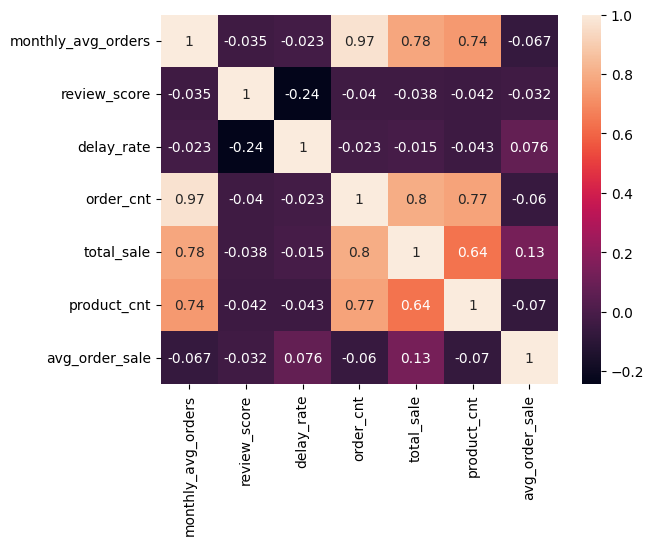

In [ ]:
sns.heatmap(train.corr(), annot=True) # order_cnt 주의

<Axes: >

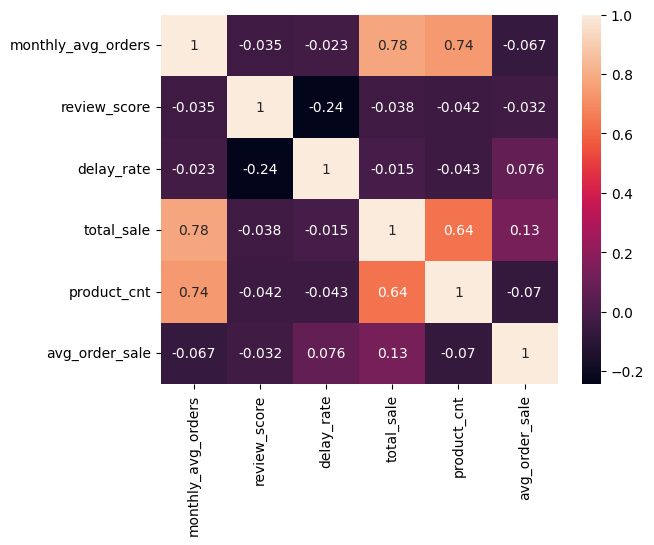

In [ ]:
train2 = train[['monthly_avg_orders', 'review_score', 'delay_rate', 'total_sale', 'product_cnt', 'avg_order_sale']]
sns.heatmap(train2.corr(), annot=True)

상관계수와 다중공선성 확인

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]
vif["features"] = X_temp.columns
vif = vif.sort_values("VIF Factor").reset_index(drop=True)
vif

,VIF Factor,features
0,1.181836,delay_rate
1,1.474352,avg_order_sale
2,2.024204,review_score
3,3.160238,product_cnt
4,3.474816,total_sale
5,20.146518,monthly_avg_orders
6,22.257513,order_cnt


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_temp2.values, i) for i in range(X_temp2.shape[1])]
vif["features"] = X_temp2.columns
vif = vif.sort_values("VIF Factor").reset_index(drop=True)
vif # 모든 regression에서 order_cnt 사용 금지

,VIF Factor,features
0,1.181551,delay_rate
1,1.468171,avg_order_sale
2,1.793485,review_score
3,2.912635,product_cnt
4,3.221762,total_sale
5,4.289483,monthly_avg_orders


일부 변수의 로그 변환(치우침이 심함): monthly_avg_orders, total_sale, product_cnt, avg_order_sale

In [ ]:
# monthly_avg_orders, total_sale, product_cnt, avg_order_sale 로그 변환
train['monthly_avg_orders_log'] = np.log1p(train['monthly_avg_orders'])
train['total_sale_log'] = np.log1p(train['total_sale'])
train['product_cnt_log'] = np.log1p(train['product_cnt'])
train['avg_order_sale_log'] = np.log1p(train['avg_order_sale'])
test['monthly_avg_orders_log'] = np.log1p(test['monthly_avg_orders'])
test['total_sale_log'] = np.log1p(test['total_sale'])
test['product_cnt_log'] = np.log1p(test['product_cnt'])
test['avg_order_sale_log'] = np.log1p(test['avg_order_sale'])

# 회귀: target - total_sale

RF 모델(best model)

xgboost, lightgbm 등도 사용해 보았으나 R2의 값이 0.00 이하 또는 음수가 나오는 경향이 있어 사용하지 못함.

X, y set 선정

In [ ]:
train['review_score_x_product_cnt'] = train['review_score'] * train['product_cnt']
test['review_score_x_product_cnt'] = test['review_score'] * test['product_cnt']

In [ ]:
# 1. 타겟을 무엇으로 잡는가? 수익률로? <- 수익률이라면 어떻게 계산해야 할지 전체수익/order_cnt <- monthly avg order? <-> monthly avg sale?
# 2. monthly avg order <-> order cnt 사실상 관계가 아주 있는 feature라서 넣으면 안 됨
# 3. target 후보: 'total_sale' & 'total_sale/np.sqrt(order_cnt)=avg_order_sale' & review_score

# rf모델로 확정 후 feature custom

features = ['review_score', 'delay_rate', 'product_cnt_log', 'review_score_x_product_cnt']  # 사용하고자 하는 feature명
target = 'total_sale' # 예측 대상 컬럼명
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 0.7, None]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)
print("Best Params:", grid_search_rf.best_params_)
print("Best score(Negative RMSE):", grid_search_rf.best_score_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
Best score(Negative RMSE): 0.386156570534722


In [ ]:
# 예측 및 평가
y_pred_rf = grid_search_rf.predict(X_test)
regression_metrics(y_test, y_pred_rf, n_features=X_test.shape[1])

{'MSE': 66290044.75815683,
 'MAE': 2718.4342059677356,
 'RMSE': np.float64(8141.869856375551),
 'R2': 0.39400814722755795,
 'Adjusted R2': 0.3925540575988299}

In [ ]:
y_pred_rf = grid_search_rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf)
regression_metrics(np.expm1(y_test), y_pred_rf, n_features=X_test.shape[1])

/tmp/ipython-input-2777981153.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


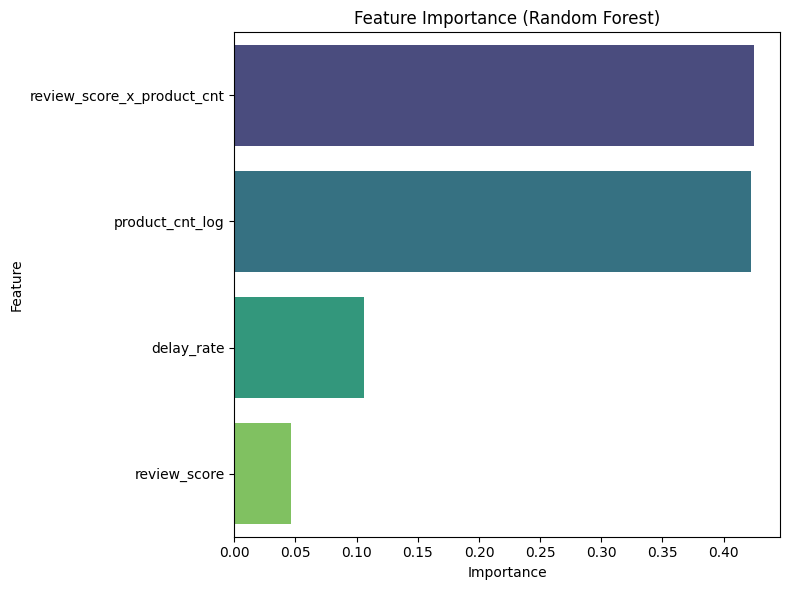

In [ ]:
# 모델과 feature 이름을 준비
model = grid_search_rf.best_estimator_
importances = model.feature_importances_
feature_names = X_train.columns  # X_train이 DataFrame이면 .columns 가능

# 데이터프레임으로 정리
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()


In [ ]:
best_rf_final = grid_search_rf.best_estimator_

In [ ]:
# import joblib

# # 저장
# joblib.dump(best_rf_final, '/content/drive/MyDrive/꾸러기_수비대/best_rf_model.pkl')

# # 불러오기
# loaded_rf = joblib.load('best_rf_model.pkl')
# y_pred_loaded = loaded_rf.predict(X_test)


['/content/drive/MyDrive/꾸러기_수비대/best_rf_model.pkl']